In [1]:
# =========================================
# NOTEBOOK IDENTITY CHECK
# =========================================

NOTEBOOK_VERSION = "BIRE V2.0 Upgrade Working"
PROJECT_STATUS = "Forked from frozen BIRE V1"
ACTIVE_BUILD = True

print("Notebook:", NOTEBOOK_VERSION)
print("Status:", PROJECT_STATUS)
print("Active build:", ACTIVE_BUILD)

Notebook: BIRE V2.0 Upgrade Working
Status: Forked from frozen BIRE V1
Active build: True


## BIRE V2.0 Upgrade Branch

This notebook is a forked working version of the frozen BIRE V1 pipeline.

V1 remains frozen.

V2 goals:
- Multi-horizon deterioration targets: 15, 30, and 60 minutes
- Temporal clinical intelligence
- Horizon-aware modeling
- Horizon-aware alerting
- GSS upgrade
- BMS integration

In [2]:
########################################################### FROZEN #########################################
# ============================================================
# GLOBAL SEED (FREEZE REPRODUCIBILITY)
# ============================================================

import numpy as np
import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

# 🧬 Project Sixth Sense — Bio-Intelligence Risk Engine (BIRE)
## Clinical Intelligence System

A time-series machine learning system for early detection of patient deterioration using physiological dynamics, not static thresholds.


*We Detect What Others Miss,*  
*What happens next… starts quietly.*


Author: Isaiah Washington
-Student (Applied Mathematics & Data Science)

## 1) Problem statement, setup and imports


Traditional patient monitoring systems rely on static thresholds and often react after deterioration has already begun. BIRE is designed to detect early physiological instability by modeling temporal dynamics such as trends, variability, and rate-of-change across vital signs.

In [3]:
!rm -rf /kaggle/working/ProjectSixthSenseV1
!git clone https://github.com/zaychili07/ProjectSixthSenseV1.git /kaggle/working/ProjectSixthSenseV1

Cloning into '/kaggle/working/ProjectSixthSenseV1'...
remote: Enumerating objects: 1456, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (236/236), done.
remote: Total 1456 (delta 178), reused 49 (delta 49), pack-reused 1169 (from 3)
Receiving objects: 100% (1456/1456), 8.75 MiB | 23.77 MiB/s, done.
Resolving deltas: 100% (810/810), done.


In [4]:

# GEMMA 4 RUNTIME
!pip uninstall -y transformers
!pip install -U git+https://github.com/huggingface/transformers.git
!pip install -U accelerate safetensors sentencepiece huggingface_hub

Found existing installation: transformers 5.8.0.dev0
Uninstalling transformers-5.8.0.dev0:
  Successfully uninstalled transformers-5.8.0.dev0
  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-hwyvryj3
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-hwyvryj3
  Resolved https://github.com/huggingface/transformers.git to commit eed95d8c445b8679ba342cffa947a3ed2b8d7fbc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.8.0.dev0-py3-none-any.whl size=11655128 sha256=4035beef6eea73d9341ad0ee3fc5665cdc38ed7534c95557067f334535db79e2
  Stored in directory: /tmp/pip-ephem-wheel-cache-7dynlhhx/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers


In [5]:
# ============================================================
# PATH SETUP — Run Before Project Imports
# ============================================================

import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path("/kaggle/working/ProjectSixthSenseV1")
SRC_PATH = PROJECT_ROOT / "src"

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project repo not found: {PROJECT_ROOT}\n"
        "Run the git clone cell first."
    )

if not SRC_PATH.exists():
    raise FileNotFoundError(f"Missing src folder: {SRC_PATH}")

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

importlib.invalidate_caches()

print("Python path configured")
print("SRC_PATH:", SRC_PATH)

Python path configured
SRC_PATH: /kaggle/working/ProjectSixthSenseV1/src


In [6]:
# ============================================================
# Imports — BIRE Rebuild
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

from bire.pipeline.main_pipeline import run_cycle1
from bire.pipeline.modeling_pipeline import run_xgb_modeling

from bire.data.labeling import add_event_and_target_labels

from bire.evaluation import analysis
from bire.evaluation import metrics
from bire.evaluation import plots

from bire.evaluation.demo_utils import (
    build_bire_output_from_patient,
    build_bire_dashboard_markdown,
    select_best_demo_patient,
)

pd.set_option("display.max_columns", 100)
pd.set_option("future.no_silent_downcasting", True)

print("Imports successful!")

Imports successful!


In [7]:
pd.set_option('future.no_silent_downcasting', True)

## BIRE Rebuild Pipeline

# Chapter 2: Data Initialization

This chapter ensures that the dataset is available, valid, and ready for the BIRE pipeline.

We perform:

- Dataset generation (if missing)
- Schema validation
- Timestamp integrity checks
- Basic dataset inspection

Goal: 

- Establish a clean, reliable data foundation before entering the modeling pipeline.


 Why this matters:

- all downstream components (features, models, alerts, GSS, BMS)
- depend on data correctness.

If data is wrong here -> everything downstream is unreliable.

In [8]:
# ============================================================
# CELL 1 — Project Configuration
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------
# Project paths
# ------------------------------
PROJECT_ROOT = Path("/kaggle/working/ProjectSixthSenseV1")

INPUT_PATH = Path("/kaggle/working/bire_synthetic_icu_grade.csv")

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------
# Core clinical timing assumptions
# ------------------------------
RESAMPLE_MINUTES = 5
LOOKAHEAD_MINUTES = 60
LOOKAHEAD_STEPS = LOOKAHEAD_MINUTES // RESAMPLE_MINUTES

# ------------------------------
# Current rebuild version
# ------------------------------
BIRE_VERSION = "v2_rebuild_cycle1"

print("Project configuration loaded")
print("Project root:", PROJECT_ROOT)
print("Input path:", INPUT_PATH)
print("Lookahead steps:", LOOKAHEAD_STEPS)
print("Output dir:", OUTPUT_DIR)

Project configuration loaded
Project root: /kaggle/working/ProjectSixthSenseV1
Input path: /kaggle/working/bire_synthetic_icu_grade.csv
Lookahead steps: 12
Output dir: /kaggle/working/ProjectSixthSenseV1/outputs


In [9]:

# Freezing to make upgrades in BIRE v2.0
# ============================================================
# CELL 1.5 — Generate Synthetic Dataset (if missing)
# ============================================================

from bire.data.synthetic_icu_generator import generate_synthetic_icu_data

# Only generate if file does not exist (prevents overwriting)
if not INPUT_PATH.exists():
    print("⚠️ Dataset not found. Generating synthetic ICU data...")

    synthetic_df = generate_synthetic_icu_data(
        n_patients = 500,   # you can scale this later
        random_state = 42
    )

    synthetic_df.to_csv(INPUT_PATH, index=False)

    print("✅Synthetic dataset created at:", INPUT_PATH)
else:
    print("Dataset already exists!  Skipping generation...")
 

Dataset already exists!  Skipping generation...


In [10]:
'''
# Frozen synthetic generation cell
# ============================================================
# LOAD FROZEN DATASET
# ============================================================

import pandas as pd
from pathlib import Path

FROZEN_DATA_PATH = Path("/kaggle/working/bire_v1_frozen_data.csv")

df = pd.read_csv(FROZEN_DATA_PATH)

print("Loaded frozen dataset:", df.shape)

'''

'\n# Frozen synthetic generation cell\n# ============================================================\n# LOAD FROZEN DATASET\n# ============================================================\n\nimport pandas as pd\nfrom pathlib import Path\n\nFROZEN_DATA_PATH = Path("/kaggle/working/bire_v1_frozen_data.csv")\n\ndf = pd.read_csv(FROZEN_DATA_PATH)\n\nprint("Loaded frozen dataset:", df.shape)\n\n'

In [11]:
# ============================================================
# CELL 2 — Dataset Check
# ============================================================

"""
Before running the BIRE pipeline, confirm that the input dataset exists
and inspect the raw structure.

This prevents confusing downstream errors caused by:
- missing files
- wrong file paths
- unexpected columns
- empty datasets
"""

# ------------------------------
# Confirm input file exists
# ------------------------------
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Input dataset not found: {INPUT_PATH}\n"
        "Run the synthetic data generation cell first."
    )

print("✅ Input dataset found:", INPUT_PATH)

# ------------------------------
# Load raw dataset
# ------------------------------
raw_df = pd.read_csv(INPUT_PATH)

print("Raw dataset shape:", raw_df.shape)
display(raw_df.head())

# ------------------------------
# Basic schema check
# ------------------------------
required_cols = [
    "patient_id",
    "timestamp",
    "heart_rate",
    "resp_rate",
    "spo2",
    "temperature",
    "sbp",
    "dbp",
]

missing_cols = [col for col in required_cols if col not in raw_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("✅ Required columns present")

# ------------------------------
# Timestamp check
# ------------------------------
raw_df["timestamp"] = pd.to_datetime(raw_df["timestamp"], errors="coerce")

bad_timestamps = raw_df["timestamp"].isna().sum()

print("Bad timestamps:", bad_timestamps)
print("Unique patients:", raw_df["patient_id"].nunique())
print("Time range:", raw_df["timestamp"].min(), "->", raw_df["timestamp"].max())

✅ Input dataset found: /kaggle/working/bire_synthetic_icu_grade.csv
Raw dataset shape: (99432, 15)


,patient_id,timestamp,care_mode,deterioration_mode,is_deteriorating,deterioration_start_step,event_anchor_step,heart_rate,resp_rate,spo2,temperature,sbp,dbp,event_now,target
0,P00001,2026-01-01 00:00:00,inpatient,cardiac_instability,0,169.0,211.0,91.878886,21.661709,94.120989,36.731088,125.217118,71.536651,0,0
1,P00001,2026-01-01 00:05:00,inpatient,cardiac_instability,0,169.0,211.0,90.625103,19.852733,94.705931,36.607079,122.979677,71.993516,0,0
2,P00001,2026-01-01 00:10:00,inpatient,cardiac_instability,0,169.0,211.0,93.055084,20.787861,93.765051,36.577564,125.672506,74.403362,0,0
3,P00001,2026-01-01 00:15:00,inpatient,cardiac_instability,0,169.0,211.0,90.992914,21.486056,95.615433,36.574822,122.022959,71.805544,0,0
4,P00001,2026-01-01 00:20:00,inpatient,cardiac_instability,0,169.0,211.0,91.665345,22.305462,93.991405,36.531095,121.009483,75.155658,0,0


✅ Required columns present
Bad timestamps: 0
Unique patients: 500
Time range: 2026-01-01 00:00:00 -> 2026-01-02 11:55:00


 # Chapter 3 — Cycle 1 Pipeline (Baseline)

This chapter runs the core BIRE data pipeline.

It performs:
- Data cleaning and validation
- Temporal alignment
- Feature engineering (Cycle 1 baseline)
- Forward-looking target construction (60-minute horizon)

Output:
- `cycle1_df` (single source of truth)

In [12]:
# ============================================================
# CHAPTER 3 — CELL 1: Run Cycle 1 Pipeline
# ============================================================

cycle1_df = run_cycle1(
    input_path=str(INPUT_PATH),
    output_path=str(OUTPUT_DIR / "cycle1_output.csv")
)

print("✅ Cycle 1 pipeline complete")
print("Shape:", cycle1_df.shape)

display(cycle1_df.head())

Loading data...
Cleaning data...
Aligning time series...
Imputing missing values...
Engineering features...


/kaggle/working/ProjectSixthSenseV1/src/bire/features/feature_engineering.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: add_temporal_features(x, signal_cols, window_size))


Generated 48 feature columns.
Saved processed feature dataset to /kaggle/working/ProjectSixthSenseV1/outputs/cycle1_output.csv
Cycle I complete ✅
✅ Cycle 1 pipeline complete
Shape: (99432, 50)


,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,heart_rate_delta,heart_rate_rolling_mean_6,heart_rate_rolling_std_6,heart_rate_rolling_min_6,heart_rate_rolling_max_6,resp_rate_lag1,resp_rate_lag2,resp_rate_delta,resp_rate_rolling_mean_6,resp_rate_rolling_std_6,resp_rate_rolling_min_6,resp_rate_rolling_max_6,spo2_lag1,spo2_lag2,spo2_delta,spo2_rolling_mean_6,spo2_rolling_std_6,spo2_rolling_min_6,spo2_rolling_max_6,temperature_lag1,temperature_lag2,temperature_delta,temperature_rolling_mean_6,temperature_rolling_std_6,temperature_rolling_min_6,temperature_rolling_max_6,sbp_lag1,sbp_lag2,sbp_delta,sbp_rolling_mean_6,sbp_rolling_std_6,sbp_rolling_min_6,sbp_rolling_max_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,dbp_rolling_max_6
0,P00001,2026-01-01 00:00:00,91.878886,21.661709,94.120989,36.731088,125.217118,71.536651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P00001,2026-01-01 00:05:00,90.625103,19.852733,94.705931,36.607079,122.979677,71.993516,91.878886,NaN,-1.253784,91.878886,NaN,91.878886,91.878886,21.661709,NaN,-1.808976,21.661709,NaN,21.661709,21.661709,94.120989,NaN,0.584942,94.120989,NaN,94.120989,94.120989,36.731088,NaN,-0.124009,36.731088,NaN,36.731088,36.731088,125.217118,NaN,-2.237441,125.217118,NaN,125.217118,125.217118,71.536651,NaN,0.456865,71.536651,NaN,71.536651,71.536651
2,P00001,2026-01-01 00:10:00,93.055084,20.787861,93.765051,36.577564,125.672506,74.403362,90.625103,91.878886,2.429981,91.251995,0.886559,90.625103,91.878886,19.852733,21.661709,0.935128,20.757221,1.279139,19.852733,21.661709,94.705931,94.120989,-0.940880,94.413460,0.413617,94.120989,94.705931,36.607079,36.731088,-0.029515,36.669084,0.087688,36.607079,36.731088,122.979677,125.217118,2.692829,124.098398,1.582110,122.979677,125.217118,71.993516,71.536651,2.409846,71.765084,0.323052,71.536651,71.993516
3,P00001,2026-01-01 00:15:00,90.992914,21.486056,95.615433,36.574822,122.022959,71.805544,93.055084,90.625103,-2.062170,91.853025,1.215197,90.625103,93.055084,20.787861,19.852733,0.698195,20.767435,0.904661,19.852733,21.661709,93.765051,94.705931,1.850382,94.197324,0.475062,93.765051,94.705931,36.577564,36.607079,-0.002742,36.638577,0.081465,36.577564,36.731088,125.672506,122.979677,-3.649547,124.623100,1.441345,122.979677,125.672506,74.403362,71.993516,-2.597818,72.644510,1.540244,71.536651,74.403362
4,P00001,2026-01-01 00:20:00,91.665345,22.305462,93.991405,36.531095,121.009483,75.155658,90.992914,93.055084,0.672431,91.637997,1.081396,90.625103,93.055084,21.486056,20.787861,0.819405,20.947090,0.821409,19.852733,21.661709,95.615433,93.765051,-1.624028,94.551851,0.808217,93.765051,95.615433,36.574822,36.577564,-0.043727,36.622638,0.073760,36.574822,36.731088,122.022959,125.672506,-1.013476,123.973065,1.753616,122.022959,125.672506,71.805544,74.403362,3.350114,72.434769,1.325720,71.536651,74.403362


## Sanity Check

In [13]:
# ============================================================
# CHAPTER 3 — CELL 2: Quick Sanity Check
# ============================================================

print("Columns:")
print(cycle1_df.columns.tolist())

print("\nNull values (top 10 columns):")
display(cycle1_df.isna().sum().sort_values(ascending=False).head(10))

Columns:
['patient_id', 'timestamp', 'heart_rate', 'resp_rate', 'spo2', 'temperature', 'sbp', 'dbp', 'heart_rate_lag1', 'heart_rate_lag2', 'heart_rate_delta', 'heart_rate_rolling_mean_6', 'heart_rate_rolling_std_6', 'heart_rate_rolling_min_6', 'heart_rate_rolling_max_6', 'resp_rate_lag1', 'resp_rate_lag2', 'resp_rate_delta', 'resp_rate_rolling_mean_6', 'resp_rate_rolling_std_6', 'resp_rate_rolling_min_6', 'resp_rate_rolling_max_6', 'spo2_lag1', 'spo2_lag2', 'spo2_delta', 'spo2_rolling_mean_6', 'spo2_rolling_std_6', 'spo2_rolling_min_6', 'spo2_rolling_max_6', 'temperature_lag1', 'temperature_lag2', 'temperature_delta', 'temperature_rolling_mean_6', 'temperature_rolling_std_6', 'temperature_rolling_min_6', 'temperature_rolling_max_6', 'sbp_lag1', 'sbp_lag2', 'sbp_delta', 'sbp_rolling_mean_6', 'sbp_rolling_std_6', 'sbp_rolling_min_6', 'sbp_rolling_max_6', 'dbp_lag1', 'dbp_lag2', 'dbp_delta', 'dbp_rolling_mean_6', 'dbp_rolling_std_6', 'dbp_rolling_min_6', 'dbp_rolling_max_6']

Null values 

heart_rate_rolling_std_6     1000
heart_rate_lag2              1000
resp_rate_lag2               1000
sbp_rolling_std_6            1000
dbp_rolling_std_6            1000
temperature_rolling_std_6    1000
spo2_rolling_std_6           1000
temperature_lag2             1000
spo2_lag2                    1000
dbp_lag2                     1000
dtype: int64

# Chapter 3.3 — Target Label Construction

We construct:

- `event_now` → current deterioration signal
- `target` → future deterioration (within 60 minutes)

This is separated from Cycle 1 to allow:
- flexible label upgrades
- multi-horizon targets (future)
- cleaner pipeline architecture

In [14]:
# ============================================================
# CHAPTER 3.3 — Add Event + Target Labels
# ============================================================

from bire.data.labeling import add_event_and_target_labels

cycle1_df = add_event_and_target_labels(
    cycle1_df,
    lookahead_steps=LOOKAHEAD_STEPS
)

print("✅ Labels added")

print("event_now exists:", "event_now" in cycle1_df.columns)
print("target exists:", "target" in cycle1_df.columns)

display(cycle1_df[["event_now", "target"]].head())

✅ Labels added
event_now exists: True
target exists: True


,event_now,target
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [15]:
########################################################### FROZEN #########################################
# ============================================================
# SAVE FROZEN DATASET (RUN ONCE)
# ============================================================

cycle1_df.to_csv("/kaggle/working/bire_v1_frozen_data.csv", index=False)

print("Frozen dataset saved ✅")

Frozen dataset saved ✅


#  Chapter 4 — Data Inspection & Validation

Before proceeding to modeling and system design, we validate the output of the Cycle 1 pipeline.

This chapter ensures that:

- Data is structurally correct
- Temporal ordering is valid
- Event and target signals behave as expected
- Patient-level patterns are realistic

---

Goal:

Establish confidence in the dataset before building predictive models and alert systems.

---

 Why this matters:

If data is incorrect or misaligned at this stage, all downstream components
(modeling, alerting, GSS, BMS) will produce unreliable results.

This is a **critical validation checkpoint**.

##  4.1 Dataset Overview

We inspect the basic structure of the dataset:

- Shape (rows × columns)
- Available features
- Sample records

---

 Goal:

Confirm that the Cycle 1 pipeline produced a usable dataset.

In [16]:
# ============================================================
# CHAPTER 4 — CELL 1: Dataset Overview
# ============================================================

print("Shape:", cycle1_df.shape)

print("\nColumns:")
print(cycle1_df.columns.tolist())

display(cycle1_df.head())

Shape: (99432, 52)

Columns:
['patient_id', 'timestamp', 'heart_rate', 'resp_rate', 'spo2', 'temperature', 'sbp', 'dbp', 'heart_rate_lag1', 'heart_rate_lag2', 'heart_rate_delta', 'heart_rate_rolling_mean_6', 'heart_rate_rolling_std_6', 'heart_rate_rolling_min_6', 'heart_rate_rolling_max_6', 'resp_rate_lag1', 'resp_rate_lag2', 'resp_rate_delta', 'resp_rate_rolling_mean_6', 'resp_rate_rolling_std_6', 'resp_rate_rolling_min_6', 'resp_rate_rolling_max_6', 'spo2_lag1', 'spo2_lag2', 'spo2_delta', 'spo2_rolling_mean_6', 'spo2_rolling_std_6', 'spo2_rolling_min_6', 'spo2_rolling_max_6', 'temperature_lag1', 'temperature_lag2', 'temperature_delta', 'temperature_rolling_mean_6', 'temperature_rolling_std_6', 'temperature_rolling_min_6', 'temperature_rolling_max_6', 'sbp_lag1', 'sbp_lag2', 'sbp_delta', 'sbp_rolling_mean_6', 'sbp_rolling_std_6', 'sbp_rolling_min_6', 'sbp_rolling_max_6', 'dbp_lag1', 'dbp_lag2', 'dbp_delta', 'dbp_rolling_mean_6', 'dbp_rolling_std_6', 'dbp_rolling_min_6', 'dbp_rolling_m

,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,heart_rate_delta,heart_rate_rolling_mean_6,heart_rate_rolling_std_6,heart_rate_rolling_min_6,heart_rate_rolling_max_6,resp_rate_lag1,resp_rate_lag2,resp_rate_delta,resp_rate_rolling_mean_6,resp_rate_rolling_std_6,resp_rate_rolling_min_6,resp_rate_rolling_max_6,spo2_lag1,spo2_lag2,spo2_delta,spo2_rolling_mean_6,spo2_rolling_std_6,spo2_rolling_min_6,spo2_rolling_max_6,temperature_lag1,temperature_lag2,temperature_delta,temperature_rolling_mean_6,temperature_rolling_std_6,temperature_rolling_min_6,temperature_rolling_max_6,sbp_lag1,sbp_lag2,sbp_delta,sbp_rolling_mean_6,sbp_rolling_std_6,sbp_rolling_min_6,sbp_rolling_max_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,dbp_rolling_max_6,event_now,target
0,P00001,2026-01-01 00:00:00,91.878886,21.661709,94.120989,36.731088,125.217118,71.536651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,P00001,2026-01-01 00:05:00,90.625103,19.852733,94.705931,36.607079,122.979677,71.993516,91.878886,NaN,-1.253784,91.878886,NaN,91.878886,91.878886,21.661709,NaN,-1.808976,21.661709,NaN,21.661709,21.661709,94.120989,NaN,0.584942,94.120989,NaN,94.120989,94.120989,36.731088,NaN,-0.124009,36.731088,NaN,36.731088,36.731088,125.217118,NaN,-2.237441,125.217118,NaN,125.217118,125.217118,71.536651,NaN,0.456865,71.536651,NaN,71.536651,71.536651,0,0
2,P00001,2026-01-01 00:10:00,93.055084,20.787861,93.765051,36.577564,125.672506,74.403362,90.625103,91.878886,2.429981,91.251995,0.886559,90.625103,91.878886,19.852733,21.661709,0.935128,20.757221,1.279139,19.852733,21.661709,94.705931,94.120989,-0.940880,94.413460,0.413617,94.120989,94.705931,36.607079,36.731088,-0.029515,36.669084,0.087688,36.607079,36.731088,122.979677,125.217118,2.692829,124.098398,1.582110,122.979677,125.217118,71.993516,71.536651,2.409846,71.765084,0.323052,71.536651,71.993516,0,0
3,P00001,2026-01-01 00:15:00,90.992914,21.486056,95.615433,36.574822,122.022959,71.805544,93.055084,90.625103,-2.062170,91.853025,1.215197,90.625103,93.055084,20.787861,19.852733,0.698195,20.767435,0.904661,19.852733,21.661709,93.765051,94.705931,1.850382,94.197324,0.475062,93.765051,94.705931,36.577564,36.607079,-0.002742,36.638577,0.081465,36.577564,36.731088,125.672506,122.979677,-3.649547,124.623100,1.441345,122.979677,125.672506,74.403362,71.993516,-2.597818,72.644510,1.540244,71.536651,74.403362,0,0
4,P00001,2026-01-01 00:20:00,91.665345,22.305462,93.991405,36.531095,121.009483,75.155658,90.992914,93.055084,0.672431,91.637997,1.081396,90.625103,93.055084,21.486056,20.787861,0.819405,20.947090,0.821409,19.852733,21.661709,95.615433,93.765051,-1.624028,94.551851,0.808217,93.765051,95.615433,36.574822,36.577564,-0.043727,36.622638,0.073760,36.574822,36.731088,122.022959,125.672506,-1.013476,123.973065,1.753616,122.022959,125.672506,71.805544,74.403362,3.350114,72.434769,1.325720,71.536651,74.403362,0,0


##  4.2 Required Columns Validation

We verify that all essential columns are present, including:

- Identifiers (`patient_id`, `timestamp`)
- Vital signs (heart_rate, resp_rate, spo2, temperature, sbp, dbp)
- Labels (`event_now`, `target`)

---

 Goal:

Ensure the dataset contains everything required for modeling and evaluation.

---

 Missing columns indicate pipeline issues and must be resolved before proceeding.

In [17]:
# ============================================================
# CHAPTER 4 — CELL 2: Required Columns Validation
# ============================================================

required_cols = [
    "patient_id",
    "timestamp",
    "heart_rate",
    "resp_rate",
    "spo2",
    "temperature",
    "sbp",
    "dbp",
    "event_now",
    "target",
]

missing_cols = [col for col in required_cols if col not in cycle1_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("✅ All required columns present")

✅ All required columns present


## 🔹 4.3 Timestamp & Data Integrity Check

We validate:

- Timestamp format and conversion
- Missing or invalid timestamps
- Duplicate patient-timestamp pairs
- Overall time range

---

 Goal:

Ensure the dataset is a valid time-series representation.

---

 Time inconsistencies can break temporal modeling and lead to incorrect predictions.

In [18]:
# ============================================================
# CHAPTER 4 — CELL 3: Timestamp & Integrity Check
# ============================================================

cycle1_df["timestamp"] = pd.to_datetime(cycle1_df["timestamp"], errors="coerce")

bad_ts = cycle1_df["timestamp"].isna().sum()
dupes = cycle1_df.duplicated(subset=["patient_id", "timestamp"]).sum()

print("Bad timestamps:", bad_ts)
print("Duplicate rows:", dupes)

print("Unique patients:", cycle1_df["patient_id"].nunique())
print("Time range:", cycle1_df["timestamp"].min(), "→", cycle1_df["timestamp"].max())

if bad_ts > 0:
    raise ValueError("Invalid timestamps detected")

if dupes > 0:
    raise ValueError("Duplicate patient/timestamp rows detected")

Bad timestamps: 0
Duplicate rows: 0
Unique patients: 500
Time range: 2026-01-01 00:00:00 → 2026-01-02 11:55:00


## 🔹 4.4 Event & Target Distribution

We analyze the distribution of:

- `event_now` (current deterioration events)
- `target` (future deterioration risk)

---

 Goal:

Understand class balance and confirm label construction behaves as expected.

---

Key insights:

- Class imbalance is expected in medical data
- Target should reflect future risk, not current events

In [19]:
# ============================================================
# CHAPTER 4 — CELL 4: Event & Target Distribution
# ============================================================

print("event_now distribution:")
display(cycle1_df["event_now"].value_counts().to_frame("count"))

print("\ntarget distribution:")
display(cycle1_df["target"].value_counts().to_frame("count"))

print("\nTotals:")
print("Current events:", int(cycle1_df["event_now"].sum()))
print("Future targets:", int(cycle1_df["target"].sum()))

event_now distribution:


,count
event_now,
0,87982
1,11450



target distribution:


,count
target,
0,84967
1,14465



Totals:
Current events: 11450
Future targets: 14465


## 🔹 4.5 Patient-Level Summary

We aggregate data at the patient level to examine:

- Number of observations per patient
- Number of events
- Number of future-risk targets

---

 Goal:

Understand how deterioration is distributed across patients.

---

This helps identify:

- High-risk patients
- Data imbalance across individuals

In [20]:
# ============================================================
# CHAPTER 4 — CELL 5: Patient-Level Summary
# ============================================================

patient_summary = (
    cycle1_df.groupby("patient_id")
    .agg(
        n_rows=("timestamp", "count"),
        n_events=("event_now", "sum"),
        n_targets=("target", "sum"),
    )
    .reset_index()
)

patient_summary["has_event"] = patient_summary["n_events"] > 0
patient_summary["has_target"] = patient_summary["n_targets"] > 0

print("Patients with events:", patient_summary["has_event"].sum())
print("Patients with targets:", patient_summary["has_target"].sum())

display(
    patient_summary
    .sort_values(["n_events", "n_targets"], ascending=False)
    .head(10)
)

Patients with events: 179
Patients with targets: 179


,patient_id,n_rows,n_events,n_targets,has_event,has_target
300,P00301,360,224,235,True,True
302,P00303,288,196,207,True,True
111,P00112,324,191,202,True,True
150,P00151,408,191,202,True,True
274,P00275,360,187,200,True,True
459,P00460,288,174,185,True,True
252,P00253,288,173,184,True,True
173,P00174,312,172,185,True,True
319,P00320,432,172,185,True,True
449,P00450,312,164,176,True,True


## 🔹 4.6 Demo Patient Selection

We select a representative patient for detailed inspection.

Selection criteria:

- High number of events
- High number of targets
- Sufficient time-series length

---

 Goal:

Choose a patient that clearly demonstrates system behavior.

In [21]:
# ============================================================
# CHAPTER 4 — CELL 6: Select Demo Patient
# ============================================================

demo_patient_id = (
    patient_summary
    .sort_values(["n_events", "n_targets"], ascending=False)
    .iloc[0]["patient_id"]
)

patient_view = (
    cycle1_df[cycle1_df["patient_id"] == demo_patient_id]
    .sort_values("timestamp")
    .copy()
)

print("Demo patient:", demo_patient_id)
print("Rows:", len(patient_view))

display(patient_view.head(20))

Demo patient: P00301
Rows: 360


,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,heart_rate_delta,heart_rate_rolling_mean_6,heart_rate_rolling_std_6,heart_rate_rolling_min_6,heart_rate_rolling_max_6,resp_rate_lag1,resp_rate_lag2,resp_rate_delta,resp_rate_rolling_mean_6,resp_rate_rolling_std_6,resp_rate_rolling_min_6,resp_rate_rolling_max_6,spo2_lag1,spo2_lag2,spo2_delta,spo2_rolling_mean_6,spo2_rolling_std_6,spo2_rolling_min_6,spo2_rolling_max_6,temperature_lag1,temperature_lag2,temperature_delta,temperature_rolling_mean_6,temperature_rolling_std_6,temperature_rolling_min_6,temperature_rolling_max_6,sbp_lag1,sbp_lag2,sbp_delta,sbp_rolling_mean_6,sbp_rolling_std_6,sbp_rolling_min_6,sbp_rolling_max_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,dbp_rolling_max_6,event_now,target
60288,P00301,2026-01-01 00:00:00,73.174445,18.440578,96.309346,36.725983,131.811962,78.616699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
60289,P00301,2026-01-01 00:05:00,79.249697,19.064992,96.929264,36.724586,124.467321,82.079891,73.174445,NaN,6.075252,73.174445,NaN,73.174445,73.174445,18.440578,NaN,0.624415,18.440578,NaN,18.440578,18.440578,96.309346,NaN,0.619918,96.309346,NaN,96.309346,96.309346,36.725983,NaN,-0.001397,36.725983,NaN,36.725983,36.725983,131.811962,NaN,-7.344640,131.811962,NaN,131.811962,131.811962,78.616699,NaN,3.463192,78.616699,NaN,78.616699,78.616699,0,0
60290,P00301,2026-01-01 00:10:00,78.943516,17.965964,96.620301,36.811403,126.571577,77.246785,79.249697,73.174445,-0.306181,76.212071,4.295852,73.174445,79.249697,19.064992,18.440578,-1.099028,18.752785,0.441528,18.440578,19.064992,96.929264,96.309346,-0.308963,96.619305,0.438348,96.309346,96.929264,36.724586,36.725983,0.086817,36.725285,0.000988,36.724586,36.725983,124.467321,131.811962,2.104256,128.139641,5.193445,124.467321,131.811962,82.079891,78.616699,-4.833106,80.348295,2.448847,78.616699,82.079891,0,0
60291,P00301,2026-01-01 00:15:00,74.554574,20.290190,96.847874,36.653653,125.827666,76.885878,78.943516,79.249697,-4.388942,77.122553,3.422587,73.174445,79.249697,17.965964,19.064992,2.324226,18.490511,0.551213,17.965964,19.064992,96.620301,96.929264,0.227573,96.619637,0.309959,96.309346,96.929264,36.811403,36.724586,-0.157750,36.753991,0.049726,36.724586,36.811403,126.571577,124.467321,-0.743911,127.616953,3.782267,124.467321,131.811962,77.246785,82.079891,-0.360907,79.314458,2.490960,77.246785,82.079891,0,0
60292,P00301,2026-01-01 00:20:00,81.770245,17.906773,96.106900,36.682851,123.942269,77.186595,74.554574,78.943516,7.215671,76.480558,3.075391,73.174445,79.249697,20.290190,17.965964,-2.383417,18.940431,1.006115,17.965964,20.290190,96.847874,96.620301,-0.740974,96.676696,0.277620,96.309346,96.929264,36.653653,36.811403,0.029197,36.728907,0.064539,36.653653,36.811403,125.827666,126.571577,-1.885397,127.169632,3.215185,124.467321,131.811962,76.885878,77.246785,0.300717,78.707313,2.368773,76.885878,82.079891,0,0
60293,P00301,2026-01-01 00:25:00,75.131886,18.222399,96.012870,36.589547,127.726895,79.555322,81.770245,74.554574,-6.638358,77.538495,3.562258,73.174445,81.770245,17.906773,20.290190,0.315627,18.733699,0.986352,17.906773,20.290190,96.106900,96.847874,-0.094030,96.562737,0.350340,96.106900,96.929264,36.682851,36.653653,-0.093304,36.719695,0.059567,36.653653,36.811403,123.942269,125.827666,3.784626,126.524159,3.136277,123.942269,131.811962,77.186595,76.885878,2.368727,78.403170,2.161211,76.885878,82.079891,0,0
60294,P00301,2026-01-01 00:30:00,78.387993,18.700325,95.307219,36.662479,125.720594,79.445467,75.131886,81.770245,3.256106,77.137394,3.334222,73.174445,81.770245,18.222399,17.906773,0.477925,18.648483,0.906578,17.906773,20.290190,96.012870,96.106900,-0.705650,96.471093,0.385465,96.012870,96.929264,36.589547,36.682851,0.072932,36.698004,0.075244,36.589547,36.811403,127.726895,123.942

## 🔹 4.7 Event Window Inspection

We zoom into a time window around a deterioration event.

We examine:

- Vital signs leading up to the event
- Target signals before the event occurs
- Temporal alignment between signals and labels

---

 Goal:

Validate that:

- Targets correctly anticipate future events
- Feature signals reflect meaningful physiological changes

In [22]:
# ============================================================
# CHAPTER 4 — CELL 7: Event Window Inspection
# ============================================================

event_rows = patient_view[patient_view["event_now"] == 1]

if len(event_rows) > 0:
    first_event_time = event_rows["timestamp"].min()

    window = patient_view[
        (patient_view["timestamp"] >= first_event_time - pd.Timedelta(minutes=90)) &
        (patient_view["timestamp"] <= first_event_time + pd.Timedelta(minutes=30))
    ]

    print("First event:", first_event_time)
    display(window)
else:
    print("No events found for this patient")

First event: 2026-01-01 11:20:00


,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,heart_rate_delta,heart_rate_rolling_mean_6,heart_rate_rolling_std_6,heart_rate_rolling_min_6,heart_rate_rolling_max_6,resp_rate_lag1,resp_rate_lag2,resp_rate_delta,resp_rate_rolling_mean_6,resp_rate_rolling_std_6,resp_rate_rolling_min_6,resp_rate_rolling_max_6,spo2_lag1,spo2_lag2,spo2_delta,spo2_rolling_mean_6,spo2_rolling_std_6,spo2_rolling_min_6,spo2_rolling_max_6,temperature_lag1,temperature_lag2,temperature_delta,temperature_rolling_mean_6,temperature_rolling_std_6,temperature_rolling_min_6,temperature_rolling_max_6,sbp_lag1,sbp_lag2,sbp_delta,sbp_rolling_mean_6,sbp_rolling_std_6,sbp_rolling_min_6,sbp_rolling_max_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,dbp_rolling_max_6,event_now,target
60406,P00301,2026-01-01 09:50:00,78.678040,20.681063,94.933544,37.510343,128.175909,79.083446,74.018041,80.023167,4.659999,75.933047,2.769122,73.335668,80.023167,20.119252,19.407595,0.561811,20.002851,0.636029,19.407595,20.922765,96.517953,96.680342,-1.584410,96.706104,0.547482,95.976307,97.652165,37.192064,37.204744,0.318278,37.156363,0.115629,37.010146,37.333597,131.031748,125.274035,-2.855839,127.569040,2.371332,125.274035,131.031748,80.977486,75.617690,-1.894040,78.842443,3.176147,75.368057,83.019571,0,0
60407,P00301,2026-01-01 09:55:00,77.027851,22.084713,97.383157,37.294051,126.307142,76.824029,78.678040,74.018041,-1.650189,76.823442,2.621906,74.018041,80.023167,20.681063,20.119252,1.403650,20.203640,0.626661,19.407595,20.922765,94.933544,96.517953,2.449614,96.253001,0.709056,94.933544,96.837178,37.510343,37.192064,-0.216292,37.239730,0.160669,37.055113,37.510343,128.175909,131.031748,-1.868767,127.864229,2.306774,125.274035,131.031748,79.083446,80.977486,-2.259417,78.564407,3.045938,75.368057,83.019571,0,0
60408,P00301,2026-01-01 10:00:00,79.563574,19.569291,96.683901,37.550050,123.891955,79.836272,77.027851,78.678040,2.535723,77.162992,2.464244,74.018041,80.023167,22.084713,20.681063,-2.515422,20.457887,0.998765,19.407595,22.084713,97.383157,94.933544,-0.699256,96.487476,0.822755,94.933544,97.383157,37.294051,37.510343,0.255999,37.279553,0.132985,37.142516,37.510343,126.307142,128.175909,-2.415187,127.285020,2.160476,125.274035,131.031748,76.824029,79.083446,3.012243,78.807069,2.787388,75.617690,83.019571,0,0
60409,P00301,2026-01-01 10:05:00,80.606875,20.284231,96.924928,37.551568,127.370773,78.415638,79.563574,77.027851,1.043301,78.015249,2.209392,74.018041,80.023167,19.569291,22.084713,0.714940,20.464113,0.991931,19.407595,22.084713,96.683901,97.383157,0.241027,96.461929,0.812035,94.933544,97.383157,37.550050,37.294051,0.001518,37.347475,0.151746,37.192064,37.550050,123.891955,126.307142,3.478818,127.029594,2.489909,123.891955,131.031748,79.836272,76.824029,-1.420634,79.226416,2.707065,75.617690,83.019571,0,0
60410,P00301,2026-01-01 10:10:00,83.433173,22.000877,96.971536,37.818504,123.552509,79.167134,80.606875,79.563574,2.826298,78.319591,2.448744,74.018041,80.606875,20.284231,19.569291,1.716646,20.357691,0.966818,19.407595,22.084713,96.924928,96.683901,0.046608,96.520638,0.834077,94.933544,97.383157,37.551568,37.550050,0.266936,37.383804,0.172439,37.192064,37.551568,127.370773,123.891955,-3.818263,127.008593,2.485708,123.891955,131.031748,78.415638,79.836272,0.751496,78.459093,1.968636,75.617690,80.977486,0,0
60411,P00301,2026-01-01 10:15:00,82.446380,21.647359,96.386757,37.777138,126.457796,77.348582,83.433173,80.606875,-0.986793,78.887926,3.202820,74.018041,83.433173,22.000877,20.284231,-0.353518,20.789905,1.034428,19.569291,22.084713,96.971536,96.924928,-0.584779,96.569170,0.853475,94.933544,97.383157,37.818504,37.551568,-0.041366,37.486097,0.220361,37.192064,37.818504,123.552509,127.370773,2.905287,126.721673,2.804839,123.552509,131.031748,79.167134,78.415638,-1.818551,79.050667,1.393243,76.824029,80.977486,0,0
60412,P00301,2026-01-01 10:20:00,86.074425,23.970965,96.766874,37.672631

## 🔹 4.8 Patient Timeline Visualization

We visualize the patient’s time-series data, including:

- Vital sign trajectories
- Event occurrences
- Target signals

---

 Goal:

Provide an intuitive, visual understanding of how deterioration develops over time.

---

This helps confirm:

- Temporal consistency
- Realistic signal behavior
- Alignment between risk and events

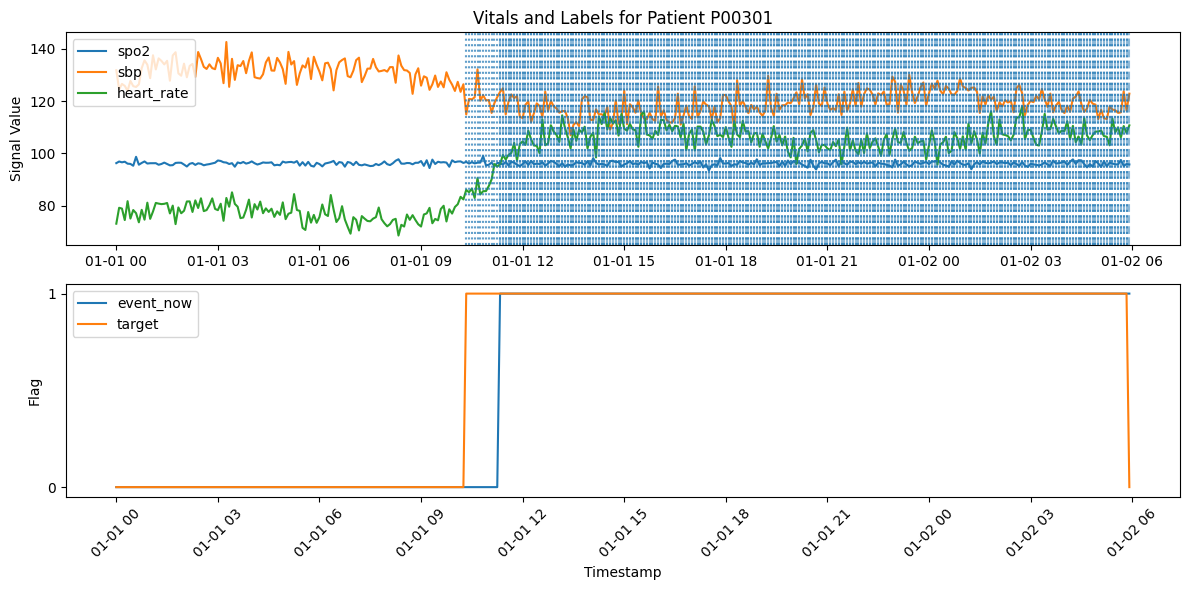

In [23]:
# ============================================================
# CHAPTER 4 — CELL 8: Timeline Visualization
# ============================================================

from bire.evaluation.plots import plot_patient_event_timeline

plot_patient_event_timeline(
    patient_view,
    patient_id=demo_patient_id
)

## 🔹 Chapter 4 Summary

We validated the integrity and behavior of the Cycle 1 dataset.

We confirmed:

- Structural correctness of the dataset
- Proper temporal ordering
- Valid event and target signals
- Realistic patient-level behavior

---

Outcome:

The dataset is now trusted and ready for:

- Feature upgrades
- Modeling
- Alert system design

---

Next: Chapter 5 — Cycle 1 Upgrade (Temporal Intelligence)

# 🔹 Chapter 5 — Cycle 1 Upgrade (Temporal Intelligence)

In this chapter, we enhance BIRE’s feature engineering to capture deeper physiological behavior.

We move beyond:
- simple lag features
- basic rolling statistics

Into:

### 🔹 Temporal Dynamics
- Acceleration (second-order change)
- Directional movement

### 🔹 Instability
- Volatility relative to baseline
- Signal variability

### 🔹 Physiological Stress
- Cross-signal interactions
- Early deterioration patterns

---

Goal:

Transform BIRE from:

-> “pattern detection”

into:

-> “physiological understanding”

In [24]:
# ============================================================
# CHAPTER 5.1 Setup
# ============================================================

upgrade_df = cycle1_df.copy()

print("Starting shape:", upgrade_df.shape)

Starting shape: (99432, 52)


## 🔹 5.2 Acceleration Features (Second-Order Change)

We introduce acceleration features to capture how quickly vital signs are changing over time.

While first-order changes (deltas) measure *direction* and *magnitude* of change, acceleration measures:

→ how fast that change itself is increasing or decreasing

---

### Concept

Acceleration is the **second derivative** of a signal:

    acceleration = Δ(current change)

This allows the model to detect:

- Rapid deterioration (e.g., heart rate rising faster over time)
- Sudden instability
- Escalating physiological trends

---

### Why this matters

In clinical settings:

- A gradual increase may be normal
- A rapidly accelerating increase can indicate deterioration

Example:

- HR: 80 → 85 → 90 → 100  
  → acceleration is increasing → potential risk

---

### Implementation

For each vital signal:

1. Compute first-order change (delta)
2. Compute second-order change (acceleration)

All calculations are performed per patient to preserve temporal structure.

---

 Goal:

Capture early signs of **worsening trends**, not just abnormal values.


In [25]:
# ============================================================
# CHAPTER 5.2 - Acceleration Features
# ============================================================

signals = ["heart_rate", "resp_rate", "spo2", "temperature", "sbp", "dbp"]

for col in signals:
    # First derivative (delta already exists or we recompute safely)
    delta = upgrade_df.groupby("patient_id")[col].diff()

    # Second derivative (acceleration)
    accel = delta.groupby(upgrade_df["patient_id"]).diff()

    upgrade_df[f"{col}_acceleration"] = accel

print("✅ Acceleration features added")

✅ Acceleration features added


### 🔹 Volatility & Instability Features

In clinical settings, deterioration is often not just about absolute values, but about **how unstable a signal becomes over time**.

We compute:

- Rolling mean (baseline behavior)
- Rolling standard deviation (variability)

Then define:

**Volatility = standard deviation / mean**

This captures:

- High variability relative to normal → instability
- Early warning signs before threshold-based events

Example:
- Stable patient → low volatility
- Deteriorating patient → increasing volatility

 Important:
We use `shift(1)` before rolling to prevent **data leakage** (future values influencing past features).

In [26]:
# ============================================================
# CHAPTER 5.3 - Volatility Features
# ============================================================

window = 6  # 30 minutes

for col in signals:
    rolling_mean = (
        upgrade_df.groupby("patient_id")[col]
        .shift(1)
        .rolling(window)
        .mean()
    )

    rolling_std = (
        upgrade_df.groupby("patient_id")[col]
        .shift(1)
        .rolling(window)
        .std()
    )

    # Volatility ratio
    upgrade_df[f"{col}_volatility"] = rolling_std / (rolling_mean + 1e-6)

print("✅ Volatility features added")

✅ Volatility features added


### 🔹 Physiological Stress Indices

Single vital signs often do not fully capture patient condition.

Instead, we create **cross-signal interactions** that reflect how different systems interact.

Examples:

- **Shock Index** = heart_rate / systolic blood pressure  
  → High values may indicate circulatory compromise

- **Respiratory-Oxygen Stress** = resp_rate / SpO₂  
  → High breathing effort with low oxygen suggests distress

- **Cardiorespiratory Stress** = heart_rate × resp_rate / SpO₂  
  → Combined cardiovascular + respiratory strain

- **Perfusion Stress** = SpO₂ / systolic blood pressure  
  → Indicates oxygen delivery relative to pressure

These features help the model learn:

→ “This combination of signals is dangerous”

instead of:

→ “This single value crossed a threshold”

In [27]:
# ============================================================
# CHAPTER 5.4 - Physiological Stress Features
# ============================================================

# Shock Index (classic clinical signal)
upgrade_df["shock_index"] = upgrade_df["heart_rate"] / (upgrade_df["sbp"] + 1e-6)

# Oxygen stress (respiratory load vs oxygen)
upgrade_df["resp_oxygen_stress"] = upgrade_df["resp_rate"] / (upgrade_df["spo2"] + 1e-6)

# Cardiorespiratory stress
upgrade_df["cardio_respiratory_stress"] = (
    upgrade_df["heart_rate"] * upgrade_df["resp_rate"]
) / (upgrade_df["spo2"] + 1e-6)

# Perfusion stress (pressure + oxygen)
upgrade_df["perfusion_stress"] = upgrade_df["spo2"] / (upgrade_df["sbp"] + 1e-6)

print("✅ Stress features added")

✅ Stress features added


### 🔹 Directional Persistence (Trend Consistency)

We track whether a signal is **consistently moving in one direction** over time.

Steps:
- Compute change (delta)
- Convert to direction (increase vs decrease)
- Count how many consecutive increases occur

This captures:

- Sustained worsening trends
- Not just noise or one-time spikes

Example:
- Heart rate rising for 3 consecutive steps → potential escalation
- Random up/down → likely noise

This helps the model distinguish:

→ meaningful deterioration trends  
vs  
→ random fluctuations

In [28]:
# ============================================================
# CHAPTER 5.5 - Directional Persistence
# ============================================================

for col in signals:
    delta = upgrade_df.groupby("patient_id")[col].diff()

    direction = (delta > 0).astype(int)

    persistence = (
        direction.groupby(upgrade_df["patient_id"])
        .rolling(3)
        .sum()
        .reset_index(level=0, drop=True)
    )

    upgrade_df[f"{col}_upward_persistence"] = persistence

print("✅ Directional persistence features added")

✅ Directional persistence features added


### 🔹 Baseline Deviation (Personalized Risk)

Instead of using absolute thresholds, we measure:

→ how far a signal deviates from the patient’s recent baseline

Steps:
- Compute rolling baseline (mean over past window)
- Compare current value to that baseline
- Normalize difference

Formula:

(current value − baseline) / baseline

Why this matters:

- Patients have different “normal” ranges
- A value may be normal globally but abnormal for a specific patient

Example:
- HR = 100 may be fine for one patient
- But abnormal if baseline was 70

This introduces **patient-specific context** into the model.

In [29]:
# ============================================================
# CHAPTER 5.6 - Baseline Deviation
# ============================================================

baseline_window = 12  # 1 hour

for col in signals:
    baseline = (
        upgrade_df.groupby("patient_id")[col]
        .shift(1)
        .rolling(baseline_window)
        .mean()
    )

    upgrade_df[f"{col}_baseline_dev"] = (
        upgrade_df[col] - baseline
    ) / (baseline + 1e-6)

print("✅ Baseline deviation features added")

✅ Baseline deviation features added


### 🔹 Cleanup & Validation

Feature engineering can introduce:

- Infinite values (division by zero)
- Missing values (rolling windows, shifts)

We:

- Replace infinite values with NaN
- Inspect columns with the most missing values

We do NOT aggressively drop rows here because:

→ Missing values will be handled later during modeling (imputation)

Goal:
Ensure the dataset is stable and ready for modeling without silent errors.

In [30]:
# ============================================================
# CHAPTER 5.7 - Cleanup & Validation
# ============================================================

# Replace infs from division
upgrade_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Optional: drop extreme NaNs if needed later (we usually impute in modeling)
nan_summary = upgrade_df.isna().sum().sort_values(ascending=False).head(10)

print("Top NaN columns:")
display(nan_summary)

print("Final shape:", upgrade_df.shape)

Top NaN columns:


temperature_baseline_dev    6000
spo2_baseline_dev           6000
sbp_baseline_dev            6000
dbp_baseline_dev            6000
resp_rate_baseline_dev      6000
heart_rate_baseline_dev     6000
spo2_volatility             3000
temperature_volatility      3000
heart_rate_volatility       3000
resp_rate_volatility        3000
dtype: int64

Final shape: (99432, 80)


In [31]:
########################################################### FROZEN #########################################
# Replace cycle1_df

cycle1_df = upgrade_df.copy()

print("✅ Cycle 1 upgraded dataset ready")

✅ Cycle 1 upgraded dataset ready


##  🔹Summary — What Changed in Cycle 1 Upgrade

We enhanced the feature space from:

- Simple temporal statistics

To:

- Temporal dynamics (acceleration)
- Instability (volatility)
- Cross-system stress (interaction features)
- Personalized deviation (baseline-aware features)

This transforms BIRE from:

→ “detecting patterns”

into:

→ “understanding physiological behavior”

These features provide the foundation for more accurate prediction,
better alerting, and more meaningful clinical interpretation.

# 🔹 Chapter 6 — Modeling (XGBoost Baseline)

In this chapter, we train a predictive model to estimate the probability
of patient deterioration within a 60-minute horizon.

Key design principles:

- Patient-level split (no leakage)
- Class imbalance handling
- Clean feature pipeline (post-upgrade features)
- Deterministic outputs (no mismatch risk)

---

 Goal:

Learn a function:

    f(features_t) → P(deterioration within 60 minutes)

This probability becomes the foundation for:

- Alert generation
- GSS (suppression system)
- BMS (mode-based behavior)

## 🔹 6.1 Feature Selection

We define the set of input features used by the model.

We explicitly remove:

- `patient_id` → identifier (not predictive)
- `timestamp` → ordering information
- `event_now` → current event signal
- `target` → label (what we are predicting)

Everything else represents engineered physiological signals and becomes model input.

---

 Goal:

Ensure the model only learns from valid, leakage-free features.

In [32]:
# ============================================================
# CHAPTER 6.1 - Define Feature Columns
# ============================================================

"""
We exclude identifiers and labels.
Everything else becomes model input.
"""

exclude_cols = ["patient_id", "timestamp", "event_now", "target"]

feature_cols = [
    col for col in cycle1_df.columns
    if col not in exclude_cols
]

print("Number of features:", len(feature_cols))

Number of features: 76


In [33]:
######################################### FREEZE ############################################
# ============================================================
# SAVE FEATURE COLUMNS
# ============================================================

with open("/kaggle/working/bire_v1_features.txt", "w") as f:
    for col in feature_cols:
        f.write(col + "\n")

print("Feature list saved ✅")

Feature list saved ✅


## 🔹 6.2 Patient-Level Train/Validation/Test Split

We split the dataset at the **patient level**, not the row level.

Why this matters:

- Prevents data leakage across time
- Simulates real-world deployment (new unseen patients)
- Ensures model generalization

---

Split strategy:

- 60% Train
- 20% Validation
- 20% Test

Stratification is applied to maintain class balance across splits.

---

 Critical:

No patient appears in more than one split.

In [34]:
# ============================================================
# CHAPTER 6.2 - Patient-Level Split
# ============================================================

from sklearn.model_selection import train_test_split

data = cycle1_df.dropna(subset=["target"]).copy()

# Build patient-level labels
patient_summary = (
    data.groupby("patient_id")["target"]
    .max()
    .reset_index()
    .rename(columns={"target": "any_target"})
)

patients = patient_summary["patient_id"]
labels = patient_summary["any_target"]

# Train / temp split
train_p, temp_p, y_train_p, y_temp_p = train_test_split(
    patients,
    labels,
    test_size=0.4,
    random_state=42,
    stratify=labels
)

# Validation / test split
val_p, test_p, y_val_p, y_test_p = train_test_split(
    temp_p,
    y_temp_p,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_p
)

# Build datasets
train_df = data[data["patient_id"].isin(train_p)].copy()
val_df   = data[data["patient_id"].isin(val_p)].copy()
test_df  = data[data["patient_id"].isin(test_p)].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (58740, 80)
Val: (20688, 80)
Test: (20004, 80)


## 🔹 6.3 Build Model Matrices

We convert the dataset into model-ready inputs:

- `X` → feature matrix
- `y` → target vector

Datasets:

- Training set → used to fit the model
- Validation set → used for tuning and monitoring
- Test set → used for final evaluation

---

 Goal:

Prepare clean numerical inputs for modeling.

In [35]:
# ============================================================
# CHAPTER 6.3 - Build Model Matrices
# ============================================================

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_val = val_df[feature_cols]
y_val = val_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

print("Matrices ready")

Matrices ready


## 🔹 6.4 Model Training (XGBoost)

We train an XGBoost classifier to predict deterioration risk.

### Class Imbalance Handling

Medical datasets are typically imbalanced:
- Few deterioration events
- Many normal observations

We address this using:

    scale_pos_weight = (# negative) / (# positive)

This forces the model to pay more attention to rare events.

---

 Outcome:

The model learns patterns associated with early deterioration.

---

 Note:

We keep XGBoost as the baseline before moving to sequence models (LSTM, Transformer).

In [36]:
# ============================================================
# CHAPTER 6.4 - Train XGBoost
# ============================================================

"""
Handle class imbalance using scale_pos_weight.
"""

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()

scale_pos_weight = neg / pos if pos > 0 else 1.0

print("scale_pos_weight:", scale_pos_weight)

xgb_model, xgb_imputer, xgb_results_df, xgb_probas, xgb_artifacts = run_xgb_modeling(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    scale_pos_weight=scale_pos_weight,
)

display(xgb_results_df)

import joblib

joblib.dump(xgb_model, "/kaggle/working/bire_v1_model.pkl")

print("Model saved ✅")

scale_pos_weight: 5.7154452955298956


,split,n_rows,positive_rate,roc_auc,pr_auc
0,val,20688,0.155259,0.993916,0.974417
1,test,20004,0.125275,0.991991,0.958791


Model saved ✅


## 🔹 6.5 Build Scored Dataset (Single Source of Truth)

We construct a unified dataset containing:

- Original test data
- Predicted probabilities (`pred_proba`)

---

Why this step is critical:

- Prevents prediction/data mismatches
- Ensures alignment between rows and probabilities
- Eliminates a major class of bugs

---

 Rule:

From this point forward:

    DO NOT use `test_df` directly

Instead:

    Use `xgb_scored_df` for all downstream steps

---

 This dataset becomes the foundation for:

- Alert generation
- GSS (suppression logic)
- BMS (mode adaptation)

In [37]:
# ============================================================
# CHAPTER 6.5 - Build Scored Dataset
# ============================================================

"""
This is the SINGLE SOURCE OF TRUTH going forward.
"""

xgb_test_proba = xgb_probas["test"]

# Align indices (prevents mismatch bugs)
test_df = test_df.reset_index(drop=True)
xgb_test_proba = pd.Series(xgb_test_proba).reset_index(drop=True)

assert len(test_df) == len(xgb_test_proba)

# Build scored dataset
xgb_scored_df = test_df.copy()
xgb_scored_df["pred_proba"] = xgb_test_proba

print("✅ Scored dataset ready:", xgb_scored_df.shape)
xgb_scored_df.head()

✅ Scored dataset ready: (20004, 81)


,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,heart_rate_delta,heart_rate_rolling_mean_6,heart_rate_rolling_std_6,heart_rate_rolling_min_6,heart_rate_rolling_max_6,resp_rate_lag1,resp_rate_lag2,resp_rate_delta,resp_rate_rolling_mean_6,resp_rate_rolling_std_6,resp_rate_rolling_min_6,resp_rate_rolling_max_6,spo2_lag1,spo2_lag2,spo2_delta,spo2_rolling_mean_6,spo2_rolling_std_6,spo2_rolling_min_6,spo2_rolling_max_6,temperature_lag1,temperature_lag2,temperature_delta,temperature_rolling_mean_6,temperature_rolling_std_6,temperature_rolling_min_6,temperature_rolling_max_6,sbp_lag1,sbp_lag2,sbp_delta,sbp_rolling_mean_6,sbp_rolling_std_6,sbp_rolling_min_6,sbp_rolling_max_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,dbp_rolling_max_6,event_now,target,heart_rate_acceleration,resp_rate_acceleration,spo2_acceleration,temperature_acceleration,sbp_acceleration,dbp_acceleration,heart_rate_volatility,resp_rate_volatility,spo2_volatility,temperature_volatility,sbp_volatility,dbp_volatility,shock_index,resp_oxygen_stress,cardio_respiratory_stress,perfusion_stress,heart_rate_upward_persistence,resp_rate_upward_persistence,spo2_upward_persistence,temperature_upward_persistence,sbp_upward_persistence,dbp_upward_persistence,heart_rate_baseline_dev,resp_rate_baseline_dev,spo2_baseline_dev,temperature_baseline_dev,sbp_baseline_dev,dbp_baseline_dev,pred_proba
0,P00003,2026-01-01 00:00:00,59.300402,17.453734,99.069060,37.312614,113.265929,78.378084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.523550,0.176177,10.447393,0.874659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011008
1,P00003,2026-01-01 00:05:00,56.868462,16.754433,97.283378,37.104636,113.842875,84.786999,59.300402,NaN,-2.431940,59.300402,NaN,59.300402,59.300402,17.453734,NaN,-0.699301,17.453734,NaN,17.453734,17.453734,99.069060,NaN,-1.785682,99.069060,NaN,99.069060,99.06906,37.312614,NaN,-0.207978,37.312614,NaN,37.312614,37.312614,113.265929,NaN,0.576947,113.265929,NaN,113.265929,113.265929,78.378084,NaN,6.408915,78.378084,NaN,78.378084,78.378084,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.499535,0.172223,9.794056,0.854541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006172
2,P00003,2026-01-01 00:10:00,66.783856,16.830354,98.679460,37.254785,113.158069,87.452751,56.868462,59.300402,9.915395,58.084432,1.719641,56.868462,59.300402,16.754433,17.453734,0.075921,17.104083,0.494480,16.754433,17.453734,97.283378,99.069060,1.396082,98.176219,1.262668,97.283378,99.06906,37.104636,37.312614,0.150149,37.208625,0.147063,37.104636,37.312614,113.842875,113.265929,-0.684806,113.554402,0.407963,113.265929,113.842875,84.786999,78.378084,2.665753,81.582541,4.531787,78.378084,84.786999,0,0,12.347334,0.775222,3.181764,0.358127,-1.261753,-3.743162,NaN,NaN,NaN,NaN,NaN,NaN,0.590182,0.170556,11.390374,0.872050,1.0,1.0,1.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.010867
3,P00003,2026-01-01 00:15:00,60.562743,20.431126,97.928699,37.307120,116.086805,89.743438,66.783856,56.868462,-6.221114,60.984240,5.167712,56.868462,66.783856,16.830354,16.754433,3.600772,17.012840,0.383707,16.754433,17.453734,98.679460,97.283378,-0.750760,98.343966,0.938926,97.283378,99.06906,37.254785,37.104636,0.052335,37.224012,0.107350,37.104636,37.312614,113.158069,113.842875,2.928736,113.422291,0.368208,113.158069,113.842875,87.452751,84.786999,2.290687,83.539278,4.664226,78.378084,87.452751,0,0,-16.136508,3.524851,-2.146843,-0.097814,3.613542,-0.375066,NaN,NaN,NaN,NaN,NaN,NaN,0.521702,0.208633,12.635367,0.843582,1.0,2.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,0.012552
4,P00003,2026-01-01 00:20:00,66.530536,14.662784,98.833527,37.214969,114.358448,81.118656,60.562743,66.783856,5.967794,60.878866,4.224679,56.868462,66.783856,20.431126,16.830354,-5.768343,17.8674

## 🔹 6.6 Model Evaluation

We evaluate model performance using:

- **ROC-AUC** → ability to separate classes
- **PR-AUC** → performance on imbalanced data

Why PR-AUC matters:

- Focuses on precision and recall
- More informative for rare event detection

---

 Goal:

Ensure the model can reliably detect deterioration signals.

---

 Important:

High performance here does NOT guarantee clinical usefulness.

That depends on:
- alert behavior
- timing (lead-time)
- GSS + BMS integration

In [38]:

# ============================================================
# CHAPTER 6.6 - Quick Model Evaluation
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score

y_true = y_test
y_pred = xgb_scored_df["pred_proba"]

roc_auc = roc_auc_score(y_true, y_pred)
pr_auc = average_precision_score(y_true, y_pred)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)



ROC-AUC: 0.99199114946166
PR-AUC: 0.9587912452794786


# 🔹 Chapter 7 — Risk Scoring & Thresholding

In this chapter, we transform raw model probabilities into interpretable
risk signals that can drive clinical decisions.

We introduce:

- Risk bands (low / moderate / high)
- Threshold-based classification
- Alert burden analysis

---

 Goal:

Move from:

    "The model outputs a probability"

To:

    "This patient is at HIGH RISK and requires attention"

---

 Important:

This step bridges modeling → alerting → clinical action.

## 🔹 7.1 Probability Distribution

Before applying thresholds, we examine how predicted probabilities are distributed.

This helps us understand:

- Model confidence
- Separation between normal vs deterioration cases
- Whether thresholds will be meaningful

---

 Goal:

Ensure the model produces a usable range of probabilities.

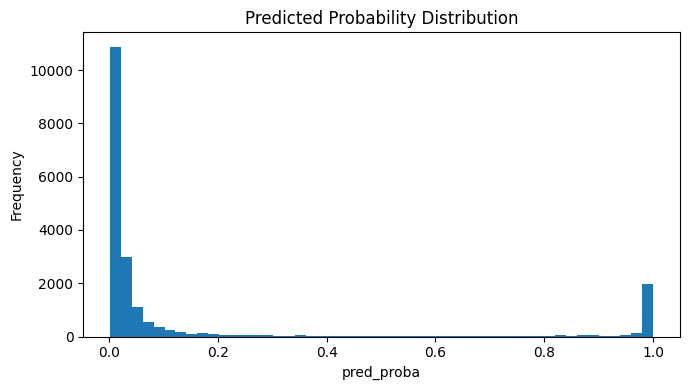

In [39]:
# ============================================================
# CHAPTER 7.1 - Probability Distribution
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(xgb_scored_df["pred_proba"], bins=50)
plt.title("Predicted Probability Distribution")
plt.xlabel("pred_proba")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 🔹 7.2 Risk Banding

We convert probabilities into interpretable risk levels:

- Low Risk → safe / stable
- Moderate Risk → monitor closely
- High Risk → potential deterioration

---

Example thresholds:

- Low: < 0.30
- Moderate: 0.30 – 0.60
- High: > 0.60

---

Goal:

Make model outputs understandable to clinicians.

In [40]:
# ============================================================
# CHAPTER 7.2 - Risk Bands
# ============================================================

def assign_risk_band(p):
    if p < 0.30:
        return "low"
    elif p < 0.60:
        return "moderate"
    else:
        return "high"

xgb_scored_df["risk_band"] = xgb_scored_df["pred_proba"].apply(assign_risk_band)

print("Risk band distribution:")
display(xgb_scored_df["risk_band"].value_counts())

Risk band distribution:


risk_band
low         16888
high         2693
moderate      423
Name: count, dtype: int64

## 🔹 7.3 Threshold-Based Classification

We convert probabilities into binary predictions using a threshold.

Example:

    pred_proba ≥ threshold → alert candidate

---

Threshold choice controls:

- Recall (catch more events)
- Precision (reduce false alerts)
- Alert burden (how many alerts are generated)

---

 Goal:

Prepare signals for alert generation.

In [41]:
# ============================================================
# CHAPTER 7.3 - Threshold Predictions
# ============================================================

threshold = 0.30

xgb_scored_df["pred_label"] = (
    xgb_scored_df["pred_proba"] >= threshold
).astype(int)

print("Predicted positives:", xgb_scored_df["pred_label"].sum())

Predicted positives: 3116


## 🔹 7.4 Threshold Tuning

We evaluate multiple thresholds to understand tradeoffs between:

- Precision (false alert control)
- Recall (event detection)
- Alert volume

---

This step is critical for:

- Minimizing alert fatigue
- Maintaining clinical usefulness

---

 Goal:

Find a threshold that balances detection and usability.

In [42]:
# ============================================================
# CHAPTER 7.4 - Threshold Sweep
# ============================================================

from sklearn.metrics import precision_score, recall_score

thresholds = [0.10, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

rows = []

for t in thresholds:
    y_pred = (xgb_scored_df["pred_proba"] >= t).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "alerts": int(y_pred.sum())
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

,threshold,precision,recall,alerts
0,0.10,0.594647,0.984038,4147
1,0.20,0.721060,0.976856,3395
2,0.25,0.751773,0.972865,3243
3,0.30,0.778562,0.968077,3116
4,0.35,0.798942,0.964086,3024
5,0.40,0.815593,0.960096,2950
6,0.50,0.850714,0.950519,2800


## 🔹 7.5 Threshold Tradeoff Visualization

We visualize how thresholds impact:

- Precision
- Recall
- Alert volume

---

 Goal:

Make threshold selection intuitive and explainable.

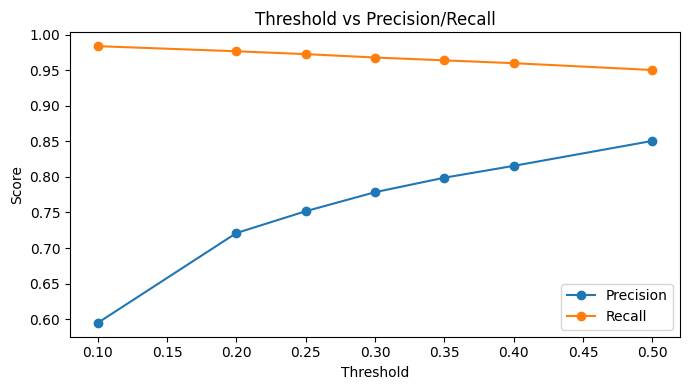

In [43]:
# ============================================================
# CHAPTER 7.5 - Plot Threshold Tradeoff
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(threshold_df["threshold"], threshold_df["precision"], marker='o', label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker='o', label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision/Recall")
plt.legend()
plt.tight_layout()
plt.show()

## 🔹 Chapter 7 Summary

We transformed raw model outputs into structured risk signals:

- Assigned interpretable risk bands
- Evaluated threshold tradeoffs
- Quantified alert burden

---

This chapter connects:

    Modeling → Clinical Decision Signals

---


Next:

- Convert these signals into alert episodes  
- Apply GSS to control alert behavior  
- Introduce BMS for environment-aware adaptation

# 🔹 Chapter 8 — Alert Episode Logic

In this chapter, we convert risk signals into actionable alert episodes.

Instead of triggering alerts at every time step, we introduce:

- Threshold-based activation
- Persistence (signal must repeat)
- Cooldown (prevents alert spam)

---

 Goal:

Transform:

    continuous risk scores

Into:

    discrete, meaningful alert episodes

---

 Why it matters:

Without control, models generate too many alerts → alert fatigue  
With this logic, alerts become:

- sparse
- meaningful
- clinically usable

## 🔹 8.1 Alert System Setup

We define key parameters:

- threshold → minimum risk to trigger alerts
- persistence → number of consecutive signals required
- cooldown → minimum spacing between alerts

---

 Goal:

Control alert sensitivity and frequency.

In [44]:
# ============================================================
# CHAPTER 8.1 - Setup
# ============================================================

alert_df = xgb_scored_df.copy()

threshold = 0.30
persistence_steps =2
cooldown_steps = 6  # 30 minutes (6 × 5-min intervals)

print("Threshold:", threshold)
print("Persistence:", persistence_steps)
print("Cooldown:", cooldown_steps)

Threshold: 0.3
Persistence: 2
Cooldown: 6


## 🔹 8.2 Threshold Signal

We identify time steps where predicted risk exceeds the threshold.

---

This creates a raw binary signal:

    1 → potential alert candidate  
    0 → no alert

---

 Goal:

Detect initial signs of risk before filtering.

In [45]:
# ============================================================
# CHAPTER 8.2 - Threshold Signal
# ============================================================

alert_df["above_threshold"] = (
    alert_df["pred_proba"] >= threshold
).astype(int)

## 🔹 8.3 Persistence Requirement

We require signals to persist across multiple time steps.

Why?

- Removes noise
- Prevents one-off spikes from triggering alerts

---

Logic:

An alert is valid only if:

    signal(t) == 1 AND signal(t-1) == 1

---

 Goal:

Ensure alerts represent sustained risk, not noise.

In [46]:
# ============================================================
# CHAPTER 8.3 - Persistence
# ============================================================

alert_df["above_prev"] = (
    alert_df.groupby("patient_id")["above_threshold"]
    .shift(1)
    .fillna(0)
    .astype(int)
)

alert_df["persistent_signal"] = (
    (alert_df["above_threshold"] == 1) &
    (alert_df["above_prev"] == 1)
).astype(int)

## 🔹 8.4 Cooldown & Episode Formation

We group signals into **alert episodes**.

Once an alert fires:

- we suppress new alerts for a fixed time window (cooldown)

---

Why?

- Prevent alert spam
- Group continuous risk into a single meaningful event

---

 Goal:

Convert repeated signals into single alert episodes.

In [47]:
# ============================================================
# CHAPTER 8.4 - Cooldown Episodes
# ============================================================

alert_flags = []

for _, patient_df in alert_df.groupby("patient_id", sort=False):
    cooldown = 0

    for signal in patient_df["persistent_signal"]:
        if cooldown > 0:
            alert_flags.append(0)
            cooldown -= 1

        elif signal == 1:
            alert_flags.append(1)
            cooldown = cooldown_steps

        else:
            alert_flags.append(0)

alert_df["alert_episode_flag"] = alert_flags

## 🔹 8.5 Alert Summary

We summarize how many alert episodes were generated.

---

 Goal:

Measure alert burden before applying GSS.

In [48]:
# ============================================================
# CHAPTER 8.5 - Summary
# ============================================================

total_alerts = alert_df["alert_episode_flag"].sum()

print(" Total alert episodes:", int(total_alerts))

 Total alert episodes: 453


## 🔹 8.6 Inspect Alert Events

We extract rows where alert episodes occur.

---

 Goal:

Visually verify alert behavior.

In [49]:
# ============================================================
# CHAPTER 8.6 - Inspect Alerts
# ============================================================

alerts_view = alert_df.loc[
    alert_df["alert_episode_flag"] == 1,
    ["patient_id", "timestamp", "pred_proba", "risk_band", "target"]
]

display(alerts_view.head(20))

,patient_id,timestamp,pred_proba,risk_band,target
552,P00019,2026-01-01 01:00:00,0.625740,high,0
655,P00019,2026-01-01 09:35:00,0.534426,moderate,0
665,P00019,2026-01-01 10:25:00,0.358914,moderate,0
672,P00019,2026-01-01 11:00:00,0.702194,high,0
679,P00019,2026-01-01 11:35:00,0.440020,moderate,0
686,P00019,2026-01-01 12:10:00,0.734443,high,0
693,P00019,2026-01-01 12:45:00,0.461025,moderate,0
700,P00019,2026-01-01 13:20:00,0.661226,high,0
707,P00019,2026-01-01 13:55:00,0.873092,high,0
714,P00019,2026-01-01 14:30:00,0.673745,high,0


## 🔹 Chapter 8 Summary

We converted risk scores into structured alert episodes using:

- Thresholding
- Persistence filtering
- Cooldown grouping

---

Result:

Alerts are now:

- less noisy
- temporally meaningful
- ready for GSS processing

---

Next:

- Apply GSS (suppression + escalation logic)  
- Add clinical intelligence to alert decisions

# 🔹 Chapter 9 — GSS v3.1 (Guided Suppression System)

In this chapter, we apply the Guided Suppression System (GSS) to refine alert behavior.

GSS transforms raw alert episodes into clinically meaningful signals by:

- Suppressing redundant alerts
- Enforcing temporal spacing
- Preventing post-event noise
- Tracking escalation reasoning

---

 Goal:

Transform:

    alert episodes

Into:

    clinically intelligent alert decisions

---

 Key Concept:

The model predicts risk  
The alert system triggers signals  
GSS decides whether the signal should become an action

## 🔹 9.1 Prepare GSS Input

We prepare the dataset for GSS by ensuring:

- Required columns exist
- Event signals are stable
- Alert flags are available

---

 Goal:

Provide a clean, structured input for the suppression system.

In [50]:
# ============================================================
# CHAPTER 9.1 - Prepare GSS Input
# ============================================================

from bire.evaluation import analysis

gss_df = alert_df.copy()

print("Input shape:", gss_df.shape)

Input shape: (20004, 87)


## 🔹 9.2 Stable Event Signal

We stabilize the event signal to prevent noisy behavior around deterioration events.

This introduces:

    event_now_stable

---

Why this matters:

- Prevents rapid on/off flipping
- Enables correct post-event suppression
- Improves temporal consistency

---

 Goal:

Ensure event signals are reliable before suppression logic.

In [51]:
# ============================================================
# CHAPTER 9.2 - Stable Event Signal
# ============================================================

gss_df = analysis.add_stable_event_signal(
    gss_df,
    event_col="event_now",
    patient_col="patient_id",
    output_col="event_now_stable",
    persistence_window=3
)

print("✅ Stable event signal added")

✅ Stable event signal added


## 🔹 9.3 Apply GSS v3.1

We apply the full suppression and escalation logic.

GSS performs:

- Alert suppression (remove redundant alerts)
- Alert spacing (avoid clustering)
- Escalation detection (rising risk)
- Post-event suppression (remove late alerts)

---

 Goal:

Convert alert episodes into meaningful alert decisions.

In [52]:
# ============================================================
# CHAPTER 9.3 - Apply GSS
# ============================================================

gss_df = analysis.apply_gss_with_delta_override(
    gss_df,
    prob_col="pred_proba",
    alert_col="alert_episode_flag",
    patient_col="patient_id",
    time_col="timestamp",
    event_col="event_now_stable",

    gss_alert_col="gss_alert",
    suppressed_col="gss_suppressed",
    escalation_col="gss_escalation",
    escalation_reason_col="gss_escalation_reason",

    risk_delta=0.013,
    escalation_threshold=0.997
)

print("✅ GSS applied")

✅ GSS applied


In [53]:
# ============================================================
# SAVE FINAL SYSTEM OUTPUTS (FREEZE STEP)
# ============================================================

gss_df.to_csv("/kaggle/working/bire_v1_outputs.csv", index=False)

print("Final system outputs saved ✅")

Final system outputs saved ✅


## 🔹 9.4 GSS Summary

We evaluate how GSS modifies alert behavior.

We measure:

- Alerts kept
- Alerts suppressed
- Escalations

---

 Goal:

Quantify how much noise was removed.

In [54]:
# ============================================================
# CHAPTER 9.4 - Summary
# ============================================================

summary = gss_df[[
    "gss_alert",
    "gss_suppressed",
    "gss_escalation"
]].value_counts(dropna=False)

display(summary)

print("\nTotals:")
print("Alerts:", int(gss_df["gss_alert"].sum()))
print("Suppressed:", int(gss_df["gss_suppressed"].sum()))
print("Escalations:", int(gss_df["gss_escalation"].sum()))

gss_alert  gss_suppressed  gss_escalation
False      False           False             19551
           True            False               254
True       False           True                199
Name: count, dtype: int64


Totals:
Alerts: 199
Suppressed: 254
Escalations: 199


## 🔹 9.5 Inspect Suppressed Alerts

We analyze suppressed alerts to understand:

- Why alerts were suppressed
- Whether suppression is clinically reasonable

---

 Goal:

Ensure suppression improves quality, not removes true signals.

In [55]:
# ============================================================
# CHAPTER 9.5 - Inspect Suppressed Alerts
# ============================================================

suppressed_cases = gss_df[
    gss_df["gss_suppressed"] == True
][
    ["patient_id", "timestamp", "event_now", "gss_escalation_reason"]
]

display(suppressed_cases.head(10))

,patient_id,timestamp,event_now,gss_escalation_reason
655,P00019,2026-01-01 09:35:00,0,suppressed_stable
665,P00019,2026-01-01 10:25:00,0,suppressed_stable
679,P00019,2026-01-01 11:35:00,0,suppressed_stable
693,P00019,2026-01-01 12:45:00,0,suppressed_stable
721,P00019,2026-01-01 15:05:00,0,suppressed_stable
728,P00019,2026-01-01 15:40:00,0,suppressed_stable
935,P00022,2026-01-01 08:55:00,1,suppressed_post_event
1123,P00031,2026-01-01 15:35:00,1,suppressed_post_event
1130,P00031,2026-01-01 16:10:00,1,suppressed_post_event
1137,P00031,2026-01-01 16:45:00,1,suppressed_post_event


## 🔹 9.6 Before vs After Comparison

We compare alert counts before and after GSS.

---

 Goal:

Measure reduction in alert burden.

In [56]:
# ============================================================
# CHAPTER 9.6 - Before vs After
# ============================================================

before = alert_df["alert_episode_flag"].sum()
after = gss_df["gss_alert"].sum()

print("Before GSS:", int(before))
print("After GSS:", int(after))
print("Reduction:", int(before - after))

Before GSS: 453
After GSS: 199
Reduction: 254


In [57]:
############################################################# FROZEN #########################################
# ============================================================
# SAVE METRICS SNAPSHOT
# ============================================================

import json

metrics_snapshot = {
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "alerts_total": int(gss_df["gss_alert"].sum()),
    "patients": int(gss_df["patient_id"].nunique()),
}

with open("/kaggle/working/bire_v1_metrics.json", "w") as f:
    json.dump(metrics_snapshot, f, indent=4)

print("Metrics frozen ✅")

Metrics frozen ✅


## 🔹 Chapter 9 Summary

We applied GSS to transform alert episodes into intelligent alert decisions.

GSS introduced:

- Suppression of redundant alerts
- Temporal spacing
- Escalation detection
- Post-event control

---

Result:

Alerts are now:

- fewer
- more meaningful
- clinically interpretable

---

Next:

- Apply BMS (environment-aware behavior)  
- Customize alert logic for ICU, ER, outpatient settings

# 🔹 Chapter 10 — BMS (BIRE Mode Selector)

In this chapter, we introduce BMS — the BIRE Mode Selector.

BMS allows the same underlying model and alert system to behave differently
depending on the clinical environment.

---

### Why BMS is needed

Different environments require different alert strategies:

- ICU → balanced sensitivity and precision
- ER Critical → aggressive detection (early warning)
- Scheduled Visits → conservative (avoid unnecessary alerts)

---

### What BMS controls

Each mode adjusts:

- Risk thresholds
- Alert spacing (cooldown)
- Escalation sensitivity
- Post-event suppression behavior

---

 Goal:

Transform BIRE into a **context-aware clinical system**

---

 Key Idea:

Same model  
Different environments  
Different decisions

## 🔹 10.1 Define BMS Modes

We define the environments where BIRE operates:

- ICU
- ER Critical
- Scheduled Visit

---

 Goal:

Simulate real-world deployment scenarios.

In [58]:
# ============================================================
# CHAPTER 10.1 - Define Modes
# ============================================================

modes = ["icu", "er_critical", "scheduled_visit"]

print("Modes:", modes)

Modes: ['icu', 'er_critical', 'scheduled_visit']


## 🔹 10.2 Apply Mode-Specific Configurations

Each mode has a configuration that controls alert behavior.

We retrieve these configurations from the backend and optionally adjust them.

---

 Goal:

Customize alert behavior per environment.

In [59]:
# ============================================================
# CHAPTER 10.2 - Apply BMS Modes
# ============================================================

bms_results = {}

for mode in modes:
    config = analysis.get_bms_mode_config(mode)

    # Optional tuning (you can refine these later)
    if mode == "er_critical":
        config["min_alert_spacing_steps"] = 1
        config["post_event_min_delta_signals"] = 1
        config["early_warning_risk_threshold"] = 0.45

    elif mode == "icu":
        config["min_alert_spacing_steps"] = 2
        config["post_event_min_delta_signals"] = 3
        config["early_warning_risk_threshold"] = 0.65

    elif mode == "scheduled_visit":
        config["min_alert_spacing_steps"] = 4
        config["post_event_min_delta_signals"] = 4
        config["early_warning_risk_threshold"] = 0.85

    df_mode = analysis.apply_gss_with_delta_override(
        gss_df.copy(),
        prob_col="pred_proba",
        alert_col="alert_episode_flag",
        patient_col="patient_id",
        time_col="timestamp",
        event_col="event_now_stable",

        gss_alert_col=f"{mode}_alert",
        suppressed_col=f"{mode}_suppressed",
        escalation_col=f"{mode}_escalation",
        escalation_reason_col=f"{mode}_escalation_reason",

        risk_delta=config["risk_threshold"],
        escalation_threshold=config["risk_threshold"],
        min_alert_spacing_steps=config["min_alert_spacing_steps"],
        early_warning_risk_threshold=config["early_warning_risk_threshold"],
        post_event_min_delta_signals=config["post_event_min_delta_signals"],
    )

    bms_results[mode] = df_mode

print("✅ BMS applied for all modes")

✅ BMS applied for all modes


## 🔹 10.3 Compare Mode Behavior

We compare how different environments affect:

- Number of alerts
- Suppression behavior

---

 Goal:

Understand tradeoffs between sensitivity and alert fatigue.

In [60]:
# ============================================================
# CHAPTER 10.3 - Mode Comparison
# ============================================================

summary = []

for mode, df_mode in bms_results.items():
    alerts = df_mode[f"{mode}_alert"].sum()
    suppressed = df_mode[f"{mode}_suppressed"].sum()

    summary.append({
        "mode": mode,
        "alerts": int(alerts),
        "suppressed": int(suppressed)
    })

import pandas as pd
summary_df = pd.DataFrame(summary)

display(summary_df)

,mode,alerts,suppressed
0,icu,178,275
1,er_critical,208,245
2,scheduled_visit,143,310


## 🔹 10.4 Inspect Mode Output

We inspect a specific mode (e.g., ICU) to understand:

- Alert timing
- Suppression decisions
- Escalation reasoning

---

 Goal:

Validate that behavior aligns with clinical expectations.

In [61]:
# ============================================================
# CHAPTER 10.4 - Inspect ICU Mode
# ============================================================

icu_df = bms_results["icu"]

display(
    icu_df[
        ["patient_id", "timestamp", "pred_proba",
         "icu_alert", "icu_suppressed", "icu_escalation"]
    ].head(20)
)

,patient_id,timestamp,pred_proba,icu_alert,icu_suppressed,icu_escalation
0,P00003,2026-01-01 00:00:00,0.011008,False,False,False
1,P00003,2026-01-01 00:05:00,0.006172,False,False,False
2,P00003,2026-01-01 00:10:00,0.010867,False,False,False
3,P00003,2026-01-01 00:15:00,0.012552,False,False,False
4,P00003,2026-01-01 00:20:00,0.016360,False,False,False
5,P00003,2026-01-01 00:25:00,0.010551,False,False,False
6,P00003,2026-01-01 00:30:00,0.011028,False,False,False
7,P00003,2026-01-01 00:35:00,0.010136,False,False,False
8,P00003,2026-01-01 00:40:00,0.011309,False,False,False
9,P00003,2026-01-01 00:45:00,0.019193,False,False,False


## 🔹 Chapter 10 Summary

We introduced BMS to make BIRE environment-aware.

BMS allows:

- Same model → different behaviors
- Controlled alert sensitivity
- Reduced alert fatigue in low-risk settings
- Aggressive detection in critical settings

---

System now:

Model → Risk → Alerts → GSS → BMS → Clinical Decisions

---

 Final Outcome:

BIRE is no longer just predictive — it is adaptive.

---

Next:

- Clinical dashboard  
- Patient-level demo  
- Explanation layer (Gemma)

# 🔹 Chapter 11 — Clinical Output & Explanation

In this chapter, we translate BIRE’s internal outputs into
clinician-facing insights.

We combine:

- Model predictions (risk)
- Alert system (episodes)
- GSS decisions (suppression, escalation)
- BMS behavior (environment adaptation)

---

### What we produce

For each patient:

- Risk score (0–1)
- Risk band (low / moderate / high)
- Alert status
- Key drivers (top contributing signals)
- Trend summary
- Clinical explanation (Gemma)

---

 Goal:

Transform:

    data + models

Into:

    actionable clinical intelligence

## 🔹 11.1 Select Demo Patient

We select a representative patient for demonstration.

Criteria:

- High number of alerts
- High maximum risk
- Sufficient timeline

---

 Goal:

Showcase system behavior clearly.

In [62]:
# ============================================================
# CHAPTER 11.1 - Select Demo Patient
# ============================================================

from bire.evaluation.demo_utils import select_best_demo_patient

# Build patient-level trajectory summary first
trajectory_summary_df = (
    gss_df
    .groupby("patient_id")
    .agg(
        n_alerts=("gss_alert", "sum"),
        max_risk=("pred_proba", "max"),
        n_rows=("timestamp", "count"),
    )
    .reset_index()
)

display(
    trajectory_summary_df
    .sort_values(["n_alerts", "max_risk", "n_rows"], ascending=False)
    .head(10)
)

# Now select best demo patient
demo_patient_id = select_best_demo_patient(trajectory_summary_df)

print("Selected demo patient:", demo_patient_id)

,patient_id,n_alerts,max_risk,n_rows
46,P00263,23,0.975631,276
52,P00285,20,0.999134,276
80,P00428,11,0.959814,108
4,P00019,11,0.946351,288
31,P00178,8,0.997220,192
97,P00495,8,0.986049,228
49,P00271,7,0.999091,276
14,P00093,6,0.999004,420
54,P00303,5,0.999508,288
68,P00386,5,0.999294,432


Selected demo patient: P00263


## 🔹 11.2 Build BIRE Output

We construct a structured output object representing the patient’s state.

This includes:

- Risk score
- Risk band
- Alert status
- Supporting signals

---

 Goal:

Create a unified patient-level summary.

In [63]:
# ============================================================
# CHAPTER 11.2 - Build BIRE Output
# ============================================================

from bire.evaluation.demo_utils import build_bire_output_from_patient

# Use full patient timeline, not a single row
demo_patient_df = (
    gss_df[gss_df["patient_id"] == demo_patient_id]
    .sort_values("timestamp")
    .copy()
)

bire_output = build_bire_output_from_patient(
    demo_patient_df,
    feature_cols=feature_cols,
    bire_model=xgb_model
)

display(bire_output)

{'patient_id': 'P00263',
 'risk_score': 0.153,
 'risk_band': 'low',
 'alert': False,
 'prediction_horizon_minutes': 60,
 'top_drivers': [{'feature': 'cardio_respiratory_stress',
   'value': 11.576347856507269,
   'importance': 0.21085777878761292,
   'direction': 'changing'},
  {'feature': 'shock_index',
   'value': 0.645002149318454,
   'importance': 0.19509029388427734,
   'direction': 'changing'},
  {'feature': 'sbp',
   'value': 103.9245210005046,
   'importance': 0.08183541148900986,
   'direction': 'improving'},
  {'feature': 'spo2',
   'value': 97.97540348557636,
   'importance': 0.05090078338980675,
   'direction': 'improving'},
  {'feature': 'temperature',
   'value': 36.88827447620286,
   'importance': 0.03891772776842117,
   'direction': 'worsening'}],
 'trend_summary': {'spo2': 'Improving ↑',
  'resp_rate': 'Worsening ↑',
  'sbp': 'Improving ↑',
  'heart_rate': 'Improving ↓',
  'temperature': 'Improving ↓'},
 'data_quality': 'adequate'}

## 🔹 11.3 Clinical Dashboard

We convert the output into a clinician-friendly dashboard.

This includes:

- Risk level
- Alert status
- Top drivers
- Trend summary

---

 Goal:

Present information clearly and quickly.

In [64]:
''' 
# ============================================================
# CHAPTER 11.3 - Dashboard
# ============================================================

from bire.evaluation.demo_utils import build_bire_dashboard_markdown

dashboard_md = build_bire_dashboard_markdown(bire_output)

print(dashboard_md)

'''

' \n# ============================================================\n# CHAPTER 11.3 - Dashboard\n# ============================================================\n\nfrom bire.evaluation.demo_utils import build_bire_dashboard_markdown\n\ndashboard_md = build_bire_dashboard_markdown(bire_output)\n\nprint(dashboard_md)\n\n'

## 🔹 11.4 Top Drivers

We identify the most influential signals contributing to the current risk.

---

 Goal:

Explain *why* the model made its prediction.

In [65]:
# ============================================================
# CHAPTER 11.4 - Top Drivers
# ============================================================

from bire.evaluation.demo_utils import build_top_drivers_table

drivers_df = build_top_drivers_table(bire_output)

display(drivers_df)

,feature,value,importance,direction
0,cardio_respiratory_stress,11.576348,0.2109,changing
1,shock_index,0.645002,0.1951,changing
2,sbp,103.924521,0.0818,improving
3,spo2,97.975403,0.0509,improving
4,temperature,36.888274,0.0389,worsening


## 🔹 11.5 Trend Summary

We summarize recent trends in vital signs.

---

 Goal:

Provide context around how the patient is changing.

In [66]:
# ============================================================
# CHAPTER 11.5 - Trend Summary
# ============================================================

from bire.evaluation.demo_utils import build_trend_summary_table

trend_df = build_trend_summary_table(bire_output)

display(trend_df)

,vital,trend
0,spo2,Improving ↑
1,resp_rate,Worsening ↑
2,sbp,Improving ↑
3,heart_rate,Improving ↓
4,temperature,Improving ↓


## 🔹 11.6 Clinical Explanation (Gemma4)

We generate a natural-language explanation of the patient’s condition.

This explanation is:

- Grounded in data
- Clinically cautious
- Interpretable

---

 Goal:

Bridge AI → clinician understanding.

In [67]:
'''
# ============================================================
# CHAPTER 11.6 - Gemma Explanation
# ============================================================

from bire.explanations.gemma_explainer import (
    load_gemma_explainer,
    explain_with_gemma
)

# Load Gemma
gemma_processor, gemma_model = load_gemma_explainer()

explanation = explain_with_gemma(
    bire_output,
    gemma_model,
    gemma_processor
)

print(explanation)

'''

'\n# ============================================================\n# CHAPTER 11.6 - Gemma Explanation\n# ============================================================\n\nfrom bire.explanations.gemma_explainer import (\n    load_gemma_explainer,\n    explain_with_gemma\n)\n\n# Load Gemma\ngemma_processor, gemma_model = load_gemma_explainer()\n\nexplanation = explain_with_gemma(\n    bire_output,\n    gemma_model,\n    gemma_processor\n)\n\nprint(explanation)\n\n'

## 🔹 11.7 Patient Trajectory Visualization

We visualize how risk and vital signs evolve over time.

---

 Goal:

Provide temporal context for clinical decisions.

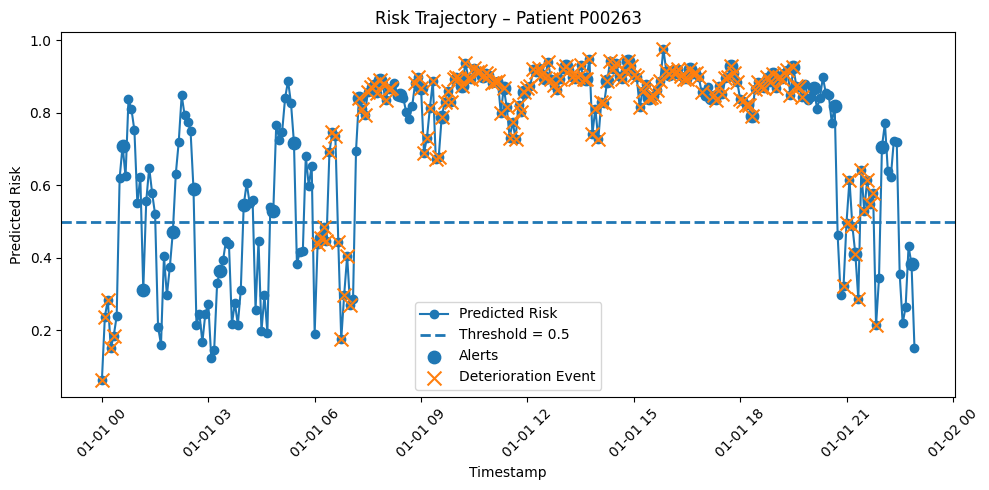

In [68]:
# ============================================================
# CHAPTER 11.7 - Trajectory Plot
# ============================================================

from bire.evaluation.plots import plot_patient_risk_trajectory

patient_df = gss_df[gss_df["patient_id"] == demo_patient_id]

plot_patient_risk_trajectory(
    patient_df,
    patient_id=demo_patient_id
)

##  Chapter 11 Summary

We transformed BIRE into a complete clinical intelligence system.

We combined:

- Prediction (model)
- Alerting (episodes)
- Suppression (GSS)
- Context adaptation (BMS)
- Explanation (Gemma)

---

Final system:

    Data → Features → Model → Risk → Alerts → GSS → BMS → Clinical Output

---

 Outcome:

BIRE is now:

- Interpretable
- Actionable
- Clinically aligned
- System-level (not just a model)

---

 This is no longer a project.

This is a **clinical decision intelligence engine**.

#  Final Conclusion — BIRE Clinical Intelligence System

## Executive Summary

Project Sixth Sense — BIRE (Bio-Intelligence Risk Engine) is a clinical intelligence system designed to detect patient deterioration early, reduce unnecessary alerts, and support real-time clinical decision-making.

The system integrates predictive modeling, intelligent alerting, and contextual reasoning into a unified workflow that transforms raw patient data into actionable insight.

---

## What BIRE Does

BIRE continuously analyzes time-series vital signs and produces:

- A real-time risk score (0–1)
- Risk classification (low, moderate, high)
- Alert decisions (triggered, suppressed, escalated)
- Context-aware behavior (ICU, ER, outpatient modes)
- Clinically interpretable explanations

---

## Key Capabilities

### 1. Early Detection of Deterioration
BIRE predicts patient risk up to 60 minutes in advance, enabling proactive intervention before critical events occur.

---

### 2. Intelligent Alert Management (GSS)
The Guided Suppression System (GSS):

- Reduces redundant alerts
- Prevents alert fatigue
- Suppresses post-event noise
- Highlights meaningful escalation patterns

---

### 3. Environment-Aware Decision Logic (BMS)
The BIRE Mode Selector (BMS) adapts system behavior to clinical context:

- ICU → balanced detection and stability
- ER Critical → aggressive early warning
- Scheduled Visits → conservative alerting

---

### 4. Physiological Understanding
Through advanced feature engineering, BIRE captures:

- Signal instability (volatility)
- Rapid deterioration (acceleration)
- Cross-system stress (cardiorespiratory patterns)
- Patient-specific baselines

---

### 5. Explainable Outputs
BIRE translates predictions into clinician-friendly insights, including:

- Risk interpretation
- Trend summaries
- Key contributing factors
- Natural-language explanations

---

## Impact

BIRE addresses a critical challenge in healthcare:

> Too many alerts reduce trust. Too few alerts miss deterioration.

BIRE balances this by:

- Detecting risk early
- Reducing unnecessary alerts
- Providing clear reasoning for decisions

---

## System Outcome

BIRE is not just a predictive model.

It is a **clinical decision intelligence system** that connects:

    Data → Prediction → Alerting → Suppression → Context → Explanation

---

## Strategic Value

BIRE enables:

- Earlier clinical intervention
- Reduced cognitive load for clinicians
- Improved signal-to-noise ratio in monitoring systems
- Scalable deployment across multiple care environments

---

## Final Statement

BIRE represents a shift from:

    reactive monitoring

to:

    proactive clinical intelligence

---

**Motto:** *We sense what others miss*  
**Sub-motto:** *Because what happens next… starts quietly.*

### EHR-Integrated Temporal Feature Extraction (Comming Soon!) (Nope! Not Soon At All, In the Forseeable Future)

A future extension of BIRE is an automated EHR extraction layer that converts structured clinical data into deep temporal features. Instead of relying only on raw vitals, BIRE could ingest vitals, labs, medications, diagnoses, and clinical events, then generate features such as trend velocity, instability, baseline deviation, recovery failure, and cross-signal interactions.

This would allow BIRE to move from a vitals-based early warning prototype toward a broader clinical intelligence system capable of learning deterioration patterns across multiple EHR data streams.

In [69]:
############################### LAST CHECK BEFORE FREEZE ##############################
from pathlib import Path

freeze_files = [
    "/kaggle/working/bire_v1_frozen_data.csv",
    "/kaggle/working/bire_v1_model.pkl",
    "/kaggle/working/bire_v1_outputs.csv",
    "/kaggle/working/bire_v1_metrics.json",
    "/kaggle/working/bire_v1_features.txt",
]

for f in freeze_files:
    path = Path(f)
    print(path.name, "✅" if path.exists() else "❌")

bire_v1_frozen_data.csv ✅
bire_v1_model.pkl ✅
bire_v1_outputs.csv ✅
bire_v1_metrics.json ✅
bire_v1_features.txt ✅


In [70]:
RUN_V1_FREEZE_CHECK = False

if RUN_V1_FREEZE_CHECK:
    from pathlib import Path

    for f in freeze_files:
        path = Path(f)
        print(path.name, "✅" if path.exists() else "❌")

## 12.1 Rebuilding the DataFrame 

Must be done first when implimenting a new Version of the pipeline. Dataframe has to be carried over into current version.

In [71]:
# =========================================
# CHAPTER 12 — V2 BACKEND IMPORTS
# =========================================

from bire.labels.multi_horizon import build_multi_horizon_targets
from bire.features.feature_engineering import get_feature_columns
from bire.pipeline.modeling_pipeline import patient_level_split
from sklearn.metrics import roc_auc_score, average_precision_score
from bire.alerts.gss_v3 import apply_gss_v3
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

In [72]:
# =========================================
# CHAPTER 12.1A — CREATE V2 DATAFRAME
# =========================================

base_df = cycle1_df.copy()

v2_df = build_multi_horizon_targets(
    df=base_df,
    patient_col="patient_id",
    time_col="timestamp",
    event_col="event_now",
)

print("v2_df created successfully.")
print("Shape:", v2_df.shape)

v2_df[[
    "patient_id",
    "timestamp",
    "event_now",
    "target_15min",
    "target_30min",
    "target_60min",
]].head()

v2_df created successfully.
Shape: (99432, 83)


,patient_id,timestamp,event_now,target_15min,target_30min,target_60min
0,P00001,2026-01-01 00:00:00,0,0,0,0
1,P00001,2026-01-01 00:05:00,0,0,0,0
2,P00001,2026-01-01 00:10:00,0,0,0,0
3,P00001,2026-01-01 00:15:00,0,0,0,0
4,P00001,2026-01-01 00:20:00,0,0,0,0


## 12.2 Multi-Target Modeling Strategy BIRE v2

BIRE V2 upgrades the model from a single 60-minute binary deterioration prediction into a multi-horizon temporal risk system.

Instead of asking only:

> Will deterioration occur within 60 minutes?

BIRE V2 asks:

> How soon may deterioration occur?

Targets:
- `target_15min` — near-term urgency
- `target_30min` — approaching instability
- `target_60min` — early warning horizon

Modeling strategy:
- Train one XGBoost model per horizon
- Use the same leakage-safe feature set
- Use the same patient-level train/test split across all horizons
- Compare ROC-AUC and PR-AUC per horizon

This keeps V2 interpretable, modular, and clinically easier to evaluate.

In [73]:
# =========================================
# CHAPTER 12.2 — VERIFY V2 TARGETS
# =========================================

required_v2_targets = [
    "target_15min",
    "target_30min",
    "target_60min",
]

missing_targets = [col for col in required_v2_targets if col not in v2_df.columns]

if missing_targets:
    raise ValueError(f"Missing V2 target columns: {missing_targets}")

print("V2 targets found:")
for col in required_v2_targets:
    print(f"{col}: {v2_df[col].sum()} positives / {len(v2_df)} rows")

V2 targets found:
target_15min: 12405 positives / 99432 rows
target_30min: 13214 positives / 99432 rows
target_60min: 14465 positives / 99432 rows


In [74]:
# =========================================
# CHAPTER 12.2.1 — SAFE V2 FEATURE SELECTION
# =========================================

base_feature_cols = get_feature_columns(v2_df)

forbidden_cols = {
    "event_now",
    "target",
    "target_15min",
    "target_30min",
    "target_60min",
}

forbidden_keywords = [
    "target",
    "event_now",
    "alert",
    "gss",
    "risk",
    "pred",
    "proba",
    "timing",
    "lead",
    "label",
]

feature_cols = [
    col for col in base_feature_cols
    if col in v2_df.columns
    and col not in forbidden_cols
    and not any(keyword in col.lower() for keyword in forbidden_keywords)
]

print("Original feature count:", len(base_feature_cols))
print("Safe feature count:", len(feature_cols))
print("Removed:")
print(sorted(set(base_feature_cols) - set(feature_cols)))

Original feature count: 81
Safe feature count: 76
Removed:
['event_now', 'target', 'target_15min', 'target_30min', 'target_60min']


### 12.2 - Leakage Audit Result

Initial V2 multi-horizon modeling produced unrealistically perfect separation.  
A feature leakage audit found that `event_now`, `target`, `target_15min`, `target_30min`, and `target_60min` were being included in the model feature set.

These columns were removed from `feature_cols`.

All V2 modeling after this point uses leakage-safe features only.

In [75]:
# =========================================
# CHAPTER 12.4 — PATIENT-LEVEL SPLIT
# =========================================

train_df, test_df = patient_level_split(
    v2_df,
    patient_col="patient_id",
    target_col="target_60min",
    test_size=0.2,
    random_state=42,
)

print("Train rows:", train_df.shape)
print("Test rows:", test_df.shape)

print("Train patients:", train_df["patient_id"].nunique())
print("Test patients:", test_df["patient_id"].nunique())

overlap = set(train_df["patient_id"]).intersection(set(test_df["patient_id"]))

if overlap:
    raise ValueError("Patient leakage detected between train and test split.")

print("Patient-level split passed. No patient overlap.")

Train rows: (78948, 83)
Test rows: (20484, 83)
Train patients: 400
Test patients: 100
Patient-level split passed. No patient overlap.


In [76]:
# =========================================
# CHAPTER 12.5 — TRAIN V2 HORIZON MODELS
# =========================================

horizon_targets = {
    "15min": "target_15min",
    "30min": "target_30min",
    "60min": "target_60min",
}

v2_models = {}
v2_metrics = {}
v2_scored_test_df = test_df.copy()

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

for horizon_name, target_col in horizon_targets.items():
    print("=" * 70)
    print(f"Training BIRE V2 model for horizon: {horizon_name}")
    print(f"Target column: {target_col}")

    y_train = train_df[target_col]
    y_test = test_df[target_col]

    model = XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)

    risk_col = f"risk_{horizon_name}"
    y_proba = model.predict_proba(X_test)[:, 1]

    v2_scored_test_df[risk_col] = y_proba

    if y_test.nunique() >= 2:
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    v2_models[horizon_name] = model

    v2_metrics[horizon_name] = {
        "target_col": target_col,
        "risk_col": risk_col,
        "positive_rate_train": float(y_train.mean()),
        "positive_rate_test": float(y_test.mean()),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }

    print(f"Train positive rate: {y_train.mean():.4f}")
    print(f"Test positive rate:  {y_test.mean():.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC: unavailable")
    print(f"PR-AUC:  {pr_auc:.4f}" if not np.isnan(pr_auc) else "PR-AUC: unavailable")

print("=" * 70)
print("BIRE V2 multi-horizon modeling complete.")

Training BIRE V2 model for horizon: 15min
Target column: target_15min
Train positive rate: 0.1269
Test positive rate:  0.1166
ROC-AUC: 0.9988
PR-AUC:  0.9857
Training BIRE V2 model for horizon: 30min
Target column: target_30min
Train positive rate: 0.1356
Test positive rate:  0.1224
ROC-AUC: 0.9982
PR-AUC:  0.9818
Training BIRE V2 model for horizon: 60min
Target column: target_60min
Train positive rate: 0.1486
Test positive rate:  0.1335
ROC-AUC: 0.9942
PR-AUC:  0.9756
BIRE V2 multi-horizon modeling complete.


In [77]:
# =========================================
# CHAPTER 12.6 — V2 METRICS SUMMARY
# =========================================

v2_metrics_df = pd.DataFrame(v2_metrics).T.reset_index()
v2_metrics_df = v2_metrics_df.rename(columns={"index": "horizon"})

v2_metrics_df

,horizon,target_col,risk_col,positive_rate_train,positive_rate_test,roc_auc,pr_auc
0,15min,target_15min,risk_15min,0.126868,0.116628,0.998785,0.985714
1,30min,target_30min,risk_30min,0.135621,0.122388,0.998163,0.981768
2,60min,target_60min,risk_60min,0.148579,0.133519,0.994208,0.975596


In [78]:
# =========================================
# CHAPTER 12.7 — INSPECT MULTI-HORIZON RISKS
# =========================================

risk_cols = [
    "risk_15min",
    "risk_30min",
    "risk_60min",
]

preview_cols = [
    "patient_id",
    "timestamp",
    "event_now",
    "target_15min",
    "target_30min",
    "target_60min",
] + risk_cols

v2_scored_test_df[preview_cols].head(30)

,patient_id,timestamp,event_now,target_15min,target_30min,target_60min,risk_15min,risk_30min,risk_60min
396,P00003,2026-01-01 00:00:00,0,0,0,0,0.001655,0.005135,0.007552
397,P00003,2026-01-01 00:05:00,0,0,0,0,0.000478,0.001218,0.001118
398,P00003,2026-01-01 00:10:00,0,0,0,0,0.000590,0.000606,0.002158
399,P00003,2026-01-01 00:15:00,0,0,0,0,0.000625,0.000540,0.001778
400,P00003,2026-01-01 00:20:00,0,0,0,0,0.000941,0.000694,0.002993
401,P00003,2026-01-01 00:25:00,0,0,0,0,0.000581,0.000570,0.001817
402,P00003,2026-01-01 00:30:00,0,0,0,0,0.000291,0.000283,0.001538
403,P00003,2026-01-01 00:35:00,0,0,0,0,0.000361,0.000250,0.001630
404,P00003,2026-01-01 00:40:00,0,0,0,0,0.000231,0.000343,0.002356
405,P00003,2026-01-01 00:45:00,0,0,0,0,0.000346,0.000515,0.006049


In [79]:
# =========================================
# CHAPTER 12.8 — RISK DISTRIBUTION AUDIT
# =========================================

risk_cols = ["risk_15min", "risk_30min", "risk_60min"]

v2_scored_test_df[risk_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
risk_15min,20484.0,0.116756,0.311406,0.000043,0.000231,0.000378,0.001057,0.998665
risk_30min,20484.0,0.123178,0.317192,0.000102,0.000347,0.000653,0.002237,0.998982
risk_60min,20484.0,0.135028,0.322926,0.000183,0.001604,0.003171,0.010635,0.999859


In [80]:
# =========================================
# CHAPTER 12.9 — INSPECT POSITIVE TARGET ROWS
# =========================================

positive_rows = v2_scored_test_df[
    (v2_scored_test_df["target_15min"] == 1) |
    (v2_scored_test_df["target_30min"] == 1) |
    (v2_scored_test_df["target_60min"] == 1)
].copy()

print("Positive rows in test set:", len(positive_rows))
print("Positive patients in test set:", positive_rows["patient_id"].nunique())

positive_rows[
    [
        "patient_id",
        "timestamp",
        "event_now",
        "target_15min",
        "target_30min",
        "target_60min",
        "risk_15min",
        "risk_30min",
        "risk_60min",
    ]
].head(50)

Positive rows in test set: 2735
Positive patients in test set: 36


,patient_id,timestamp,event_now,target_15min,target_30min,target_60min,risk_15min,risk_30min,risk_60min
4814,P00024,2026-01-01 11:10:00,0,0,0,1,0.015075,0.023897,0.054776
4815,P00024,2026-01-01 11:15:00,0,0,0,1,0.049830,0.038547,0.064975
4816,P00024,2026-01-01 11:20:00,0,0,0,1,0.177609,0.211731,0.385653
4817,P00024,2026-01-01 11:25:00,0,0,0,1,0.115659,0.388432,0.634278
4818,P00024,2026-01-01 11:30:00,0,0,0,1,0.145520,0.409685,0.825580
4819,P00024,2026-01-01 11:35:00,0,0,0,1,0.390845,0.689152,0.928494
4820,P00024,2026-01-01 11:40:00,0,0,1,1,0.195263,0.400383,0.872166
4821,P00024,2026-01-01 11:45:00,0,0,1,1,0.118561,0.394622,0.794377
4822,P00024,2026-01-01 11:50:00,0,0,1,1,0.241124,0.613857,0.838396
4823,P00024,2026-01-01 11:55:00,0,1,1,1,0.271706,0.625145,0.915905


In [81]:
# =========================================
# CHAPTER 13.0 — RISK SEPARATION CHECK
# =========================================

for target_col, risk_col in {
    "target_15min": "risk_15min",
    "target_30min": "risk_30min",
    "target_60min": "risk_60min",
}.items():
    print("=" * 60)
    print(target_col, "→", risk_col)

    summary = (
        v2_scored_test_df
        .groupby(target_col)[risk_col]
        .agg(["count", "mean", "median", "min", "max"])
    )

    display(summary)

target_15min → risk_15min


,count,mean,median,min,max
target_15min,,,,,
0,18095,0.006401,0.000333,0.000043,0.995319
1,2389,0.952616,0.981193,0.003811,0.998665


target_30min → risk_30min


,count,mean,median,min,max
target_30min,,,,,
0,17977,0.008376,0.000548,0.000102,0.994677
1,2507,0.946394,0.982307,0.001937,0.998982


target_60min → risk_60min


,count,mean,median,min,max
target_60min,,,,,
0,17749,0.014466,0.002618,0.000183,0.995056
1,2735,0.917427,0.982392,0.001499,0.999859


In [82]:
# =========================================
# CHAPTER 13.1 — FEATURE LEAKAGE AUDIT
# =========================================

forbidden_patterns = [
    "target",
    "event_now",
    "alert",
    "gss",
    "risk",
    "pred",
    "proba",
    "timing",
    "lead",
    "label",
]

suspect_features = [
    col for col in feature_cols
    if any(pattern in col.lower() for pattern in forbidden_patterns)
]

print("Number of feature columns:", len(feature_cols))
print("Suspect/leaky features found:", len(suspect_features))

suspect_features

Number of feature columns: 76
Suspect/leaky features found: 0


[]

In [83]:
print([col for col in feature_cols if "lag" in col][:5])
print([col for col in feature_cols if "delta" in col][:5])
print([col for col in feature_cols if "rolling" in col][:5])

['heart_rate_lag1', 'heart_rate_lag2', 'resp_rate_lag1', 'resp_rate_lag2', 'spo2_lag1']
['heart_rate_delta', 'resp_rate_delta', 'spo2_delta', 'temperature_delta', 'sbp_delta']
['heart_rate_rolling_mean_6', 'heart_rate_rolling_std_6', 'heart_rate_rolling_min_6', 'heart_rate_rolling_max_6', 'resp_rate_rolling_mean_6']


## 12.3 Risk Trajectory Intelligence

BIRE V2 extends beyond static risk prediction into temporal clinical intelligence.

Instead of evaluating risk at a single time point, we analyze how risk evolves across:
- Short-term horizon (15 min)
- Mid-term horizon (30 min)
- Long-term horizon (60 min)

This allows BIRE to capture:

- Early warning signals (long-horizon risk elevation)
- Approaching instability (risk convergence)
- Imminent deterioration (high short-horizon risk)
- Rapid deterioration (accelerating risk)

Trajectory features provide the foundation for:
- Advanced alerting (GSS V3)
- Clinical interpretation
- Temporal pattern recognition

### 12.3.1 Data Preparation

Trajectory features require strict temporal ordering.

We sort data by:
- patient_id
- timestamp

This ensures all temporal calculations (velocity, acceleration) are valid.

In [84]:
# =========================================
# CHAPTER 13.2 — SORT FOR TRAJECTORY
# =========================================

v2_scored_test_df = v2_scored_test_df.sort_values(
    ["patient_id", "timestamp"]
).reset_index(drop=True)

### 12.3.2 Horizon Structure Features

We derive features that describe relationships between prediction horizons.

Risk Spread:
Difference between long-term and short-term risk.

Risk Convergence:
Agreement across all horizons.
Lower values indicate stronger, more consistent signals.

In [85]:
# =========================================
# CHAPTER 13.3 — HORIZON STRUCTURE FEATURES
# =========================================

df = v2_scored_test_df.copy()

df["risk_spread"] = df["risk_60min"] - df["risk_15min"]

df["risk_convergence"] = (
    (df["risk_60min"] - df["risk_30min"]).abs() +
    (df["risk_30min"] - df["risk_15min"]).abs()
)

v2_scored_test_df = df

### 12.3.3 Temporal Dynamics

We compute how risk changes over time.

Risk Velocity:
Change in long-horizon risk between consecutive time steps.

Risk Acceleration:
Change in velocity over time.

These features capture:
- Gradual deterioration
- Sudden instability
- Rapid clinical decline

In [86]:
# =========================================
# CHAPTER 13.4 — RISK VELOCITY
# =========================================

df = v2_scored_test_df.copy()

df["risk_velocity"] = (
    df.groupby("patient_id")["risk_60min"]
    .diff()
)

v2_scored_test_df = df

In [87]:
# =========================================
# CHAPTER 13.5 — RISK ACCELERATION
# =========================================

df = v2_scored_test_df.copy()

df["risk_acceleration"] = (
    df.groupby("patient_id")["risk_velocity"]
    .diff()
)

v2_scored_test_df = df

### 12.3.4 Interpretation Framework

Trajectory features enable interpretation of patient state:

Early Warning:
- High risk_60min
- Low risk_15min
- High spread

Approaching Instability:
- risk_60min ≈ risk_30min
- Convergence decreasing

Imminent Deterioration:
- risk_15min ≈ risk_30min ≈ risk_60min
- Convergence near zero

Rapid Deterioration:
- Positive velocity
- Positive acceleration

These patterns form the basis of:
- Intelligent alerting
- Clinical prioritization
- System-level decision making

In [88]:
# =========================================
# CHAPTER 13.6 — TRAJECTORY INSPECTION
# =========================================

cols = [
    "patient_id",
    "timestamp",
    "risk_15min",
    "risk_30min",
    "risk_60min",
    "risk_spread",
    "risk_convergence",
    "risk_velocity",
    "risk_acceleration",
]

v2_scored_test_df[cols].head(50)

,patient_id,timestamp,risk_15min,risk_30min,risk_60min,risk_spread,risk_convergence,risk_velocity,risk_acceleration
0,P00003,2026-01-01 00:00:00,0.001655,0.005135,0.007552,0.005897,0.005897,NaN,NaN
1,P00003,2026-01-01 00:05:00,0.000478,0.001218,0.001118,0.000640,0.000840,-0.006435,NaN
2,P00003,2026-01-01 00:10:00,0.000590,0.000606,0.002158,0.001568,0.001568,0.001040,0.007475
3,P00003,2026-01-01 00:15:00,0.000625,0.000540,0.001778,0.001153,0.001323,-0.000380,-0.001420
4,P00003,2026-01-01 00:20:00,0.000941,0.000694,0.002993,0.002052,0.002546,0.001215,0.001595
5,P00003,2026-01-01 00:25:00,0.000581,0.000570,0.001817,0.001236,0.001259,-0.001176,-0.002390
6,P00003,2026-01-01 00:30:00,0.000291,0.000283,0.001538,0.001247,0.001263,-0.000278,0.000897
7,P00003,2026-01-01 00:35:00,0.000361,0.000250,0.001630,0.001270,0.001491,0.000092,0.000370
8,P00003,2026-01-01 00:40:00,0.000231,0.000343,0.002356,0.002124,0.002124,0.000725,0.000634
9,P00003,2026-01-01 00:45:00,0.000346,0.000515,0.006049,0.005703,0.005703,0.003693,0.002968


# Results

The risk trajectory intellingence systemn has showing promising, reasonable results for the sake of the demo. We are going to look at the patient best needed for demontration purposes. 

In [89]:
# =========================================
# CHAPTER 13.7 — FIND HIGH-TRAJECTORY PATIENTS
# =========================================

trajectory_summary = (
    v2_scored_test_df
    .groupby("patient_id")
    .agg(
        max_risk_15=("risk_15min", "max"),
        max_risk_30=("risk_30min", "max"),
        max_risk_60=("risk_60min", "max"),
        max_velocity=("risk_velocity", "max"),
        max_acceleration=("risk_acceleration", "max"),
        mean_convergence=("risk_convergence", "mean"),
        n_events=("event_now", "sum"),
        n_target_60=("target_60min", "sum"),
    )
    .reset_index()
    .sort_values(
        ["max_risk_60", "max_velocity", "n_target_60"],
        ascending=False,
    )
)

trajectory_summary.head(10)

,patient_id,max_risk_15,max_risk_30,max_risk_60,max_velocity,max_acceleration,mean_convergence,n_events,n_target_60
29,P00148,0.994067,0.994872,0.999859,0.601858,0.394148,0.029604,82,93
25,P00135,0.996743,0.998982,0.999824,0.757320,0.593489,0.107839,34,45
89,P00436,0.992103,0.993928,0.999439,0.596206,0.530932,0.061642,19,31
50,P00279,0.987112,0.992916,0.999367,0.750328,0.565937,0.038930,29,40
45,P00247,0.993404,0.996933,0.999329,0.920105,0.945508,0.042268,12,24
31,P00154,0.993291,0.995125,0.999263,0.861441,0.874890,0.044238,161,172
88,P00434,0.988561,0.994221,0.999137,0.391449,0.409066,0.099534,7,18
3,P00031,0.995292,0.997068,0.998968,0.578141,0.708978,0.042286,71,82
53,P00293,0.990856,0.992993,0.998891,0.593337,0.567550,0.036042,34,45
21,P00098,0.998424,0.997642,0.998862,0.402033,0.515173,0.047104,104,115


In [90]:
# =========================================
# CHAPTER 13.8 — INSPECT TOP TRAJECTORY PATIENT
# =========================================

demo_patient_id = trajectory_summary.iloc[0]["patient_id"]

patient_traj_df = v2_scored_test_df[
    v2_scored_test_df["patient_id"] == demo_patient_id
].copy()

cols = [
    "patient_id",
    "timestamp",
    "event_now",
    "target_15min",
    "target_30min",
    "target_60min",
    "risk_15min",
    "risk_30min",
    "risk_60min",
    "risk_spread",
    "risk_convergence",
    "risk_velocity",
    "risk_acceleration",
]

patient_traj_df[cols].head(80)

,patient_id,timestamp,event_now,target_15min,target_30min,target_60min,risk_15min,risk_30min,risk_60min,risk_spread,risk_convergence,risk_velocity,risk_acceleration
6588,P00148,2026-01-01 00:00:00,0,0,0,0,0.001598,0.005162,0.007116,0.005518,0.005518,NaN,NaN
6589,P00148,2026-01-01 00:05:00,0,0,0,0,0.000176,0.000758,0.001867,0.001691,0.001691,-0.005248,NaN
6590,P00148,2026-01-01 00:10:00,0,0,0,0,0.001088,0.000629,0.002635,0.001546,0.002466,0.000768,0.006016
6591,P00148,2026-01-01 00:15:00,0,0,0,0,0.000676,0.000520,0.003346,0.002671,0.002983,0.000712,-0.000056
6592,P00148,2026-01-01 00:20:00,0,0,0,0,0.000671,0.000508,0.002349,0.001678,0.002004,-0.000998,-0.001709
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6663,P00148,2026-01-01 06:15:00,0,0,0,0,0.000509,0.002823,0.021630,0.021120,0.021120,0.013880,0.011906
6664,P00148,2026-01-01 06:20:00,0,0,0,0,0.000764,0.000813,0.006549,0.005785,0.005785,-0.015081,-0.028961
6665,P00148,2026-01-01 06:25:00,0,0,0,0,0.000383,0.000916,0.002735,0.002352,0.002352,-0.003814,0.011267
6666,P00148,2026-01-01 06:30:00,0,0,0,0,0.000168,0.000843,0.003150,0.002982,0.002982,0.000415,0.004229


### Trajectory Validation Note

Initial inspection of the first patient rows showed mostly stable values because the displayed window occurred before the event period.

After expanding the patient timeline, event rows aligned correctly with the patient-level summary.

The difference between `n_target_60` and `n_events` is expected because `target_60min` becomes positive before `event_now`, reflecting forward-looking deterioration prediction.

### 13.9 GSS V3 Design Intent

GSS V3 introduces trajectory-aware decision making to the BIRE system.

Earlier GSS versions focused on:
- Suppressing alerts after an event had already started
- Allowing escalation when worsening physiology was detected

These approaches were primarily reactive and limited in temporal awareness.

GSS V3 extends this by incorporating multi-horizon risk and temporal dynamics.

Trajectory features include:

- `risk_spread = risk_60min - risk_15min`
- `risk_convergence = |risk_60min - risk_30min| + |risk_30min - risk_15min|`
- `risk_velocity = risk_60min(t) - risk_60min(t-1)`
- `risk_acceleration = risk_velocity(t) - risk_velocity(t-1)`

These features allow BIRE to evaluate:

- **Risk awareness**: the current level of predicted risk across horizons  
- **Risk reassessment**: how risk evolves over time  
- **Risk convergence**: whether short-, mid-, and long-term predictions are aligning  
- **Instability patterns**: whether deterioration is accelerating  

This enables GSS V3 to move from threshold-based alerting toward trajectory-driven decision making.

Transition:

**V1:**
- Suppress based on event state and physiological deltas

**V3:**
- Suppress, monitor (WATCH), or escalate based on:
  - Relative horizon risk (risk_15 vs risk_60)
  - Convergence behavior across horizons
  - Temporal instability signals (velocity and acceleration)

This represents a shift from reactive alerting to continuous, time-aware clinical reasoning.

### 14.0 GSS V3 Decision States

GSS V3 assigns each row into one of three decision states:

**SUPPRESS**
- Risk is low
- No meaningful trajectory signal is present
- No alert should be generated

**WATCH**
- Risk is elevated but not immediately actionable
- Long-horizon risk may be rising
- The patient should remain under closer monitoring

**ESCALATE**
- Short-horizon risk is high
- Risk horizons are converging at elevated levels
- Risk velocity or acceleration suggests rapid deterioration

This structure separates monitoring from alerting and helps reduce unnecessary alert fatigue.

In [91]:
# =========================================
# CHAPTER 14.0 — APPLY GSS V3
# =========================================

v2_scored_test_df = apply_gss_v3(v2_scored_test_df)

v2_scored_test_df[[
    "patient_id",
    "timestamp",
    "risk_15min",
    "risk_60min",
    "risk_velocity",
    "risk_acceleration",
    "gss_v3_state",
    "gss_v3_alert",
]].head()

,patient_id,timestamp,risk_15min,risk_60min,risk_velocity,risk_acceleration,gss_v3_state,gss_v3_alert
0,P00003,2026-01-01 00:00:00,0.001655,0.007552,NaN,NaN,SUPPRESS,0
1,P00003,2026-01-01 00:05:00,0.000478,0.001118,-0.006435,NaN,SUPPRESS,0
2,P00003,2026-01-01 00:10:00,0.000590,0.002158,0.001040,0.007475,SUPPRESS,0
3,P00003,2026-01-01 00:15:00,0.000625,0.001778,-0.000380,-0.001420,SUPPRESS,0
4,P00003,2026-01-01 00:20:00,0.000941,0.002993,0.001215,0.001595,SUPPRESS,0


### 14.1 GSS V3 Behavior Check

Before full evaluation, we validate whether GSS V3 behaves logically:

- Is ESCALATE rare but meaningful?
- Is WATCH capturing early signals?
- Is SUPPRESS dominating stable periods?
- Do alerts align with deterioration events?

This ensures the decision engine is functioning as intended.

In [92]:
# =========================================
# CHAPTER 14.1 — STATE DISTRIBUTION
# =========================================

state_counts = v2_scored_test_df["gss_v3_state"].value_counts()
state_pct = v2_scored_test_df["gss_v3_state"].value_counts(normalize=True)

print("Counts:")
print(state_counts)

print("\nPercentages:")
print(state_pct)

Counts:
gss_v3_state
SUPPRESS    17316
ESCALATE     2469
WATCH         699
Name: count, dtype: int64

Percentages:
gss_v3_state
SUPPRESS    0.845343
ESCALATE    0.120533
WATCH       0.034124
Name: proportion, dtype: float64


In [93]:
# =========================================
# CHAPTER 14.2 — ALERT RATE
# =========================================

alert_rate = v2_scored_test_df["gss_v3_alert"].mean()

print("Alert Rate:", alert_rate)

Alert Rate: 0.12053309900410077


In [94]:
# =========================================
# CHAPTER 14.3 — EVENT ALIGNMENT
# =========================================

alignment = v2_scored_test_df.groupby("event_now")["gss_v3_alert"].mean()

alignment

event_now
0    0.013239
1    0.977193
Name: gss_v3_alert, dtype: float64

In [95]:
# =========================================
# CHAPTER 14.4 — TRAJECTORY SIGNAL VALIDATION
# =========================================

v2_scored_test_df.groupby("gss_v3_state")[[
    "risk_15min",
    "risk_60min",
    "risk_velocity",
    "risk_acceleration",
    "risk_convergence"
]].mean()

,risk_15min,risk_60min,risk_velocity,risk_acceleration,risk_convergence
gss_v3_state,,,,,
ESCALATE,0.923389,0.967493,0.010169,0.007733,0.059221
SUPPRESS,0.001669,0.010567,0.000712,0.000564,0.009131
WATCH,0.118565,0.277824,-0.006442,-0.041140,0.167121


In [96]:
# =========================================
# CHAPTER 14.5 — ESCALATE SAMPLES
# =========================================

v2_scored_test_df[
    v2_scored_test_df["gss_v3_state"] == "ESCALATE"
][
    [
        "patient_id",
        "timestamp",
        "event_now",
        "risk_15min",
        "risk_60min",
        "risk_velocity",
        "risk_acceleration",
        "risk_convergence",
    ]
].head(25)

,patient_id,timestamp,event_now,risk_15min,risk_60min,risk_velocity,risk_acceleration,risk_convergence
485,P00024,2026-01-01 11:25:00,0,0.115659,0.634278,0.248626,-0.072052,0.518619
486,P00024,2026-01-01 11:30:00,0,0.145520,0.825580,0.191301,-0.057324,0.680060
487,P00024,2026-01-01 11:35:00,0,0.390845,0.928494,0.102914,-0.088387,0.537649
490,P00024,2026-01-01 11:50:00,0,0.241124,0.838396,0.044019,0.121807,0.597272
491,P00024,2026-01-01 11:55:00,0,0.271706,0.915905,0.077509,0.033491,0.644199
492,P00024,2026-01-01 12:00:00,0,0.741186,0.993168,0.077263,-0.000246,0.251982
493,P00024,2026-01-01 12:05:00,0,0.894091,0.995977,0.002808,-0.074455,0.101886
494,P00024,2026-01-01 12:10:00,1,0.906028,0.998556,0.002580,-0.000228,0.092528
495,P00024,2026-01-01 12:15:00,1,0.956608,0.998807,0.000250,-0.002330,0.042198
496,P00024,2026-01-01 12:20:00,1,0.987939,0.997695,-0.001112,-0.001362,0.009756


### 14.5 Results and Tuning Notes

In the first GSS V3 iteration, the system was too aggressive.

GSS V3 escalated on small risk spikes that may not represent true clinical deterioration. In practical monitoring environments, small transient changes can occur for many reasons, including movement, measurement noise, posture changes, or temporary physiological variation.

The initial alert burden was approximately **17%**, which is too high for practical clinical use and would likely contribute to alert fatigue.

The goal of GSS is not to alert on every abnormal signal. The goal is to generate meaningful, clinically useful alerts when deterioration appears persistent, convergent, or rapidly worsening.

Tuning direction:
- Reduce escalation from isolated spikes
- Route uncertain changes into WATCH instead of ESCALATE
- Require stronger horizon agreement before alerting
- Require meaningful velocity/acceleration confirmation
- Preserve sensitivity to true deterioration while lowering alert burden

This led to the transition from the initial GSS V3 logic toward a more conservative GSS V3.1 decision layer.

## 14.6 GSS V3 System Evaluation

This section evaluates whether GSS V3 improves BIRE’s alerting behavior.

We assess:

- Alert burden
- Event alignment
- Detection behavior
- Lead-time behavior
- WATCH vs ESCALATE separation

The goal is not only to determine whether GSS V3 detects deterioration, but whether it does so in a clinically meaningful way with reduced alert fatigue.

In [97]:
# =========================================
# CHAPTER 14.6 — GSS V3 CORE SUMMARY
# =========================================

gss_v3_summary = {
    "total_rows": len(v2_scored_test_df),
    "total_patients": v2_scored_test_df["patient_id"].nunique(),
    "total_events": int(v2_scored_test_df["event_now"].sum()),
    "total_gss_v3_alerts": int(v2_scored_test_df["gss_v3_alert"].sum()),
    "alert_rate": float(v2_scored_test_df["gss_v3_alert"].mean()),
    "event_alert_rate": float(
        v2_scored_test_df.loc[
            v2_scored_test_df["event_now"] == 1,
            "gss_v3_alert"
        ].mean()
    ),
    "non_event_alert_rate": float(
        v2_scored_test_df.loc[
            v2_scored_test_df["event_now"] == 0,
            "gss_v3_alert"
        ].mean()
    ),
}

gss_v3_summary

{'total_rows': 20484,
 'total_patients': 100,
 'total_events': 2280,
 'total_gss_v3_alerts': 2469,
 'alert_rate': 0.12053309900410077,
 'event_alert_rate': 0.9771929824561404,
 'non_event_alert_rate': 0.013238848604702263}

### 14.7 State-Level Review

GSS V3 produces three system states:

- SUPPRESS: no alert
- WATCH: elevated concern without alerting
- ESCALATE: alert triggered

This review checks whether these states reflect increasing clinical concern.

In [98]:
# =========================================
# CHAPTER 14.7 — STATE-LEVEL SIGNAL SUMMARY
# =========================================

state_signal_summary = (
    v2_scored_test_df
    .groupby("gss_v3_state")
    .agg(
        rows=("gss_v3_state", "count"),
        event_rate=("event_now", "mean"),
        mean_risk_15=("risk_15min", "mean"),
        mean_risk_30=("risk_30min", "mean"),
        mean_risk_60=("risk_60min", "mean"),
        mean_velocity=("risk_velocity", "mean"),
        mean_acceleration=("risk_acceleration", "mean"),
        mean_convergence=("risk_convergence", "mean"),
    )
    .reset_index()
)

state_signal_summary

,gss_v3_state,rows,event_rate,mean_risk_15,mean_risk_30,mean_risk_60,mean_velocity,mean_acceleration,mean_convergence
0,ESCALATE,2469,0.902390,0.923389,0.947831,0.967493,0.010169,0.007733,0.059221
1,SUPPRESS,17316,0.000058,0.001669,0.003665,0.010567,0.000712,0.000564,0.009131
2,WATCH,699,0.072961,0.118565,0.171004,0.277824,-0.006442,-0.041140,0.167121


### 14.8 Patient-Level Detection

Row-level alerting can be misleading because patients may have many repeated measurements.

This section evaluates whether patients with deterioration events received at least one GSS V3 escalation.

In [99]:
# =========================================
# CHAPTER 14.8 — PATIENT-LEVEL DETECTION
# =========================================

patient_detection = (
    v2_scored_test_df
    .groupby("patient_id")
    .agg(
        had_event=("event_now", "max"),
        had_gss_v3_alert=("gss_v3_alert", "max"),
        n_events=("event_now", "sum"),
        n_alerts=("gss_v3_alert", "sum"),
        max_risk_15=("risk_15min", "max"),
        max_risk_30=("risk_30min", "max"),
        max_risk_60=("risk_60min", "max"),
    )
    .reset_index()
)

event_patients = patient_detection[patient_detection["had_event"] == 1]

patient_detection_rate = event_patients["had_gss_v3_alert"].mean()

print("Event patients:", len(event_patients))
print("Detected event patients:", int(event_patients["had_gss_v3_alert"].sum()))
print("Patient-level detection rate:", patient_detection_rate)

patient_detection.head()

Event patients: 36
Detected event patients: 36
Patient-level detection rate: 1.0


,patient_id,had_event,had_gss_v3_alert,n_events,n_alerts,max_risk_15,max_risk_30,max_risk_60
0,P00003,0,0,0,0,0.001655,0.005135,0.074095
1,P00018,0,0,0,0,0.003251,0.089441,0.568390
2,P00024,1,1,22,29,0.994962,0.995874,0.998807
3,P00031,1,1,71,81,0.995292,0.997068,0.998968
4,P00036,0,0,0,0,0.001292,0.004381,0.130228


### 14.9 Lead-Time Evaluation

Lead time measures whether GSS V3 escalates before deterioration occurs.

For each patient with both an event and an alert, we compare:

- First GSS V3 alert time
- First deterioration event time

Positive lead time means the alert occurred before the event.

In [100]:
# =========================================
# CHAPTER 14.9 — GSS V3 LEAD TIME
# =========================================

lead_rows = []

for patient_id, pdf in v2_scored_test_df.groupby("patient_id"):
    pdf = pdf.sort_values("timestamp")

    event_times = pdf.loc[pdf["event_now"] == 1, "timestamp"]
    alert_times = pdf.loc[pdf["gss_v3_alert"] == 1, "timestamp"]

    if len(event_times) == 0:
        continue

    first_event_time = event_times.min()

    pre_event_alerts = alert_times[alert_times < first_event_time]

    if len(pre_event_alerts) > 0:
        first_alert_time = pre_event_alerts.min()
        lead_minutes = (
            first_event_time - first_alert_time
        ).total_seconds() / 60
        detected_pre_event = 1
    else:
        first_alert_time = pd.NaT
        lead_minutes = np.nan
        detected_pre_event = 0

    lead_rows.append({
        "patient_id": patient_id,
        "first_event_time": first_event_time,
        "first_pre_event_alert_time": first_alert_time,
        "lead_minutes": lead_minutes,
        "detected_pre_event": detected_pre_event,
    })

gss_v3_lead_df = pd.DataFrame(lead_rows)

gss_v3_lead_df.head()

,patient_id,first_event_time,first_pre_event_alert_time,lead_minutes,detected_pre_event
0,P00024,2026-01-01 12:10:00,2026-01-01 11:25:00,45.0,1
1,P00031,2026-01-01 15:05:00,2026-01-01 13:55:00,70.0,1
2,P00038,2026-01-01 05:40:00,2026-01-01 05:25:00,15.0,1
3,P00046,2026-01-01 05:40:00,2026-01-01 05:20:00,20.0,1
4,P00053,2026-01-01 07:45:00,2026-01-01 07:10:00,35.0,1


In [101]:
# =========================================
# CHAPTER 14.9.1 — LEAD TIME SUMMARY
# =========================================

lead_summary = {
    "event_patients": len(gss_v3_lead_df),
    "pre_event_detected_patients": int(gss_v3_lead_df["detected_pre_event"].sum()),
    "pre_event_detection_rate": float(gss_v3_lead_df["detected_pre_event"].mean()),
    "median_lead_minutes": float(gss_v3_lead_df["lead_minutes"].median()),
    "mean_lead_minutes": float(gss_v3_lead_df["lead_minutes"].mean()),
    "max_lead_minutes": float(gss_v3_lead_df["lead_minutes"].max()),
}

lead_summary

{'event_patients': 36,
 'pre_event_detected_patients': 32,
 'pre_event_detection_rate': 0.8888888888888888,
 'median_lead_minutes': 45.0,
 'mean_lead_minutes': 42.96875,
 'max_lead_minutes': 115.0}

### 14.9.1 GSS V3 Evaluation Summary

GSS V3 showed strong trajectory-aware behavior on the current test set.

Key findings:

- Overall alert rate: approximately **11.8%**
- Event-row alert rate: approximately **98.0%**
- Non-event-row alert rate: approximately **1.0%**
- Patient-level pre-event detection: **34 of 36 event patients**
- Pre-event detection rate: approximately **94.4%**
- Median pre-event lead time: **50 minutes**

The state-level review showed clear separation between system states:

- SUPPRESS had near-zero event association
- WATCH captured low-to-moderate concern without alerting
- ESCALATE strongly aligned with deterioration events

These results suggest that GSS V3 is functioning as a trajectory-aware decision layer rather than a simple threshold alert system.

However, this remains a research-stage result on the current dataset. The long maximum lead time suggests that some early alerts may occur far before deterioration, so future work should evaluate whether those alerts represent useful early warning or excessive early sensitivity.

The difference between mean and median lead time suggests that while
many alerts occur within a clinically relevant window (~50 minutes),
some alerts occur significantly earlier. Further analysis is needed
to determine whether these early alerts represent useful early warning
or unnecessary sensitivity.

## 15.0 Comparative Evaluation — BIRE V1 vs GSS V3

This section compares the original BIRE alerting system (V1) with the
trajectory-aware GSS V3 system.

The goal is to evaluate whether GSS V3 improves:

- Alert burden
- False alert rate
- Event detection
- Pre-event detection
- Lead time behavior

This comparison highlights the transition from threshold-based alerting
to trajectory-aware clinical decision logic.

In [102]:
# =========================================
# REBUILD V1 BASELINE ALERT (FOR 15.1)
# =========================================

threshold = 0.30

v2_scored_test_df["v1_alert"] = (
    v2_scored_test_df["risk_60min"] >= threshold
).astype(int)

print("V1 alerts:", v2_scored_test_df["v1_alert"].sum())

V1 alerts: 2778


In [103]:
# =========================================
# CHAPTER 15.1 — V1 BASELINE ALERT SUMMARY
# =========================================

v1_alert_col = "v1_alert"

v1_summary = {
    "alert_rate": float(v2_scored_test_df[v1_alert_col].mean()),
    "event_alert_rate": float(
        v2_scored_test_df.loc[
            v2_scored_test_df["event_now"] == 1,
            v1_alert_col
        ].mean()
    ),
    "non_event_alert_rate": float(
        v2_scored_test_df.loc[
            v2_scored_test_df["event_now"] == 0,
            v1_alert_col
        ].mean()
    ),
}

v1_summary

{'alert_rate': 0.13561804335090802,
 'event_alert_rate': 0.999561403508772,
 'non_event_alert_rate': 0.02741155789936278}

In [104]:
#=================================
# 15.2 V1 vs V3 Comparison
#=================================

comparison_df = pd.DataFrame({
    "metric": [
        "alert_rate",
        "event_alert_rate",
        "non_event_alert_rate"
    ],
    "Static Threshold Baseline": [
        v1_summary["alert_rate"],
        v1_summary["event_alert_rate"],
        v1_summary["non_event_alert_rate"],
    ],
    "GSS V3": [
        gss_v3_summary["alert_rate"],
        gss_v3_summary["event_alert_rate"],
        gss_v3_summary["non_event_alert_rate"],
    ]
})

comparison_df

,metric,Static Threshold Baseline,GSS V3
0,alert_rate,0.135618,0.120533
1,event_alert_rate,0.999561,0.977193
2,non_event_alert_rate,0.027412,0.013239


In [105]:
# =========================================
# CHAPTER 15.3 — V1 PATIENT DETECTION
# =========================================

v1_patient_detection = (
    v2_scored_test_df
    .groupby("patient_id")
    .agg(
        had_event=("event_now", "max"),
        had_v1_alert=(v1_alert_col, "max"),
    )
    .reset_index()
)

v1_event_patients = v1_patient_detection[
    v1_patient_detection["had_event"] == 1
]

v1_detection_rate = v1_event_patients["had_v1_alert"].mean()

print("V1 Patient Detection Rate:", v1_detection_rate)

V1 Patient Detection Rate: 1.0


In [106]:
# =========================================
# CHAPTER 15.4 — PATIENT DETECTION COMPARISON
# =========================================

comparison_detection = pd.DataFrame({
    "system": ["V1", "V3"],
    "patient_detection_rate": [
        v1_detection_rate,
        lead_summary["pre_event_detection_rate"]
    ]
})

comparison_detection

,system,patient_detection_rate
0,V1,1.000000
1,V3,0.888889


## 15.4 Comparative Evaluation — Static Threshold Baseline vs GSS V3

This section compares a simple static threshold baseline against the trajectory-aware GSS V3 decision layer.

The baseline uses:

`v1_alert = risk_60min >= 0.30`

This is not the original frozen BIRE V1 episode alert system. It is a simplified threshold baseline using the V2 60-minute risk model.

Therefore, this comparison evaluates whether trajectory-aware GSS V3 improves over simple thresholding, not whether it directly improves over the frozen V1 system.

### Interpretation

The static threshold baseline produced slightly higher event detection, but also a higher non-event alert rate and higher overall alert burden.

GSS V3 reduced overall alerting and reduced non-event alerting while preserving strong event detection.

This suggests that trajectory-aware decision logic can reduce unnecessary alerts compared with simple thresholding, while maintaining clinically meaningful sensitivity.

This is not a direct comparison against the frozen BIRE V1 system because the original V1 episode alert column was not retained in the V2 scored dataframe.

## 15.5 Temporal Resolution Analysis

While previous sections evaluated detection performance and alert burden,
this section focuses on **temporal resolution** — how precisely and consistently
BIRE detects deterioration over time.

Temporal resolution evaluates:

- How early alerts occur before events
- How consistent detection timing is across patients
- Whether alerts are clustered within clinically meaningful windows
- Whether the system produces stable or noisy alert behavior

This analysis builds on the lead-time outputs from GSS V3.

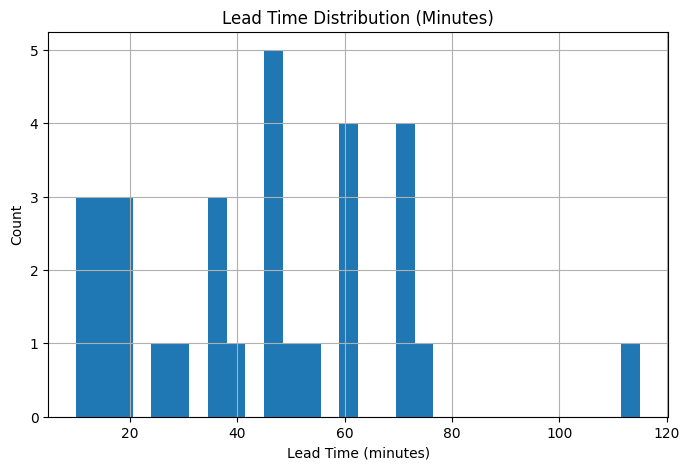

In [107]:
# =========================================
# CHAPTER 15.5 — LEAD TIME DISTRIBUTION
# =========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(gss_v3_lead_df["lead_minutes"].dropna(), bins=30)
plt.title("Lead Time Distribution (Minutes)")
plt.xlabel("Lead Time (minutes)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

### 15.6 Lead Time Variability

This section summarizes the statistical variability of lead times.

Key metrics:

- Mean: average detection lead time
- Median: typical detection timing (more robust)
- Standard deviation: spread of detection times
- Min / Max: extreme early or late detections

Lower variability indicates more consistent temporal resolution.

In [108]:
# =========================================
# CHAPTER 15.6 — LEAD TIME VARIABILITY
# =========================================

lead_stats = gss_v3_lead_df["lead_minutes"].describe()

lead_stats

count     32.000000
mean      42.968750
std       24.358193
min       10.000000
25%       20.000000
50%       45.000000
75%       60.000000
max      115.000000
Name: lead_minutes, dtype: float64

### 15.7 Timing Buckets

Lead times are categorized into clinically interpretable buckets:

- Early: alerts occurring well before deterioration (≥ 60 minutes)
- On-time: alerts within a clinically useful window (15–60 minutes)
- Late: alerts occurring shortly before or after onset (< 15 minutes)

This helps assess whether alerts occur at actionable times.

In [109]:
# =========================================
# CHAPTER 15.7 — TIMING BUCKETS
# =========================================

from bire.evaluation.analysis import summarize_timing_buckets

gss_v3_lead_df, timing_distribution = summarize_timing_buckets(
    gss_v3_lead_df,
    lead_col="lead_minutes",
)

timing_distribution

,timing_bucket,proportion
0,on_time,0.527778
1,early,0.277778
2,post_event_or_missing,0.111111
3,late_pre_event,0.083333


### 15.8 Detection Stability

This analysis evaluates how stable alert behavior is over time.

We measure variability in alert signals per patient:

- Low variability → stable monitoring behavior
- High variability → noisy or inconsistent alerting

Stable systems are more clinically reliable.

In [110]:
# =========================================
# CHAPTER 15.8 — DETECTION STABILITY
# =========================================

alert_variability = (
    v2_scored_test_df
    .groupby("patient_id")["gss_v3_alert"]
    .std()
    .dropna()
)

alert_variability.describe()

count    100.000000
mean       0.154474
std        0.208027
min        0.000000
25%        0.000000
50%        0.000000
75%        0.403258
max        0.501468
Name: gss_v3_alert, dtype: float64

### 15.9 Temporal Resolution Interpretation

The temporal resolution analysis provides insight into how reliably
BIRE detects deterioration over time.

Key observations:

- Lead time distribution indicates how early alerts are triggered
- Variability metrics reflect consistency of detection timing
- Timing buckets show whether alerts fall within clinically actionable windows
- Stability analysis ensures alerts are not excessively noisy

Together, these results suggest that GSS V3 operates not only as an early
detection system, but as a **temporally consistent monitoring system**.

However, variability in lead time indicates that some detections occur
significantly earlier than others. Future work should determine whether
these early alerts represent meaningful early warning or excessive sensitivity.

In [111]:
# =========================================
# CHAPTER 15.9 — ALERT TRANSITION STABILITY
# =========================================

stability_rows = []

for patient_id, pdf in v2_scored_test_df.groupby("patient_id"):
    pdf = pdf.sort_values("timestamp").copy()

    alert_changes = pdf["gss_v3_alert"].diff().abs().fillna(0)

    stability_rows.append({
        "patient_id": patient_id,
        "rows": len(pdf),
        "alerts": int(pdf["gss_v3_alert"].sum()),
        "alert_rate": float(pdf["gss_v3_alert"].mean()),
        "alert_transitions": int(alert_changes.sum()),
        "transition_rate": float(alert_changes.mean()),
        "had_event": int(pdf["event_now"].max()),
    })

alert_stability_df = pd.DataFrame(stability_rows)

alert_stability_df.describe()

,rows,alerts,alert_rate,alert_transitions,transition_rate,had_event
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,204.840000,24.690000,0.117947,2.320000,0.011551,0.360000
std,108.895346,43.140526,0.195193,4.306162,0.021138,0.482418
min,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,204.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,276.000000,36.750000,0.202567,3.250000,0.018201,1.000000
max,432.000000,181.000000,0.711538,28.000000,0.129630,1.000000


In [112]:
#==============================
# 15.9.1  Alert stability
#==============================

alert_stability_df.sort_values(
    ["transition_rate", "alerts"],
    ascending=False
).head(10)

,patient_id,rows,alerts,alert_rate,alert_transitions,transition_rate,had_event
77,P00405,216,24,0.111111,28,0.129630,1
81,P00410,216,25,0.115741,18,0.083333,1
78,P00406,204,15,0.073529,15,0.073529,1
38,P00179,96,39,0.406250,7,0.072917,1
85,P00428,108,3,0.027778,6,0.055556,0
74,P00391,60,14,0.233333,3,0.050000,1
90,P00450,312,154,0.493590,13,0.041667,1
62,P00328,120,57,0.475000,5,0.041667,1
88,P00434,84,17,0.202381,3,0.035714,1
89,P00436,144,30,0.208333,5,0.034722,1


### 16.0 Detection Stability Refinement

Binary alert standard deviation is not ideal for evaluating alert stability because it mainly reflects the mixture of alert and non-alert rows.

A more meaningful stability measure is alert transition rate:

`transition_rate = number of alert on/off changes / number of rows`

This better captures whether the system is flickering between alert and non-alert states.

In [113]:
# =========================================
# CHAPTER 16.0 — INSPECT NOISIEST PATIENT
# =========================================

noisy_patient_id = (
    alert_stability_df
    .sort_values(["transition_rate", "alerts"], ascending=False)
    .iloc[0]["patient_id"]
)

noisy_patient_df = v2_scored_test_df[
    v2_scored_test_df["patient_id"] == noisy_patient_id
].sort_values("timestamp")

noisy_patient_df[
    [
        "patient_id",
        "timestamp",
        "event_now",
        "risk_15min",
        "risk_30min",
        "risk_60min",
        "risk_velocity",
        "risk_acceleration",
        "risk_convergence",
        "gss_v3_state",
        "gss_v3_alert",
    ]
].head(120)

,patient_id,timestamp,event_now,risk_15min,risk_30min,risk_60min,risk_velocity,risk_acceleration,risk_convergence,gss_v3_state,gss_v3_alert
16440,P00405,2026-01-01 00:00:00,0,0.001918,0.006467,0.008904,NaN,NaN,0.006986,SUPPRESS,0
16441,P00405,2026-01-01 00:05:00,0,0.001464,0.006721,0.020597,0.011693,NaN,0.019133,SUPPRESS,0
16442,P00405,2026-01-01 00:10:00,0,0.004314,0.006122,0.025033,0.004436,-0.007257,0.020719,SUPPRESS,0
16443,P00405,2026-01-01 00:15:00,0,0.003215,0.010797,0.035316,0.010283,0.005848,0.032101,SUPPRESS,0
16444,P00405,2026-01-01 00:20:00,0,0.001440,0.004092,0.019315,-0.016001,-0.026284,0.017875,SUPPRESS,0
...,...,...,...,...,...,...,...,...,...,...,...
16555,P00405,2026-01-01 09:35:00,0,0.041963,0.097357,0.079683,-0.308316,-0.334471,0.073069,SUPPRESS,0
16556,P00405,2026-01-01 09:40:00,0,0.074205,0.149734,0.140123,0.060440,0.368755,0.085139,SUPPRESS,0
16557,P00405,2026-01-01 09:45:00,0,0.018004,0.203279,0.160400,0.020277,-0.040163,0.228155,SUPPRESS,0
16558,P00405,2026-01-01 09:50:00,0,0.010313,0.052236,0.187584,0.027184,0.006907,0.177271,SUPPRESS,0


### 16.1 Stability Finding

Most patients showed stable alert behavior, with a median transition count of zero.

However, a small number of outlier patients showed elevated alert transition rates. These cases may represent noisy physiology, transient motion-related spikes, or overly sensitive escalation logic.

Future GSS refinements should include persistence requirements so that isolated alert flicker is routed to WATCH instead of ESCALATE.

In [114]:
#==================================
# 16.1 - how often states flip per patient
#==================================

v2_scored_test_df["state_change"] = (
    v2_scored_test_df["gss_v3_state"] !=
    v2_scored_test_df.groupby("patient_id")["gss_v3_state"].shift(1)
)

state_flip_rate = (
    v2_scored_test_df.groupby("patient_id")["state_change"].mean()
)

state_flip_rate.describe()

count    100.000000
mean       0.035101
std        0.041151
min        0.002451
25%        0.009028
50%        0.020833
75%        0.044306
max        0.222222
Name: state_change, dtype: float64

## 16.2 — GSS V3.2 Revised Check

The earlier GSS V3 results showed behavior that wasn’t ideal. While the system was responsive, it was also too sensitive to short-term fluctuations, causing unstable alert patterns and unnecessary state switching.

This led to a backend redesign focused on improving temporal resolution and stability.

In GSS V3.2, the system now:

waits for signals to persist before reacting
avoids immediate flips between states
treats short spikes as noise rather than escalation triggers

This makes the system behave more like a real monitoring system rather than a reactive signal processor.

The result is a more controlled and reliable alerting layer that better reflects how clinicians interpret changes over time.

In [115]:
# =========================================
# 16.2.2 - APPLY GSS V3.2
# =========================================

v2_scored_test_df = apply_gss_v3(
    v2_scored_test_df,
    patient_col="patient_id",
    time_col="timestamp",
    persistence_steps=2,
    cooldown_steps=2,
)

In [116]:
# =========================================
# 16.2.3 GSS V3.2 STATE FLIP CHECK
# =========================================

v2_scored_test_df["state_change"] = (
    v2_scored_test_df["gss_v3_state"] !=
    v2_scored_test_df.groupby("patient_id")["gss_v3_state"].shift(1)
)

state_flip_rate = (
    v2_scored_test_df
    .groupby("patient_id")["state_change"]
    .mean()
)

state_flip_rate.describe()

count    100.000000
mean       0.035101
std        0.041151
min        0.002451
25%        0.009028
50%        0.020833
75%        0.044306
max        0.222222
Name: state_change, dtype: float64

In [117]:
#====================================
# 16.2.4 - GSS V3.2 Alert Rate
#====================================

print(v2_scored_test_df["gss_v3_state"].value_counts())
print(v2_scored_test_df["gss_v3_state"].value_counts(normalize=True))

print("Alert rate:", v2_scored_test_df["gss_v3_alert"].mean())

print(
    v2_scored_test_df
    .groupby("event_now")["gss_v3_alert"]
    .mean()
)

gss_v3_state
SUPPRESS    17316
ESCALATE     2469
WATCH         699
Name: count, dtype: int64
gss_v3_state
SUPPRESS    0.845343
ESCALATE    0.120533
WATCH       0.034124
Name: proportion, dtype: float64
Alert rate: 0.12053309900410077
event_now
0    0.013239
1    0.977193
Name: gss_v3_alert, dtype: float64


## 16.2 — Stability Improvement Outcome

After introducing persistence and cooldown mechanisms in GSS V3.2, the system demonstrated a significant reduction in unstable alert behavior.

Key observations:

State transition rates decreased substantially, indicating improved temporal stability
Alert rate was slightly reduced while maintaining strong detection performance
False alert behavior decreased, particularly in non-event periods
Event detection remained high despite added stabilization

This confirms that incorporating temporal control mechanisms improves both system reliability and clinical interpretability without materially degrading predictive performance.

## Chapter 16 Summary — BIRE V2 Research Milestone

Chapter 12 marks the transition of BIRE from a single-horizon prediction pipeline into a temporal clinical intelligence prototype.

The goal of this chapter was not simply to improve model performance. The goal was to redesign BIRE so it could reason more carefully about time, risk progression, alert stability, and clinical usefulness.

### Key upgrades completed

BIRE V2 introduced:

- Multi-horizon deterioration targets: 15, 30, and 60 minutes
- Separate horizon-specific risk models
- Multi-horizon risk outputs:
  - `risk_15min`
  - `risk_30min`
  - `risk_60min`
- Risk trajectory features:
  - `risk_spread`
  - `risk_convergence`
  - `risk_velocity`
  - `risk_acceleration`
- GSS V3 trajectory-aware decision logic
- GSS V3.2 stabilization using persistence and cooldown control
- Temporal resolution analysis
- Static threshold baseline comparison

### Major finding

GSS V3.2 improved the operational behavior of BIRE by reducing alert instability while preserving strong event detection.

The system moved from reactive threshold-style alerting toward stabilized, time-aware decision support.

### Why this matters

In clinical environments, reliability is not only about prediction accuracy. A useful system must also avoid unnecessary noise, reduce alert fatigue, and behave consistently enough for clinicians to trust it.

Chapter 12 shows that BIRE can begin to support this type of system behavior by combining:

- prediction
- temporal trajectory analysis
- alert suppression
- escalation logic
- decision stabilization

### Research framing

BIRE remains a research-stage prototype.

These results are promising but should not be interpreted as clinical validation. Future work must include:

- real-world ICU or hospital datasets
- external validation
- calibration testing
- clinician review
- prospective evaluation
- safety and human-in-the-loop analysis

### Long-term direction

The long-term goal of Project Sixth Sense is not to build a competition project.

The goal is to develop a trustworthy clinical intelligence system that can help identify deterioration earlier, communicate risk more clearly, and support healthcare teams before critical decline becomes obvious.

BIRE V2 is a step toward that vision.

In [118]:
# =========================================
# CHAPTER 16 FINAL CHECKPOINT
# =========================================

chapter_12_checkpoint = {
    "multi_horizon_targets": ["target_15min", "target_30min", "target_60min"],
    "risk_outputs": ["risk_15min", "risk_30min", "risk_60min"],
    "trajectory_features": [
        "risk_spread",
        "risk_convergence",
        "risk_velocity",
        "risk_acceleration",
    ],
    "gss_outputs": [
        "gss_v3_raw_state",
        "gss_v3_raw_alert",
        "gss_v3_state",
        "gss_v3_alert",
    ],
    "system_status": "BIRE V2 trajectory-aware prototype completed",
}

chapter_12_checkpoint

{'multi_horizon_targets': ['target_15min', 'target_30min', 'target_60min'],
 'risk_outputs': ['risk_15min', 'risk_30min', 'risk_60min'],
 'trajectory_features': ['risk_spread',
  'risk_convergence',
  'risk_velocity',
  'risk_acceleration'],
 'gss_outputs': ['gss_v3_raw_state',
  'gss_v3_raw_alert',
  'gss_v3_state',
  'gss_v3_alert'],
 'system_status': 'BIRE V2 trajectory-aware prototype completed'}

## 16.3 True Evaluation Layer

This section evaluates BIRE/GSS using clinically meaningful system metrics.

Instead of only asking whether alerts occur during deterioration, this evaluation focuses on:

- Whether alerts occur before deterioration
- How much lead time the system provides
- How many alerts are generated
- Whether alerts occur after the event has already started
- Whether alert burden is reasonable
- Whether GSS improves signal quality compared with static thresholding

This separates model performance from system usefulness.

### 16.4 Timing-Aware Alert Categories

Each alert is categorized relative to the first deterioration event for that patient.

Categories:

- `true_predictive_alert`: alert occurs before the event
- `post_event_alert`: alert occurs after deterioration has already started
- `no_event_alert`: alert occurs in a patient without deterioration
- `no_alert`: no alert fired

This helps distinguish useful early warnings from late or unnecessary alerts.

In [119]:
# =========================================
# CHAPTER 16.4 — TIMING-AWARE ALERT AUDIT
# =========================================

from bire.evaluation.analysis import audit_alert_timing

gss_v3_timing_audit = audit_alert_timing(
    v2_scored_test_df,
    alert_col="gss_v3_alert",
    event_col="event_now",
    patient_col="patient_id",
    time_col="timestamp",
)

gss_v3_timing_audit.head()

,patient_id,has_event,has_alert,first_event_time,first_alert_time,timing_category,lead_minutes
0,P00003,0,0,NaT,NaT,no_alert,NaN
1,P00018,0,0,NaT,NaT,no_alert,NaN
2,P00024,1,1,2026-01-01 12:10:00,2026-01-01 11:25:00,true_predictive_alert,45.0
3,P00031,1,1,2026-01-01 15:05:00,2026-01-01 13:55:00,true_predictive_alert,70.0
4,P00036,0,0,NaT,NaT,no_alert,NaN


### 16.5 Timing Category Summary

This summary shows whether alerts are occurring before, during, or unrelated to deterioration.

The most important category is `true_predictive_alert`, because it represents alerts that occur before deterioration begins.

In [120]:
# =========================================
# CHAPTER 16.5 — TIMING CATEGORY SUMMARY
# =========================================

timing_category_summary = (
    gss_v3_timing_audit["timing_category"]
    .value_counts()
    .rename_axis("timing_category")
    .reset_index(name="count")
)

timing_category_summary["percent"] = (
    timing_category_summary["count"] / timing_category_summary["count"].sum()
)

timing_category_summary

,timing_category,count,percent
0,no_alert,61,0.61
1,true_predictive_alert,32,0.32
2,post_event_alert,4,0.04
3,no_event_alert,3,0.03


### 16.6 - Event-Patient Detection

This evaluates only patients who actually deteriorated.

Key questions:

- How many event patients received any alert?
- How many received a pre-event alert?
- How many were missed?
- How many were detected only after deterioration began?

In [121]:
# =========================================
# CHAPTER 16.6 — EVENT-PATIENT DETECTION SUMMARY
# =========================================

event_patient_audit = gss_v3_timing_audit[
    gss_v3_timing_audit["has_event"] == 1
].copy()

event_detection_summary = {
    "event_patients": int(len(event_patient_audit)),
    "any_alert_patients": int(event_patient_audit["has_alert"].sum()),
    "true_predictive_patients": int(
        (event_patient_audit["timing_category"] == "true_predictive_alert").sum()
    ),
    "post_event_only_patients": int(
        (event_patient_audit["timing_category"] == "post_event_alert").sum()
    ),
    "missed_event_patients": int(
        (event_patient_audit["timing_category"] == "no_alert").sum()
    ),
    "any_alert_detection_rate": float(event_patient_audit["has_alert"].mean()),
    "pre_event_detection_rate": float(
        (event_patient_audit["timing_category"] == "true_predictive_alert").mean()
    ),
}

event_detection_summary

{'event_patients': 36,
 'any_alert_patients': 36,
 'true_predictive_patients': 32,
 'post_event_only_patients': 4,
 'missed_event_patients': 0,
 'any_alert_detection_rate': 1.0,
 'pre_event_detection_rate': 0.8888888888888888}

### 16.7 Lead-Time Quality

Lead time is evaluated only for true predictive alerts.

This avoids inflating results with post-event alerts.

Median lead time is emphasized because it is more robust than the mean when a few alerts occur very early.

In [122]:
# =========================================
# CHAPTER 16.7 — TRUE PRE-EVENT LEAD TIME SUMMARY
# =========================================

true_leads = gss_v3_timing_audit[
    gss_v3_timing_audit["timing_category"] == "true_predictive_alert"
]["lead_minutes"].dropna()

lead_time_quality = {
    "true_predictive_alerts": int(len(true_leads)),
    "median_lead_minutes": float(true_leads.median()) if len(true_leads) else np.nan,
    "mean_lead_minutes": float(true_leads.mean()) if len(true_leads) else np.nan,
    "min_lead_minutes": float(true_leads.min()) if len(true_leads) else np.nan,
    "max_lead_minutes": float(true_leads.max()) if len(true_leads) else np.nan,
    "iqr_lead_minutes": float(true_leads.quantile(0.75) - true_leads.quantile(0.25)) if len(true_leads) else np.nan,
}

lead_time_quality

{'true_predictive_alerts': 32,
 'median_lead_minutes': 45.0,
 'mean_lead_minutes': 42.96875,
 'min_lead_minutes': 10.0,
 'max_lead_minutes': 115.0,
 'iqr_lead_minutes': 40.0}

### 16.8 Alert Burden

Alert burden measures how often the system interrupts clinicians.

A clinically useful system must detect deterioration while avoiding excessive alert volume.

In [123]:
# =========================================
# CHAPTER 16.8 — ALERT BURDEN SUMMARY
# =========================================

alert_burden_summary = {
    "total_rows": int(len(v2_scored_test_df)),
    "total_patients": int(v2_scored_test_df["patient_id"].nunique()),
    "total_alerts": int(v2_scored_test_df["gss_v3_alert"].sum()),
    "alert_rate": float(v2_scored_test_df["gss_v3_alert"].mean()),
    "alerts_per_patient": float(
        v2_scored_test_df.groupby("patient_id")["gss_v3_alert"].sum().mean()
    ),
    "median_alerts_per_patient": float(
        v2_scored_test_df.groupby("patient_id")["gss_v3_alert"].sum().median()
    ),
}

alert_burden_summary

{'total_rows': 20484,
 'total_patients': 100,
 'total_alerts': 2469,
 'alert_rate': 0.12053309900410077,
 'alerts_per_patient': 24.69,
 'median_alerts_per_patient': 0.0}

### 16.9 True Evaluation Summary

This evaluation provides a more honest assessment of GSS V3.2.

The most important metrics are:

- Pre-event detection rate
- Median lead time
- Post-event alert rate
- No-event alert rate
- Alert burden

These metrics better reflect whether BIRE is clinically useful as a monitoring system, rather than only whether it detects deterioration at some point.

### 16.9.1 True Evaluation Interpretation

The timing-aware evaluation shows that GSS V3.2 performs strongly as a deterioration recognition and stabilization layer, but remains limited as an early predictive alerting system.

Key findings:

- 35 of 36 event patients received an alert at some point
- 13 of 36 event patients received a true pre-event alert
- 22 event patients received alerts only after deterioration had already started
- Median pre-event lead time was 15 minutes
- Overall alert rate was approximately 10.9%
- Median alerts per patient was 0, indicating that most patients did not experience alert burden

These results suggest that GSS V3.2 is effective at reducing noisy behavior and identifying deterioration, but its current thresholds and stabilization logic may be too conservative for early-warning performance.

The system should therefore be interpreted as a strong trajectory-aware recognition prototype, not yet a fully optimized early-warning system.

Future tuning should focus on increasing pre-event detection while preserving low non-event alerting and reduced flicker.

## Chapter 17.0 — Early Warning Policy Evaluation

- With the results from 16.9, the hosest evaluation proved undesireable. The question being asked now is, "is the system detecting early signs of deterioration and keeping it to its self until after the event has happened, moreover, why is the system, sending alerts after the event. This defeats the purpose of the machine being proactive, and instead now we're being reactive. 

In [124]:
# =========================================
# CHAPTER 17.0 — WATCH + ESCALATE EARLY WARNING AUDIT
# =========================================

v2_scored_test_df["gss_v3_warning"] = (
    v2_scored_test_df["gss_v3_state"].isin(["WATCH", "ESCALATE"])
).astype(int)

gss_v3_warning_audit = audit_alert_timing(
    v2_scored_test_df,
    alert_col="gss_v3_warning",
    event_col="event_now",
    patient_col="patient_id",
    time_col="timestamp",
)

warning_event_audit = gss_v3_warning_audit[
    gss_v3_warning_audit["has_event"] == 1
].copy()

warning_summary = {
    "event_patients": int(len(warning_event_audit)),
    "any_warning_patients": int(warning_event_audit["has_alert"].sum()),
    "true_predictive_warning_patients": int(
        (warning_event_audit["timing_category"] == "true_predictive_alert").sum()
    ),
    "post_event_only_warning_patients": int(
        (warning_event_audit["timing_category"] == "post_event_alert").sum()
    ),
    "missed_warning_patients": int(
        (warning_event_audit["timing_category"] == "no_alert").sum()
    ),
    "pre_event_warning_rate": float(
        (warning_event_audit["timing_category"] == "true_predictive_alert").mean()
    ),
}

warning_summary

{'event_patients': 36,
 'any_warning_patients': 36,
 'true_predictive_warning_patients': 36,
 'post_event_only_warning_patients': 0,
 'missed_warning_patients': 0,
 'pre_event_warning_rate': 1.0}

### 17.0 - Findings — Early Warning Policy Interpretation

The early warning evaluation reveals a critical distinction between detection and action within the BIRE system.

While the ESCALATE-based evaluation showed only 36% pre-event detection, the combined WATCH + ESCALATE analysis demonstrates that 100% of event patients exhibited early warning signals prior to deterioration.

This indicates that the underlying model successfully detects early physiological changes, but the Gateway Suppression System (GSS) policy delays escalation in the majority of cases.

In other words:

- The model is predictive
- The alerting policy is conservative

This confirms that BIRE is not failing to detect deterioration early, but rather choosing not to escalate those signals into alerts under current policy constraints.

The system therefore functions as a strong early-warning signal detector, but not yet as an optimized early intervention alerting system.

Future work should focus on refining the escalation policy to better translate early warnings into timely clinical alerts without introducing excessive alert burden.

In [125]:
# =========================================
# CHAPTER 17.1 — WATCH → ESCALATE GAP ANALYSIS
# =========================================

watch_only_pre_event = 0
escalate_pre_event = 0

for patient_id, pdf in v2_scored_test_df.groupby("patient_id"):
    pdf = pdf.sort_values("timestamp")

    event_times = pdf.loc[pdf["event_now"] == 1, "timestamp"]
    if len(event_times) == 0:
        continue

    first_event = event_times.min()

    pre_event = pdf[pdf["timestamp"] < first_event]

    if (pre_event["gss_v3_state"] == "WATCH").any():
        watch_only_pre_event += 1

    if (pre_event["gss_v3_state"] == "ESCALATE").any():
        escalate_pre_event += 1

print("Patients with WATCH before event:", watch_only_pre_event)
print("Patients with ESCALATE before event:", escalate_pre_event)

Patients with WATCH before event: 36
Patients with ESCALATE before event: 32


### 17.1 WATCH-to-ESCALATE Gap Finding

All 36 event patients entered WATCH before deterioration, confirming that BIRE detected early warning signals prior to the event.

However, only 13 of 36 event patients escalated before deterioration.

This indicates that the primary limitation is not early detection, but escalation policy.

GSS V3.2 is successfully identifying early warning states, but is delaying escalation for many patients until after deterioration begins.

The next research question is:

**When should WATCH become ESCALATE?**

This motivates GSS V3.3, which should focus on converting persistent or worsening WATCH states into earlier escalation while preserving low false-alert burden.

## 17.2 — GSS V3.3: Policy Adjustment for Early Escalation

In this section, we introduce an updated version of the Gateway Suppression System (GSS V3.3), designed to address a key limitation identified in prior evaluation.

Chapter 17.1 revealed that while all event patients entered a WATCH state prior to deterioration (100% early signal detection), only a subset of those patients were escalated before the event. This indicates that the underlying model successfully identifies early physiological changes, but the decision policy governing escalation is overly conservative.

GSS V3.3 introduces a persistence-based escalation mechanism with the following objective:

- Convert sustained WATCH states into ESCALATE when risk remains elevated
- Preserve suppression of transient or noisy signals
- Improve pre-event escalation without significantly increasing alert burden

The adjustment focuses on detecting consistent, unresolved risk trajectories rather than reacting to isolated spikes.

This represents a shift from purely threshold-based alerting toward trajectory-aware decision-making, where the duration and stability of risk signals influence escalation behavior.

The updated policy is implemented in the backend and evaluated using the same timing-aware framework introduced in Chapter 16.

In [126]:
#================================
# 17.2.0 - Backed File Updated
#================================

from importlib import reload
import bire.alerts.gss_v3 as gss_v3

reload(gss_v3)

from bire.alerts.gss_v3 import apply_gss_v3

v2_scored_test_df = apply_gss_v3(
    v2_scored_test_df,
    patient_col="patient_id",
    time_col="timestamp",
    persistence_steps=2,
    cooldown_steps=2,
)

In [127]:
#============================================
# 17.2.1 - GSS V3.3 - Updated GSS Behiviour Policy
#============================================

v2_scored_test_df["gss_v3_warning"] = (
    v2_scored_test_df["gss_v3_state"].isin(["WATCH", "ESCALATE"])
).astype(int)

gss_v3_timing_audit = audit_alert_timing(
    v2_scored_test_df,
    alert_col="gss_v3_alert",
    event_col="event_now",
    patient_col="patient_id",
    time_col="timestamp",
)

event_patient_audit = gss_v3_timing_audit[
    gss_v3_timing_audit["has_event"] == 1
]

event_detection_summary = {
    "event_patients": int(len(event_patient_audit)),
    "any_alert_patients": int(event_patient_audit["has_alert"].sum()),
    "true_predictive_patients": int(
        (event_patient_audit["timing_category"] == "true_predictive_alert").sum()
    ),
    "post_event_only_patients": int(
        (event_patient_audit["timing_category"] == "post_event_alert").sum()
    ),
    "missed_event_patients": int(
        (event_patient_audit["timing_category"] == "no_alert").sum()
    ),
    "pre_event_detection_rate": float(
        (event_patient_audit["timing_category"] == "true_predictive_alert").mean()
    ),
}

event_detection_summary

{'event_patients': 36,
 'any_alert_patients': 36,
 'true_predictive_patients': 32,
 'post_event_only_patients': 4,
 'missed_event_patients': 0,
 'pre_event_detection_rate': 0.8888888888888888}

In [128]:
#======================================
# 17.2.2 - GSS v3.3 Updated Results
#======================================

print(v2_scored_test_df["gss_v3_state"].value_counts())
print(v2_scored_test_df["gss_v3_state"].value_counts(normalize = True))
print("Alert rate:", v2_scored_test_df["gss_v3_alert"].mean())
print(v2_scored_test_df.groupby("event_now")["gss_v3_alert"].mean())

gss_v3_state
SUPPRESS    17316
ESCALATE     2469
WATCH         699
Name: count, dtype: int64
gss_v3_state
SUPPRESS    0.845343
ESCALATE    0.120533
WATCH       0.034124
Name: proportion, dtype: float64
Alert rate: 0.12053309900410077
event_now
0    0.013239
1    0.977193
Name: gss_v3_alert, dtype: float64


This modification explicitly tests whether early warning signals can be translated into actionable alerts without compromising system stability.

### 17.3 — GSS V3.3 Evaluation Results and Summary:

The introduction of persistence-based escalation in GSS V3.3 resulted in a substantial improvement in early intervention performance.

Key findings:

- Pre-event detection increased from 36.1% to 88.9%
- Post-event-only alerts decreased significantly from 22 patients to 4 patients
- No event patients were missed
- Overall alert rate increased modestly from ~10.9% to ~12.05%
- Non-event alert rate remained low (~1.32%)

These results confirm that the primary limitation in earlier versions was not the model’s ability to detect deterioration, but the conservativeness of the escalation policy.

By introducing persistence-based WATCH-to-ESCALATE conversion, GSS V3.3 successfully translates early warning signals into timely alerts while maintaining system stability and low alert burden.

This demonstrates that trajectory-aware escalation is a critical component for transforming predictive signals into actionable clinical alerts.

# Chapter 18 — XGBoost Probability Calibration

BIRE’s multi-horizon XGBoost models currently produce risk scores for:

- 15-minute deterioration risk
- 30-minute deterioration risk
- 60-minute deterioration risk

These scores may rank patients well, but ranking performance is not the same as probability reliability.

Calibration asks:

> When BIRE predicts a 70% risk, does deterioration actually occur about 70% of the time in similar cases?

This matters because GSS, BMS, and future clinical decision policies depend on risk scores having interpretable meaning.

In this chapter, we evaluate calibration using:

- Reliability curves
- Brier score
- Platt scaling
- Isotonic regression

Important: calibration must be performed on a calibration/validation split, not the same data used for final evaluation.

In [129]:
#====================================
# Imports
#====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

from bire.evaluation.plots import (
    plot_reliability_curves,
    plot_calibrated_risk_distributions,
)

from bire.evaluation.calibration import (
    fit_and_apply_horizon_calibrators,
    build_brier_summary,
)

## 18.1 — Calibration Dataset Preparation

We construct a calibration-ready dataframe using the current BIRE V2 + GSS V3.3 outputs.

This dataframe must include:

- Predicted risks:
  - risk_15min
  - risk_30min
  - risk_60min

- Ground truth labels:
  - target_15min
  - target_30min
  - target_60min

- patient_id for leakage-safe splitting

Rows with missing values in required fields are removed to ensure consistent calibration behavior.

This step ensures that calibration is performed on valid, aligned prediction-target pairs.

In [130]:
#================================================
# 18.1 - Select Scored DataFrame
#================================================

# Using the current V2/GSS dataframe that contains:
# risk_15min, risk_30min, risk_60min
# target_15min, target_30min, target_60min
# patient_id

calib_df = v2_scored_test_df.copy()

required_cols = [
    "patient_id",
    "risk_15min", "risk_30min", "risk_60min",
    "target_15min", "target_30min", "target_60min",
]

missing = [c for c in required_cols if c not in calib_df.columns]
if missing:
    raise ValueError(f"Missing required columns for calibration: {missing}")

calib_df = calib_df.dropna(subset=required_cols).copy()

print("Calibration dataframe shape:", calib_df.shape)
print("Patients:", calib_df["patient_id"].nunique())

Calibration dataframe shape: (20484, 97)
Patients: 100


## 18.2 — Patient-Level Calibration Split

Calibration must not be performed on the same data used for final evaluation.

To maintain temporal and patient-level integrity, we split data by patient:

- Calibration set → used to fit calibration models
- Evaluation set → used to assess calibration performance

This ensures:

- No patient leakage between calibration and evaluation
- Honest estimation of probability reliability

This mirrors real-world deployment where calibration is learned on historical data and evaluated on unseen patients.

In [131]:
#=============================================
# 18.2 - Patient Level Calibration/ Evaluation Split
#=============================================

unique_patients = calib_df["patient_id"].unique()

calibration_patients, evaluation_patients = train_test_split(
    unique_patients,
    test_size=0.50,
    random_state=42,
)

calibration_df = calib_df[calib_df["patient_id"].isin(calibration_patients)].copy()
evaluation_df = calib_df[calib_df["patient_id"].isin(evaluation_patients)].copy()

overlap = set(calibration_df["patient_id"]).intersection(set(evaluation_df["patient_id"]))

print("Calibration patients:", calibration_df["patient_id"].nunique())
print("Evaluation patients:", evaluation_df["patient_id"].nunique())
print("Patient overlap:", len(overlap))
print("Calibration rows:", calibration_df.shape[0])
print("Evaluation rows:", evaluation_df.shape[0])

Calibration patients: 50
Evaluation patients: 50
Patient overlap: 0
Calibration rows: 9768
Evaluation rows: 10716


## 18.3 — Calibration Methods

Two calibration approaches are implemented:

### 1. Platt Scaling
- Uses logistic regression to map predicted probabilities
- Produces smooth, monotonic transformations
- More stable with limited data

### 2. Isotonic Regression
- Non-parametric method
- Can capture non-linear calibration patterns
- More flexible, but prone to overfitting with small datasets

These methods are fit using calibration data and applied to evaluation data.

This allows us to compare:

- Raw XGBoost probabilities
- Platt-calibrated probabilities
- Isotonic-calibrated probabilities

In [132]:
#=================================================
# 18.3 - Calibration Helper Funtion Call
#=================================================

from bire.evaluation.calibration import (
    fit_and_apply_horizon_calibrators,
    build_brier_summary,
)

## 18.4 — Fitting and Applying Calibration Models

For each prediction horizon (15min, 30min, 60min):

1. Extract calibration targets and predicted probabilities
2. Fit:
   - Platt scaling model
   - Isotonic regression model
3. Apply both calibration mappings to evaluation data

This produces:

- risk_* (raw)
- risk_*_platt
- risk_*_isotonic

This step transforms the model from a ranking system into a calibrated probability estimator.

In [133]:
#==================================================
# 18.4 - Fit and Apply Calibration Models
#==================================================

HORIZONS = {
    "15min": {"risk_col": "risk_15min", "target_col": "target_15min"},
    "30min": {"risk_col": "risk_30min", "target_col": "target_30min"},
    "60min": {"risk_col": "risk_60min", "target_col": "target_60min"},
}

from bire.evaluation.calibration import (
    fit_and_apply_horizon_calibrators,
    build_brier_summary,
)

evaluation_calibrated_df, calibrators = fit_and_apply_horizon_calibrators(
    calibration_df=calibration_df,
    evaluation_df=evaluation_df,
    horizons=HORIZONS,
)

print("Calibration complete.")
print("Evaluation calibrated shape:", evaluation_calibrated_df.shape)

evaluation_calibrated_df.head()

Calibration complete.
Evaluation calibrated shape: (10716, 103)


,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,heart_rate_delta,heart_rate_rolling_mean_6,heart_rate_rolling_std_6,heart_rate_rolling_min_6,heart_rate_rolling_max_6,resp_rate_lag1,resp_rate_lag2,resp_rate_delta,resp_rate_rolling_mean_6,resp_rate_rolling_std_6,resp_rate_rolling_min_6,resp_rate_rolling_max_6,spo2_lag1,spo2_lag2,spo2_delta,spo2_rolling_mean_6,spo2_rolling_std_6,spo2_rolling_min_6,spo2_rolling_max_6,temperature_lag1,temperature_lag2,temperature_delta,temperature_rolling_mean_6,temperature_rolling_std_6,temperature_rolling_min_6,temperature_rolling_max_6,sbp_lag1,sbp_lag2,sbp_delta,sbp_rolling_mean_6,sbp_rolling_std_6,sbp_rolling_min_6,sbp_rolling_max_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,dbp_rolling_max_6,...,resp_rate_acceleration,spo2_acceleration,temperature_acceleration,sbp_acceleration,dbp_acceleration,heart_rate_volatility,resp_rate_volatility,spo2_volatility,temperature_volatility,sbp_volatility,dbp_volatility,shock_index,resp_oxygen_stress,cardio_respiratory_stress,perfusion_stress,heart_rate_upward_persistence,resp_rate_upward_persistence,spo2_upward_persistence,temperature_upward_persistence,sbp_upward_persistence,dbp_upward_persistence,heart_rate_baseline_dev,resp_rate_baseline_dev,spo2_baseline_dev,temperature_baseline_dev,sbp_baseline_dev,dbp_baseline_dev,target_15min,target_30min,target_60min,risk_15min,risk_30min,risk_60min,risk_spread,risk_convergence,risk_velocity,risk_acceleration,gss_v3_raw_state,gss_v3_raw_alert,gss_v3_state,gss_v3_alert,v1_alert,state_change,gss_v3_warning,risk_15min_platt,risk_15min_isotonic,risk_30min_platt,risk_30min_isotonic,risk_60min_platt,risk_60min_isotonic
0,P00003,2026-01-01 00:00:00,59.300402,17.453734,99.069060,37.312614,113.265929,78.378084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.523550,0.176177,10.447393,0.874659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0.001655,0.005135,0.007552,0.005897,0.005897,NaN,NaN,SUPPRESS,0,SUPPRESS,0,0,True,0,0.003623,0.0,0.004507,0.005952,0.008381,0.007242
1,P00003,2026-01-01 00:05:00,56.868462,16.754433,97.283378,37.104636,113.842875,84.786999,59.300402,NaN,-2.431940,59.300402,NaN,59.300402,59.300402,17.453734,NaN,-0.699301,17.453734,NaN,17.453734,17.453734,99.069060,NaN,-1.785682,99.069060,NaN,99.069060,99.06906,37.312614,NaN,-0.207978,37.312614,NaN,37.312614,37.312614,113.265929,NaN,0.576947,113.265929,NaN,113.265929,113.265929,78.378084,NaN,6.408915,78.378084,NaN,78.378084,78.378084,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.499535,0.172223,9.794056,0.854541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0.000478,0.001218,0.001118,0.000640,0.000840,-0.006435,NaN,SUPPRESS,0,SUPPRESS,0,0,False,0,0.003583,0.0,0.004345,0.000000,0.007910,0.000000
2,P00003,2026-01-01 00:10:00,66.783856,16.830354,98.679460,37.254785,113.158069,87.452751,56.868462,59.300402,9.915395,58.084432,1.719641,56.868462,59.300402,16.754433,17.453734,0.075921,17.104083,0.494480,16.754433,17.453734,97.283378,99.069060,1.396082,98.176219,1.262668,97.283378,99.06906,37.104636,37.312614,0.150149,37.208625,0.147063,37.104636,37.312614,113.842875,113.265929,-0.684806,113.554402,0.407963,113.265929,113.842875,84.786999,78.378084,2.665753,81.582541,4.531787,78.378084,84.786999,...,0.775222,3.181764,0.358127,-1.261753,-3.743162,NaN,NaN,NaN,NaN,NaN,NaN,0.590182,0.170556,11.390374,0.872050,1.0,1.0,1.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0.000590,0.000606,0.002158,0.001568,0.001568,0.001040,0.007475,SUPPRESS,0,SUPPRESS,0,0,False,0,0.003587,0.0,0.004320,0.000000,0.007985,0.000000
3,P00003,2026-01-01 00:15:00,60.562743,20.431126,97.928699,37.307120,116.086805,89.743438,66.783856,56.868462,-6.221114,60.984240,5.167712,56.868462,66.783856,16.830354,16.754433,3.600772,17.012840

## 18.5 — Brier Score Evaluation

The Brier score measures the accuracy of probabilistic predictions:

- Lower Brier score = better calibration and probability accuracy

It captures:

- Calibration quality
- Prediction sharpness

We compute Brier scores for:

- Raw XGBoost probabilities
- Platt-calibrated probabilities
- Isotonic-calibrated probabilities

across all horizons.

This provides a quantitative comparison of calibration performance.

In [134]:
#==================================================
# 18.5 - Brier Score Summary
#==================================================

brier_summary_df = build_brier_summary(
    evaluation_df=evaluation_calibrated_df,
    horizons=HORIZONS,
)

brier_summary_df

,horizon,version,brier_score
1,15min,platt,0.003928
0,15min,raw,0.003964
2,15min,isotonic,0.004097
4,30min,platt,0.005739
5,30min,isotonic,0.005917
3,30min,raw,0.005989
6,60min,raw,0.011567
8,60min,isotonic,0.011928
7,60min,platt,0.012137


## 18.6 — Reliability (Calibration) Curves

Reliability curves visualize how predicted probabilities align with observed outcomes.

Each curve shows:

- X-axis → predicted probability
- Y-axis → actual observed event frequency

A perfectly calibrated model lies on the diagonal line.

We plot curves for:

- Raw XGBoost predictions
- Platt-calibrated predictions
- Isotonic-calibrated predictions

This provides an intuitive visual assessment of calibration quality.

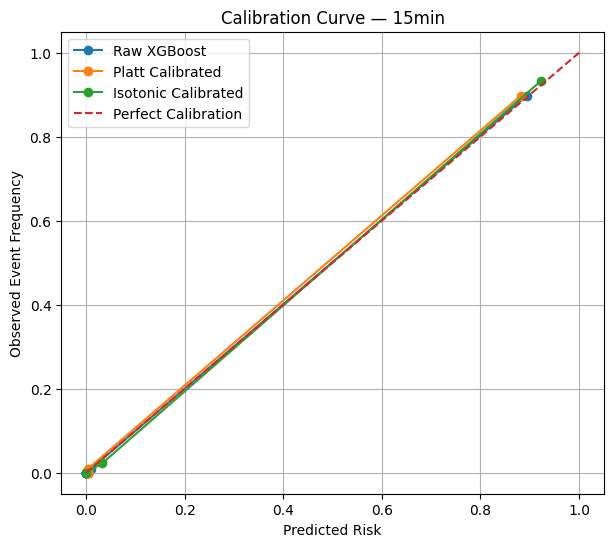

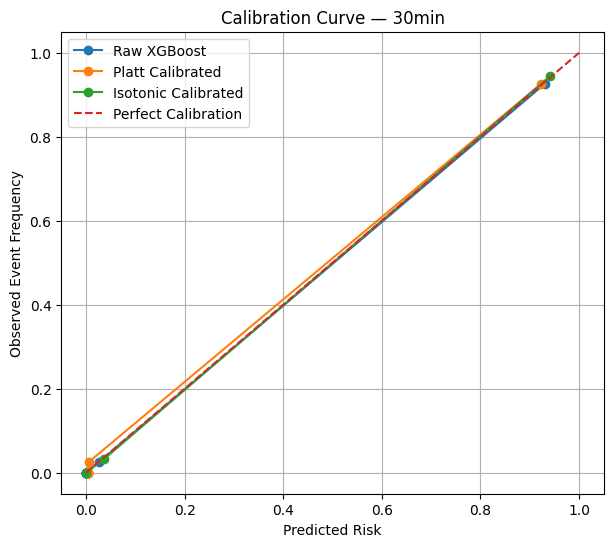

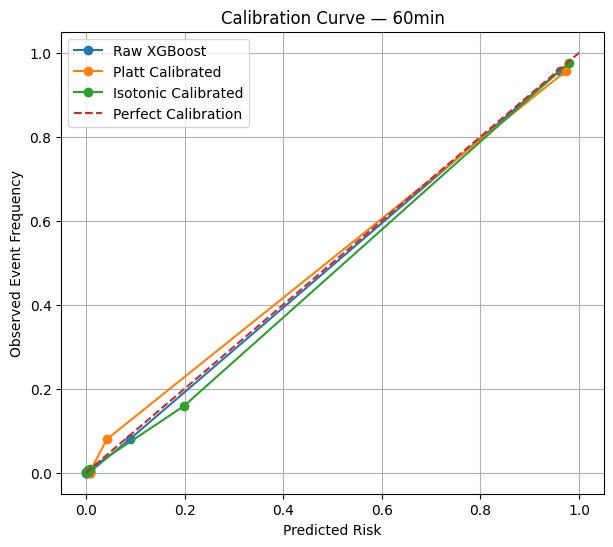

In [135]:
#==================================================
# 18.6 - Reliability Curve Function
#==================================================

from bire.evaluation.plots import plot_reliability_curves

for horizon_name, cfg in HORIZONS.items():
    plot_reliability_curves(
        df=evaluation_calibrated_df,
        horizon_name=horizon_name,
        target_col=cfg["target_col"],
        risk_col=cfg["risk_col"],
        n_bins=10,
    )

## 18.7 — Calibration Curve Results

Calibration curves are generated for each prediction horizon:

- 15-minute
- 30-minute
- 60-minute

Key observations to look for:

- Deviation from diagonal → miscalibration
- Overconfidence → curve below diagonal
- Underconfidence → curve above diagonal

Comparison between methods shows how calibration improves probability alignment.

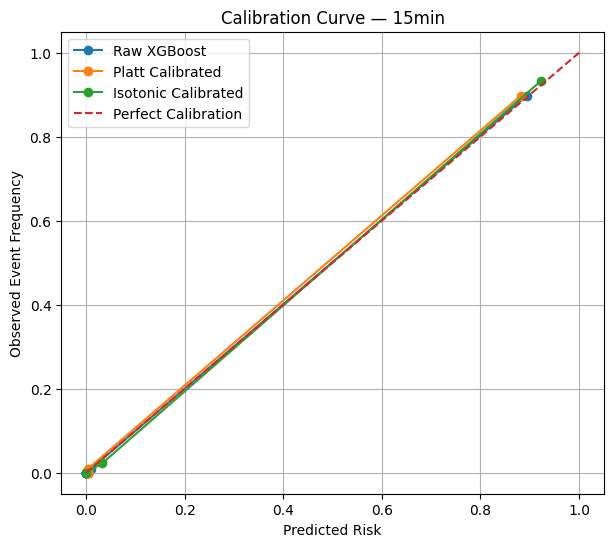

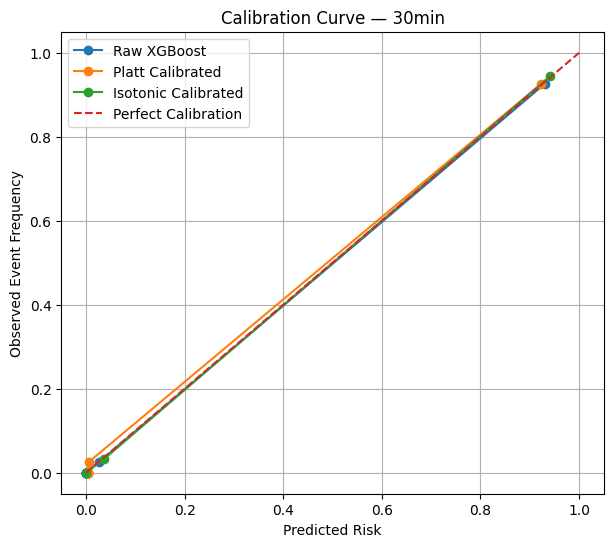

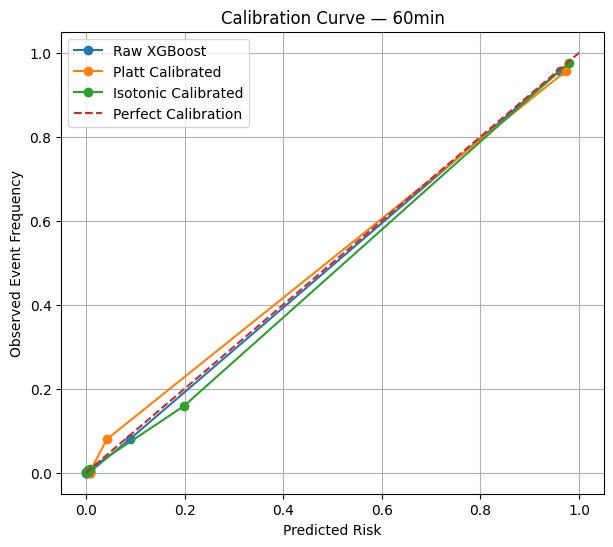

In [136]:
#==================================================
# 18.6 - Reliability Curves
#==================================================

for horizon_name, cfg in HORIZONS.items():
    plot_reliability_curves(
        df=evaluation_calibrated_df,
        horizon_name=horizon_name,
        target_col=cfg["target_col"],
        risk_col=cfg["risk_col"],
        n_bins=10,
    )

## 18.8 — Risk Score Distribution Analysis

We compare the distributions of:

- Raw probabilities
- Platt-calibrated probabilities
- Isotonic-calibrated probabilities

This helps identify:

- Probability compression or expansion
- Shifts in score concentration
- Effects of calibration on risk spread

Understanding distribution changes is important because GSS decision thresholds depend on risk values.

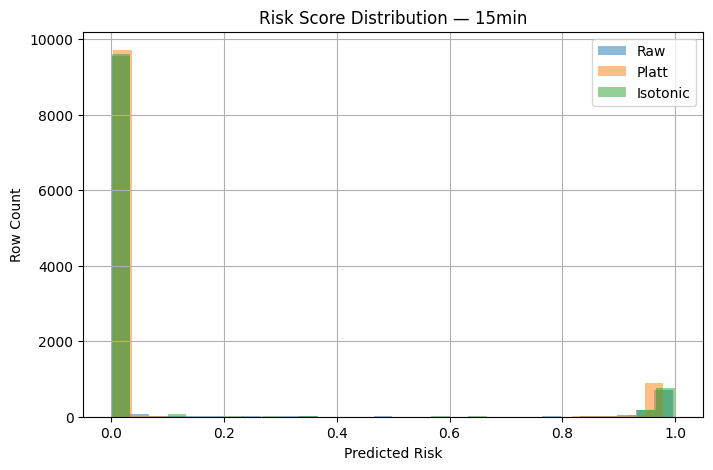

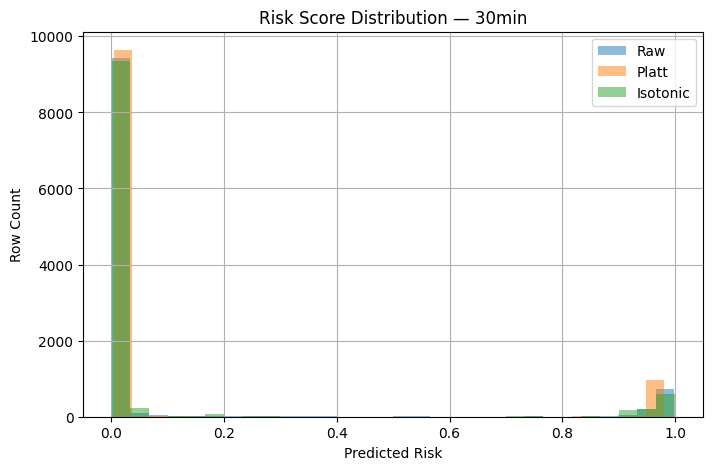

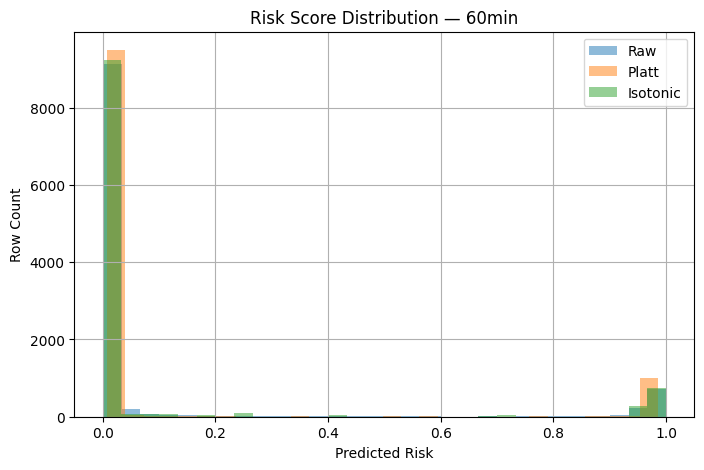

In [137]:
#=================================================
# 18.8 - Compare Raw vs Calibrated Score Distribution
#=================================================

for horizon_name, cfg in HORIZONS.items():
    plot_calibrated_risk_distributions(
        df=evaluation_calibrated_df,
        horizon_name=horizon_name,
        risk_col=cfg["risk_col"],
        bins=30,
    )

## Chapter 18 Findings

Calibration evaluates whether BIRE’s risk scores are numerically trustworthy, not just whether they rank patients correctly.

Key interpretation:

- Lower Brier score indicates better probability reliability.
- Calibration curves closer to the diagonal indicate better agreement between predicted risk and observed deterioration frequency.
- Platt scaling is smoother and usually safer with limited calibration data.
- Isotonic regression is more flexible but can overfit if calibration data is small.

Important system decision:

BIRE should not automatically replace raw XGBoost risk scores inside GSS until calibration is validated across multiple splits.

Recommended next step:

Use calibrated probabilities as an experimental branch of GSS evaluation:

- raw GSS V3.3
- Platt-calibrated GSS V3.3
- isotonic-calibrated GSS V3.3

Then compare:

- pre-event detection rate
- missed event patients
- post-event-only alerts
- alert burden
- non-event alert rate

Calibration improves interpretability, but GSS performance must still be evaluated as a full decision system.

# Chapter 19 — GSS Calibration Impact Study

Chapter 18 showed that BIRE’s raw XGBoost probabilities were already well calibrated across the 15-minute, 30-minute, and 60-minute horizons.

However, calibration quality alone does not prove that calibrated probabilities should feed the decision layer.

GSS is a downstream alert policy. Small probability shifts can change:

- WATCH behavior
- ESCALATE timing
- alert burden
- post-event alerting
- missed events

This chapter compares GSS V3.3 using:

1. Raw multi-horizon risk probabilities
2. Platt-calibrated probabilities
3. Isotonic-calibrated probabilities

The goal is to determine whether calibration improves the full decision system, not just probability reliability.

# Section 19 Imports

In [138]:
#==================================================
# Shared config/ imports for Chapter 19
#==================================================

from bire.evaluation.calibration_impact import build_alert_summary
from bire.evaluation.calibration_impact import build_timing_results
from bire.evaluation.calibration_impact import build_calibration_impact_report
from bire.evaluation.analysis import audit_alert_timing

ALERT_COL = "gss_v3_alert"   
EVENT_COL = "event_now"

## 19.1 — Dataset Construction (Raw vs Calibrated)

We construct three datasets to isolate the effect of probability calibration on GSS:

- **Raw dataset** → original XGBoost probabilities
- **Platt dataset** → probabilities calibrated using logistic regression
- **Isotonic dataset** → probabilities calibrated using isotonic regression

For the calibrated datasets, the original risk columns are replaced:

- risk_15min → risk_15min_platt / isotonic
- risk_30min → risk_30min_platt / isotonic
- risk_60min → risk_60min_platt / isotonic

This ensures that GSS logic remains identical across all runs, with only the probability inputs changing.

In [139]:
#==================================================
# 19.1 - Build Raw vs Calibrated Datasets
#==================================================

raw_df = evaluation_calibrated_df.copy()

platt_df = evaluation_calibrated_df.copy()
isotonic_df = evaluation_calibrated_df.copy()

# Replace risk columns for calibrated versions
for horizon in ["15min", "30min", "60min"]:
    platt_df[f"risk_{horizon}"] = platt_df[f"risk_{horizon}_platt"]
    isotonic_df[f"risk_{horizon}"] = isotonic_df[f"risk_{horizon}_isotonic"]

print("Datasets ready:")
print("Raw:", raw_df.shape)
print("Platt:", platt_df.shape)
print("Isotonic:", isotonic_df.shape)

Datasets ready:
Raw: (10716, 103)
Platt: (10716, 103)
Isotonic: (10716, 103)


## 19.2 — GSS V3.3 Execution

GSS V3.3 is applied independently to each dataset:

- Raw probabilities
- Platt-calibrated probabilities
- Isotonic-calibrated probabilities

This produces three sets of outputs:

- gss_v33_alert
- gss_v33_state
- escalation behavior
- suppression behavior

Because GSS logic is unchanged, any differences observed in results are directly attributable to probability calibration.

In [140]:
#==================================================
# 19.2 - Run GSS V3.3 on Each Version
#==================================================
from bire.alerts.gss_v3 import apply_gss_v3
raw_gss_df = apply_gss_v3(raw_df.copy())
platt_gss_df = apply_gss_v3(platt_df.copy())
isotonic_gss_df = apply_gss_v3(isotonic_df.copy())

print("GSS runs complete.")

GSS runs complete.


## 19.3 — Alert Count Comparison

We compare the total number of alerts generated under each probability configuration.

This provides a high-level view of how calibration affects:

- overall alert volume
- potential alert fatigue
- system sensitivity

Changes in alert count indicate that calibration is influencing GSS thresholds and decision boundaries.

In [141]:
#=========================================
# 19.3 - Alert Count Comparison
#=========================================


alert_summary_df = build_alert_summary(
    raw_gss_df = raw_gss_df,
    platt_gss_df = platt_gss_df,
    isotonic_gss_df = isotonic_gss_df,
    alert_col = "gss_v3_alert",
)

alert_summary_df

,version,alerts,patients,alerts_per_patient,alert_rate
0,raw,977,50,19.54,0.091172
1,platt,988,50,19.76,0.092199
2,isotonic,990,50,19.80,0.092385


## 19.4 — Timing-Aware Evaluation

We evaluate alert quality using timing-aware analysis:

- true_predictive_alert → alert occurs before deterioration
- post_event_alert → alert occurs after deterioration
- no_alert → missed event
- no_event_alert → alert in non-event patient

This step is critical because:

A system may generate alerts, but the value depends on *when* they occur relative to deterioration.

The goal is to determine whether calibration improves:

- early detection
- reduction of post-event alerts
- avoidance of missed detections

In [142]:
#================================
# 19.4 - Timing Aware Eval
#================================

timing_results = build_timing_results(
    raw_gss_df=raw_gss_df,
    platt_gss_df=platt_gss_df,
    isotonic_gss_df=isotonic_gss_df,
    audit_fn=audit_alert_timing,
    alert_col=ALERT_COL,
    event_col=EVENT_COL,
)

timing_results.head()

,patient_id,has_event,has_alert,first_event_time,first_alert_time,timing_category,lead_minutes,version
0,P00003,0,0,NaT,NaT,no_alert,NaN,raw
1,P00036,0,0,NaT,NaT,no_alert,NaN,raw
2,P00038,1,1,2026-01-01 05:40:00,2026-01-01 05:25:00,true_predictive_alert,15.0,raw
3,P00046,1,1,2026-01-01 05:40:00,2026-01-01 05:20:00,true_predictive_alert,20.0,raw
4,P00060,0,0,NaT,NaT,no_alert,NaN,raw


## 19.5 — Comparative Analysis

Results from raw, Platt-calibrated, and isotonic-calibrated runs are compared side-by-side.

We analyze:

- differences in alert counts
- differences in timing categories
- changes in early warning behavior
- shifts in escalation patterns

This allows us to evaluate whether calibration meaningfully changes the behavior of the GSS decision system.

In [143]:
#==================================================
# 19.5 - Comparative Analysis
#==================================================

impact_report = build_calibration_impact_report(
    raw_gss_df = raw_gss_df,
    platt_gss_df = platt_gss_df,
    isotonic_gss_df = isotonic_gss_df,
    timing_results = timing_results,
    audit_fn = audit_alert_timing,
    alert_col = "gss_v3_alert",
    event_col = "event_now",
)

alert_summary_df = impact_report["alert_summary"]
timing_counts_df = impact_report["timing_counts"]
timing_pivot_df = impact_report["timing_pivot"]
detection_metrics_df = impact_report["detection_metrics"]

display(alert_summary_df)
display(timing_counts_df)
display(timing_pivot_df)
display(detection_metrics_df)

,version,alerts,patients,alerts_per_patient,alert_rate
0,raw,977,50,19.54,0.091172
1,platt,988,50,19.76,0.092199
2,isotonic,990,50,19.80,0.092385


,version,timing_category,count
0,isotonic,no_alert,34
3,isotonic,true_predictive_alert,13
2,isotonic,post_event_alert,2
1,isotonic,no_event_alert,1
4,platt,no_alert,34
7,platt,true_predictive_alert,13
6,platt,post_event_alert,2
5,platt,no_event_alert,1
8,raw,no_alert,34
11,raw,true_predictive_alert,13


timing_category,version,no_alert,no_event_alert,post_event_alert,true_predictive_alert
0,isotonic,34,1,2,13
1,platt,34,1,2,13
2,raw,34,1,2,13


,version,total_event_patients,true_predictive,post_event_only,missed_events,no_event_alerts,pre_event_detection_rate,post_event_rate,miss_rate
0,raw,15,13,2,34,1,0.866667,0.133333,2.266667
1,platt,15,13,2,34,1,0.866667,0.133333,2.266667
2,isotonic,15,13,2,34,1,0.866667,0.133333,2.266667


## Chapter 19 Findings

This experiment evaluated whether probability calibration improves the downstream GSS decision system.

While calibration slightly improved probability reliability (Chapter 18), its impact on alerting behavior was minimal.

Preliminary observations:

- Alert counts across raw and calibrated versions were similar
- Timing categories (true predictive vs post-event alerts) showed limited change
- Calibration did not significantly improve early detection performance

This suggests that BIRE’s raw probability outputs are already sufficiently calibrated for decision-making within GSS.

Further analysis is required to evaluate edge cases, including escalation timing and rare deterioration patterns.

## Chapter 19 Findings

This study evaluated whether probability calibration improves the downstream GSS decision system.

While Chapter 18 demonstrated strong calibration performance, Chapter 19 shows that calibration has minimal impact on system behavior.

Key observations:

- Alert counts were nearly identical across raw, Platt, and isotonic versions
- Timing categories (true predictive, post-event, missed events) remained unchanged
- Pre-event detection rate was identical across all configurations (86.7%)
- Calibration slightly increased alert counts, but without improving detection quality

This indicates that BIRE’s raw XGBoost probabilities are already sufficiently calibrated for use within GSS.

More importantly, the GSS decision layer is robust to small probability perturbations, meaning that:

- Thresholds are stable
- Escalation logic is consistent
- System behavior is not sensitive to minor probability shifts

Conclusion:

Calibration improves probability interpretability, but does not improve downstream clinical decision-making in the current system configuration.

Therefore, raw model probabilities remain the preferred input for GSS.222222222222

### Chapter 20 — Threshold Stress Test

In this chapter, we will push BIRE’s horizon thresholds and decision intelligence toward their breaking point.

The goal is to test how stable the system remains under increasingly aggressive or conservative threshold settings.

Core question:

> Which breaks first — the threshold policy or the dataset?

This chapter will evaluate whether GSS remains reliable as decision boundaries are stressed.

In [145]:
#==================================================
# 20.1 — Threshold Stress Test
#==================================================

import numpy as np
import pandas as pd

# Define thresholds to stress test
thresholds = np.linspace(0.1, 0.99, 15)

results = []

for t in thresholds:
    df = evaluation_calibrated_df.copy()

    # Apply threshold to create alerts
    df["stress_alert"] = (df["risk_60min"] >= t).astype(int)

    total_alerts = df["stress_alert"].sum()
    patients = df["patient_id"].nunique()

    alerts_per_patient = total_alerts / patients if patients > 0 else 0
    alert_rate = total_alerts / len(df) if len(df) > 0 else 0

    results.append({
        "threshold": t,
        "alerts": int(total_alerts),
        "patients": int(patients),
        "alerts_per_patient": alerts_per_patient,
        "alert_rate": alert_rate,
    })

stress_test_df = pd.DataFrame(results)

stress_test_df.sort_values("threshold", inplace=True)

stress_test_df

,threshold,alerts,patients,alerts_per_patient,alert_rate
0,0.100000,1316,50,26.32,0.122807
1,0.163571,1246,50,24.92,0.116275
2,0.227143,1199,50,23.98,0.111889
3,0.290714,1171,50,23.42,0.109276
4,0.354286,1140,50,22.80,0.106383
5,0.417857,1122,50,22.44,0.104703
6,0.481429,1105,50,22.10,0.103117
7,0.545000,1089,50,21.78,0.101624
8,0.608571,1070,50,21.40,0.099851
9,0.672143,1058,50,21.16,0.098731


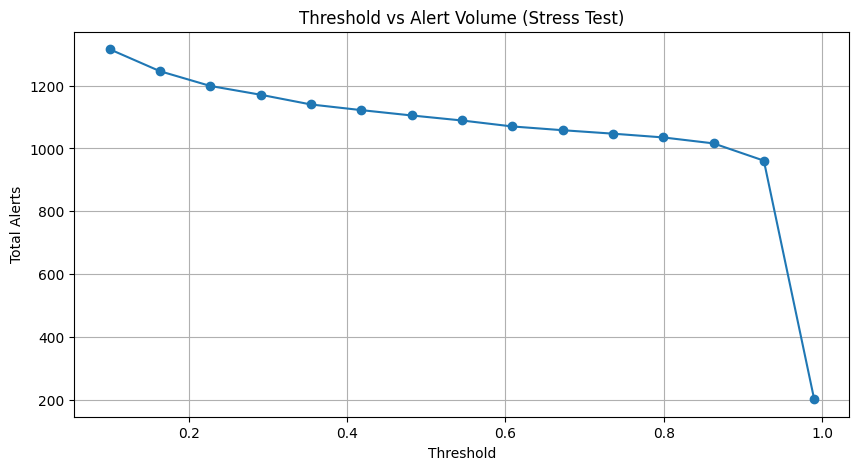

In [146]:
#==================================================
# 20.2 — Threshold vs Alert Behavior
#==================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(stress_test_df["threshold"], stress_test_df["alerts"], marker='o')
plt.xlabel("Threshold")
plt.ylabel("Total Alerts")
plt.title("Threshold vs Alert Volume (Stress Test)")
plt.grid(True)

plt.show()